# **Segmentación**

# TRAIN

## Connecting to drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
import sys
import locale
import os
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding
sys.path.append('/content/drive/MyDrive')
%cd /content/drive/MyDrive/StereoSpike
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
!pip3 install -r requirements.txt

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
/content/drive/MyDrive/StereoSpike


## Libraries importing

In [ ]:
import time
import random
from tqdm import tqdm
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
#import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "0"
import torch
import torch.nn as nn
#import torch.nn.functional as F
from torchvision import transforms
# from torch.utils.tensorboard import SummaryWriter

from spikingjelly.activation_based import functional
from spikingjelly.activation_based import surrogate
# from spikingjelly.event_driven import neuron
from datasets.data_augmentation import ToTensor_mono,ToTensor_ms, RandomHorizontalFlip_ms, RandomVerticalFlip_ms, RandomTimeMirror, RandomEventDrop_ms
#from network.SNN_models2 import unetRNN6Layer_noBlock
from network.SNN_models import StereoSpike, \
                    fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike, \
                    fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike, \
                    fromZero_feedforward_multiscale_tempo_monocular_Motion, \
                    fromZero_feedforward_multiscale_tempo_monocular_Motion2, \
                    unetMotion#, Unet
# from network.SNN_models2 import unetMotion3, unetMotion4
from OF_EV_SNN.network_3d.poolingNet_cat_1res import NeuronPool_Separable_Pool3d_2, \
                    PLIFNeuronPool_Separable_Pool3d, \
                    PLIFNeuronPool_Separable_Pool3d_2, \
                    NeuronPool_Separable_Pool3d, \
                    NeuronPool_Separable_Pool3d_2, \
                    PLIFNeuronPool_Separable_Pool3d_ts, \
                    NeuronPool_Separable_Pool3d_3x3, \
                    NeuronPool_Separable_Pool3d_original, \
                    NeuronPool_Separable_Pool3d_depth_segm, \
                    SpikeMS_poolingnet, \
                    poolingnet3d, \
                    poolingnet3d_i, \
                    poolingnet3d_lif

from network.ANN_models import StereoSpike_equivalentANN
from network.metrics import MeanDepthError, log_to_lin_depths, disparity_to_depth
from network.Params import yamlParams
#from datasets.MVSEC import mvsec_dataset2 as evimo_base
from network.loss2 import Total_Loss, DiceLoss, BCEDiceLoss, getIOU, VanRossumLoss, SegmDepthLoss
from datasets.MVSEC.mvsec_dataset import EVIMODatasetBase, EVIMODatasetBaseNPZ, EVIMODatasetBase_serg
#from network.SNN_models2 import unetRNN6Layer_noBlock

from torch.utils.data.dataloader import default_collate
from viz import show_learning, show_loss
from PIL import Image
import os
#from network.loss import getIOU, MSE
#from datasets.MVSEC import load_MVSEC
########################
# COMPLEMENT FUNCTIONS #
########################

def my_collate(batch):
    batch = list(filter (lambda x:x is not None, batch))
    if not batch:
        return None

    return default_collate(batch)
##############################
# DEVICE AND REPRODUCIBILITY #
##############################

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
print(device)

logfile = open("./results/checkpoints/test_results_dani.txt", "w+")

# logfile = open("./results/checkpoints/test_results_sergio.txt", "w+")
###########################
# VISUALIZATION FUNCTIONS #
###########################

plt.ion()
fig = plt.figure()

torch.use_deterministic_algorithms(False)

cuda:0


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

## Training Params

In [ ]:
######################
# GENERAL PARAMETERS #
######################
# general_config = "/content/drive/MyDrive/StereoSpike/general_config.yaml"

general_config = "/content/drive/MyDrive/StereoSpikeA/general_config.yaml"  # Para ./results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lr_5_3_super.pth
genconfigs = yamlParams(general_config)
imageDir = "images" # Cambiar por una direccion
saveImageInterval = 1

# nfpdm = 50              # number of frames per depth map (1 label every 50 ms)
learned_metric = 'LIN' # learn metric depth ('LIN'), normalized log depth ('LOG') or disparity ('DISP')
learning_rate = 2e-4
weight_decay = 0.0
n_epochs = 300

mode='segm'

rmseloss_module = Total_Loss() #alpha=0.5, scale_weights=(1., 1., 1., 1.), penalize_spikes=False)
#loss_module = DiceLoss()
bcediceloss_module = BCEDiceLoss()

segmdepthloss_module = SegmDepthLoss()
vanrossumloss_module = VanRossumLoss()
#loss_module = DepthBCEDiceLoss()

loss_module = BCEDiceLoss()

## Load net class and dataset params

In [ ]:
########################
## TRAINING FRAMEWORK ##
########################
# Create the network

neuron_type = "lif"

time_window = 10

# net = NeuronPool_Separable_Pool3d_depth_segm(multiply_factor = 10.).to(device) #ts 20
# net = NeuronPool_Separable_Pool3d_3x3(multiply_factor = 10.).to(device)
# net = NeuronPool_Separable_Pool3d_original(multiply_factor = 10.,time_window = 21).to(device) #ts 21
# net = SpikeMS_poolingnet(multiply_factor = 10., time_window = 10).to(device)
# net = poolingnet3d(multiply_factor = 2., time_window = 10).to(device)

if neuron_type == "lif":
    net = poolingnet3d_lif(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)
elif neuron_type == "izhikevich":
    net = poolingnet3d_i(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)
elif neuron_type == "lif_drop":
    net = poolingnet3d_lif_drop(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)


trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print('Trainable parameters: {}'.format(trainable_params))


# Initialize network weights

for m in net.modules():
    if isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)


# Create the optimizer
lr = 1e-4#5e-4
wd = 1e-3
optimizer = torch.optim.AdamW(net.parameters(), lr = lr, weight_decay = wd)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [10, 20, 40, 80, 160, 320], gamma = 0.5)

USING SPIKING MODEL
Trainable parameters: 1660384


## Dataset EVIMO

### Multiple dataset loader TABLE completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "table"

num_workers = 4 #genconfigs['hardware']['readerThreads']
batch_size = 1 #genconfigs['batchsize']

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 3.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""
ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader TABLE completo 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "table"

num_workers = 4 #genconfigs['hardware']['readerThreads']
batch_size = 1 #genconfigs['batchsize']

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 3 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)


maskDir_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""
# ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataser loader FAST completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "fast"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02.hdf5"



#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader WALL completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "wall"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 1.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_01.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01.hdf5"

#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)


    print("EVIMO wall used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO tot length 1593
MVSEC_dataset1
EVIMO tot length 1784
MVSEC_dataset1
EVIMO tot length 1401
MVSEC_dataset1
EVIMO tot length 1957
MVSEC_dataset1
EVIMO wall used

    MODEL
    ------------------------------
    poolingnet3d_lif
    DATA
    ------------------------------
    nfpdm = 1
    N_train = 1
    training_set = 3741
    test_set = 2994
    learned_metric = LIN
    data_augmentation = Compose(
    RandomHorizontalFlip_ms(p=0.5)
    RandomVerticalFlip_ms(p=0.5)
    RandomEventDrop_ms(p=0.5, min_drop_rate=0.0, max_drop_rate=0.4)
)
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = 1
    lr = 0.0002
    wd = 0.0
    


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


### Multiple dataset loader WALL completo 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "fast"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_05.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_02.hdf5"



#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader FLOOR completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "floor"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  10, 1, genconfigs, maskDir_test_00,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop, maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop, maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader FLOOR completo 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "floor"
# ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"

# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)

# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_00/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_00.hdf5" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_01/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/floor/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_01.hdf5" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/floor/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_02/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_02.hdf5" #"/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_00/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02.hdf5"
# maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03/img"
# datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03.hdf5"
# maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04/img"
# datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04.hdf5"
# maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05/img"
# datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_00/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_00.hdf5" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_01/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_01.hdf5" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_01.hdf5"
# maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_00,  10, 1, genconfigs, maskDir_test_00,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase_serg(datafile_train_01, 10, 1, genconfigs, maskDir_train_00, crop, maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase_serg(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase_serg(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop, maxBackgroundRatio, incrementalPercent)

    # database_test_02 =  EVIMODatasetBase_serg(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase_serg(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop, maxBackgroundRatio, incrementalPercent)

    # database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    # database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
    #                             maxBackgroundRatio, incrementalPercent)

    # database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    # database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
    #                             maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO_dataset:  /content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (900347, 4), type "<f8">
<HDF5 dataset "events_idx": shape (263,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (262, 3), type "<f8">
EVIMO tot length 261
EVIMO_dataset:  /content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (3906982, 4), type "<f8">
<HDF5 dataset "events_idx": shape (1612,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (1611, 3), type "<f8">
EVIMO tot length 1610
EVIMO_dataset:  /content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_01/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (365755, 4), ty

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


### Multiple dataset loader BOX completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "box"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05.hdf5"
maskDir_train_06 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_06/img"
datafile_train_06 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_06.hdf5"
maskDir_train_07 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_07/img"
datafile_train_07 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_07.hdf5"
maskDir_train_08 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_08/img"
datafile_train_08 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_08.hdf5"
maskDir_train_09 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_09/img"
datafile_train_09 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_09.hdf5"
maskDir_train_10 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_10/img"
datafile_train_10 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_10.hdf5"
maskDir_train_11 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_11/img"
datafile_train_11 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_11.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_03.hdf5"
maskDir_test_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_04/img"
datafile_test_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_04.hdf5"
maskDir_test_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_05/img"
datafile_test_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_05.hdf5"


# maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_01, 10, 1, genconfigs, maskDir_test_01,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_02, 10, 1, genconfigs, maskDir_test_02,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_04, 10, 1, genconfigs, maskDir_test_04,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_05, 10, 1, genconfigs, maskDir_test_05,  crop,
            maxBackgroundRatio, incrementalPercent)

    database_train_00 = EVIMODatasetBase_serg(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase_serg(datafile_test_01, 10, 1,   genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase_serg(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase_serg(datafile_test_02, 10, 1,   genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase_serg(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase_serg(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase_serg(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase_serg(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_04 = EVIMODatasetBase_serg(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_05 = EVIMODatasetBase_serg(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase_serg(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    # for box dataset
    # database_test_06 =  EVIMODatasetBase(datafile_test_06,  genconfigs, maskDir_test_06,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_06 = EVIMODatasetBase_serg(datafile_train_06, 10, 1,  genconfigs, maskDir_train_06, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_07 =  EVIMODatasetBase(datafile_test_07,  genconfigs, maskDir_test_07,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_07 = EVIMODatasetBase_serg(datafile_train_07, 10, 1,  genconfigs, maskDir_train_07, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_08 =  EVIMODatasetBase(datafile_test_08,  genconfigs, maskDir_test_08,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_08 = EVIMODatasetBase_serg(datafile_train_08, 10, 1,  genconfigs, maskDir_train_08, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_09 =  EVIMODatasetBase(datafile_test_09,  genconfigs, maskDir_test_09,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_09 = EVIMODatasetBase_serg(datafile_train_09, 10, 1,  genconfigs, maskDir_train_09, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_10 = EVIMODatasetBase(datafile_train_10, genconfigs, maskDir_train_10, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_10 = EVIMODatasetBase_serg(datafile_train_10, 10, 1,  genconfigs, maskDir_train_10, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_11 = EVIMODatasetBase(datafile_train_11, genconfigs, maskDir_train_11, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_11 = EVIMODatasetBase_serg(datafile_train_11, 10, 1,  genconfigs, maskDir_train_11, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}##
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader BOX completo 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "box"
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lifnode"


##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_05.hdf5"
maskDir_train_06 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_06/img"
datafile_train_06 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_06.hdf5"
maskDir_train_07 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_07/img"
datafile_train_07 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_07.hdf5"
maskDir_train_08 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_08/img"
datafile_train_08 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_08.hdf5"
maskDir_train_09 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_09/img"
datafile_train_09 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_09.hdf5"
maskDir_train_10 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_10/img"
datafile_train_10 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_10.hdf5"
maskDir_train_11 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_11/img"
datafile_train_11 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_11.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_03.hdf5"
maskDir_test_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_04/img"
datafile_test_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_04.hdf5"
maskDir_test_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_05/img"
datafile_test_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_05.hdf5"


# maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_01, 10, 1, genconfigs, maskDir_test_01,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_02, 10, 1, genconfigs, maskDir_test_02,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_04, 10, 1, genconfigs, maskDir_test_04,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_05, 10, 1, genconfigs, maskDir_test_05,  crop,
            maxBackgroundRatio, incrementalPercent)

    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,   genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,   genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    # for box dataset
    # database_test_06 =  EVIMODatasetBase(datafile_test_06,  genconfigs, maskDir_test_06,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_06 = EVIMODatasetBase(datafile_train_06, 10, 1,  genconfigs, maskDir_train_06, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_07 =  EVIMODatasetBase(datafile_test_07,  genconfigs, maskDir_test_07,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_07 = EVIMODatasetBase(datafile_train_07, 10, 1,  genconfigs, maskDir_train_07, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_08 =  EVIMODatasetBase(datafile_test_08,  genconfigs, maskDir_test_08,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_08 = EVIMODatasetBase(datafile_train_08, 10, 1,  genconfigs, maskDir_train_08, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_09 =  EVIMODatasetBase(datafile_test_09,  genconfigs, maskDir_test_09,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_09 = EVIMODatasetBase(datafile_train_09, 10, 1,  genconfigs, maskDir_train_09, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_10 = EVIMODatasetBase(datafile_train_10, genconfigs, maskDir_train_10, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_10 = EVIMODatasetBase(datafile_train_10, 10, 1,  genconfigs, maskDir_train_10, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_11 = EVIMODatasetBase(datafile_train_11, genconfigs, maskDir_train_11, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_11 = EVIMODatasetBase(datafile_train_11, 10, 1,  genconfigs, maskDir_train_11, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}

        '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)


# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "mixed_train_ta00fa00wa00wa01flo01box00"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 4 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_table00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
datafile_train_table00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"

maskDir_test_table01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01/img"
datafile_test_table01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01.hdf5"


# maskDir_train_fast00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00/img"
# datafile_train_fast00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00.hdf5"

maskDir_test_fast01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01/img"
datafile_test_fast01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01.hdf5"


maskDir_train_wall00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00/img"
datafile_train_wall00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00.hdf5"

maskDir_train_wall01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00/img"
datafile_train_wall01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00.hdf5"

maskDir_test_wall01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01/img"
datafile_test_wall01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01.hdf5"


maskDir_train_floor01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/floor/txt/seq_01/img"
datafile_train_floor01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/floor/txt/seq_01.hdf5"

maskDir_test_floor00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_00/img"
datafile_test_floor00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_00.hdf5"


maskDir_train_box00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_00/img"
datafile_train_box00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_00.hdf5"

maskDir_test_box01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01/img"
datafile_test_box01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01.hdf5"

# maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_table01 =  EVIMODatasetBase_serg(datafile_test_table01, time_window, 1, genconfigs, maskDir_test_table01,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_fast01 =  EVIMODatasetBase_serg(datafile_test_fast01, time_window, 1, genconfigs, maskDir_test_fast01,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_wall01 =  EVIMODatasetBase_serg(datafile_test_wall01, time_window, 1, genconfigs, maskDir_test_wall01,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_floor00 =  EVIMODatasetBase_serg(datafile_test_floor00, time_window, 1, genconfigs, maskDir_test_floor00,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_box01 =  EVIMODatasetBase_serg(datafile_test_box01, time_window, 1, genconfigs, maskDir_test_box01,  crop,
            maxBackgroundRatio, incrementalPercent)


    database_train_table00 = EVIMODatasetBase_serg(datafile_train_table00, 10, 1, genconfigs, maskDir_train_table00, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_fast00 = EVIMODatasetBase_serg(datafile_train_fast00, 10, 1, genconfigs, maskDir_train_fast00, crop,
    #                             maxBackgroundRatio, incrementalPercent)

    database_train_wall01 = EVIMODatasetBase_serg(datafile_train_wall01, 10, 1, genconfigs, maskDir_train_wall01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_wall00 = EVIMODatasetBase_serg(datafile_train_wall00, 10, 1, genconfigs, maskDir_train_wall00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_floor01 = EVIMODatasetBase_serg(datafile_train_floor01, 10, 1, genconfigs, maskDir_train_floor01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_box00 = EVIMODatasetBase_serg(datafile_train_box00, 10, 1,  genconfigs, maskDir_train_box00, crop,
                                maxBackgroundRatio, incrementalPercent)


    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_table00, database_train_wall00,database_train_wall01, database_train_floor01, database_train_box00])
database_test = torch.utils.data.ConcatDataset([database_test_table01, database_test_fast01, database_test_wall01, database_test_floor00, database_test_box01])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    train_datasets = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}##
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               dataset_name,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (4733693, 4), type "<f8">
<HDF5 dataset "events_idx": shape (237,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (236, 3), type "<f8">
EVIMO tot length 235
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (12506745, 4), type "<f8">
<HDF5 dataset "events_idx": shape (160,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (159, 3), type "<f8">
EVIMO tot length 158
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## Load state

In [ ]:
# # print("./results/checkpoints/"+ckpt_file+"_lr0.0005_mbgr6"+".pth")
# # checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_'+dataset_name+'_lifnode.pth')
# # checkpoint = torch.load("./results/checkpoints/"+ckpt_file+"_lr0.0005_mbgr6"+".pth")
# checkpoint = torch.load("./results/checkpoints/best_poolingnet3d_seg_lif_orgnl_wall_lr0.0004_mbgr9_10-11-2023-22h23m26s.pth")

# train_loss_vec = checkpoint['train_loss_vec_dict']
# test_loss_vec = checkpoint['test_loss_vec_dict']
# train_error_vec = checkpoint['train_error_vec_dict']
# test_error_vec = checkpoint['test_error_vec_dict']
# net.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# running_train_loss = checkpoint['running_train_loss']
# running_train_IOU = checkpoint['running_train_IOU']
# running_test_loss = checkpoint['running_test_loss']
# running_test_IOU = checkpoint['running_test_IOU']
# epoch = checkpoint['epoch']
# # epoch_test_loss = checkpoint['loss']
# # net.update_max_accuracy(epoch_test_loss)
# ckpt_train_i = checkpoint['ckpt_idx_train']
# ckpt_test_i = checkpoint['ckpt_idx_test']

In [ ]:
# ckpt_file = "poolingnet3d_seg_lif_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
ckpt_file = net._get_name()+"_neuron"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_wd"+str(wd)+"time_win"+str(time_window)+"ms"
print(ckpt_file)
checkpoint_path = "./results/checkpoints/"+ckpt_file+".pth"
checkpoint = torch.load(checkpoint_path)

# ckpt_file = "poolingnet3d_seg_lif_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
# print(ckpt_file)
# checkpoint_path = "./results/checkpoints/"+ckpt_file+".pth"
# checkpoint = torch.load(checkpoint_path)

NameError: name 'net' is not defined

In [ ]:
train_loss_vec = checkpoint['train_loss_vec_dict']
test_loss_vec = checkpoint['test_loss_vec_dict']
train_error_vec = checkpoint['train_error_vec_dict']
test_error_vec = checkpoint['test_error_vec_dict']
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
running_train_loss = checkpoint['running_train_loss']
running_train_IOU = checkpoint['running_train_IOU']
running_test_loss = checkpoint['running_test_loss']
running_test_IOU = checkpoint['running_test_IOU']
test_epoch_summary = checkpoint['test_epoch_summary']
train_epoch_summary = checkpoint['train_epoch_summary']
epoch_train_loss = checkpoint['epoch_train_loss']
epoch_test_loss = checkpoint['epoch_test_loss']
epoch = checkpoint['epoch']
# net.update_max_accuracy(epoch_test_loss)
ckpt_train_i = checkpoint['ckpt_idx_train']
ckpt_test_i = checkpoint['ckpt_idx_test']
train_done = checkpoint['train_done']
test_done = checkpoint['test_done']
train_i=0
test_i=0

In [ ]:
len(train_loss_vec)

In [ ]:
save_error=False
now = datetime.now() # current date and time
date_time = now.strftime("%mm%dd%Yy%Hh%Mm%Ss")

x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
plt.legend(['train','test'])
plt.title("Loss")

if save_error:
    # plt.savefig('./results/checkpoints/loss_prueba'+date_time+'.png',format='png',transparent=True)
    plt.savefig('./results/checkpoints/loss_prueba'+date_time+'.pdf',format='pdf',transparent=True)

plt.show()

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
plt.legend(['train','test'])
plt.title("IoU")


if save_error:
    # plt.savefig('./results/checkpoints/error_prueba'+date_time+'.png',format='png',transparent=True)
    plt.savefig('./results/checkpoints/error_prueba'+date_time+'.pdf',format='pdf',transparent=True)

plt.show()

## Si NO hay CHECKPOINT Nuevo entrenamiento

In [ ]:
### starts a new training
# from torchsummary import summary
# train_loss_vec = []
# train_error_vec = []
# test_loss_vec = []
# test_error_vec = []
# running_train_loss = 0
# running_train_IOU = 0
# running_test_loss = 0
# running_test_IOU = 0
# ckpt_train_i = 0
# ckpt_test_i = 0
# train_i = 0
# test_i = 0

train_loss_vec = []
train_error_vec = []
test_loss_vec = []
test_error_vec = []
running_train_loss = 0
running_train_IOU = 0
running_test_loss = 0
running_test_IOU = 0
ckpt_train_i = 0
ckpt_test_i = 0
train_i = 0
test_i = 0
train_done=False
test_done=False
epoch_test_loss = 0
epoch_test_IOU = 0
epoch_train_loss = 0
epoch_train_IOU = 0
test_epoch_summary = 0
train_epoch_summary = 0

In [ ]:
ckpt_file = net._get_name()+"_neuron"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_wd"+str(wd)+"time_win"+str(time_window)+"ms"
checkpoint_path = "./results/checkpoints/"+ckpt_file+".pth"
print(ckpt_file)

count = 0
while(os.path.exists(checkpoint_path)):
  ckpt_file = net._get_name()+"_neuron"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_wd"+str(wd)+"time_win"+str(time_window)+"ms_" + str(count)
  checkpoint_path = "./results/checkpoints/" + ckpt_file + ".pth"
  count += 1

print(checkpoint_path)

poolingnet3d_lif_neuronlif_orgnl_mixed_train_ta00fa00wa00wa01flo01box00_lr0.0001_mbgr4_wd0.001time_win10ms
./results/checkpoints/poolingnet3d_lif_neuronlif_orgnl_mixed_train_ta00fa00wa00wa01flo01box00_lr0.0001_mbgr4_wd0.001time_win10ms.pth


In [ ]:
# # # print("./results/checkpoints/"+ckpt_file+"5.pth")
# # ckpt_file = "poolingnet3d_seg_lif_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
# ckpt_file = "poolingnet3d_seg_lif_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
# checkpoint_path = "./results/checkpoints/"+ckpt_file+".pth"
# # checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_'+dataset_name+'_lifnode.pth')
# # # checkpoint = torch.load("./results/checkpoints/"+ckpt_file+"5.pth")

## No sé, revisar el TRAIN

In [ ]:
from spikingjelly.activation_based import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning

# ckpt_file = "poolingnet3d_seg_SEW3D"+dataset_name+"_lifnode"

functional.reset_net(net)
if int(ckpt_train_i) >10:
    print("resuming training from checkpoint: train_i: "+str(ckpt_train_i)+", train_loss: "+str(running_train_loss)+", train_IOU: "+str(running_train_IOU))
train_i=0
test_i=0
for epoch in range(n_epochs):
    show=False
    net = net.train()                                                   #<--------   0

    start_time = time.time()
    with torch.autograd.set_detect_anomaly(True):
        for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
            if (data == None):
                # ckpt_i = i
                # print(len(train_loader))
                continue
            train_i += 1
            if ckpt_train_i > train_i:
            #     # print(str(i)+"<"+str(train_i))
                continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

            optimizer.zero_grad()

            # functional.reset_net(net)                                   #<--------  6
            spikes_input = data['spike_tensor']                         #   torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            # ckpt_idx_train = data['file_number']
            spikes_input = spikes_input.permute(0,1,4,2,3)              #   torch.Size([8, 2, 10, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)            # (0,1,4,2,3)
            # if MultiStep:                                               #   sums all time steps in the dim=0
            #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
            #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)                      #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            # spike_pred_list=  net(spikes_input)                       #<--------   2  # len(spike_pred_list) = 4
            spike_pred_list = net(spikes_input)
            spike_pred = spike_pred_list[0].to(device)
            # spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                # spike_input_crop  =  spikes_input[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (1,21,260,346)
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0),keepdim=False)    #reduces B dim           #torch.Size([ 1, 21, 260, 346])
                # spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5

            # spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
            spike_mask_4D = torch.any(spikes_masked_crop, dim = 1,keepdim=False) #or and remove of B dim


            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of C dim
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2),keepdim=False)           # ([B,2,21,260, 346])  --> ([B,2,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,2,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.gt(spike_mask_4D, 1)

            if show:
                spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                    #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True) # (B,C,T,H,W) --> (B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      # (B,C,1,H,W) --> (B,1,C,H,W)
                print("\n spike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                print(" spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                print(" spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                print(" spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                print(" spike_pred numbers to viz: ",torch.unique(spike_pred_viz)," of size: ",spike_pred_viz.size())
                print(" spike_mask numbers to viz: ",torch.unique(spike_mask_viz)," of size: ",spike_mask_viz.size())
                # if spike_pred.size(0) > 10:
                #     for e in range(spike_pred.size(0)): #iterates the batches dim=0
                #         show_learning(fig,False,
                #                     spike_input_5D[None,e,:,:,:,:],
                #                     spike_pred_viz[None,e,:,:,:],
                #                     spike_mask_viz[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                # elif spike_pred.size(2) > 10:
                #     for e in range(spike_pred.size(2)): #iterates the time dim=2
                #         show_learning(fig,False,
                #                     spikes_input[None,:,:,e,:,:],
                #                     spike_pred_4D[None,:,e,:,:],
                #                     spike_mask_4D[None,:,e,:,:], 'segm, timestep '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                # else:
                for e in range(spike_pred.size(0)): #iterates the batches dim=0
                    for i in range(spike_pred.size(2)): #iterates the time dim=2
                        show_learning(fig,False,
                                spikes_input[None,None,e,:,i,:,:],
                                spike_pred_4D[:,None,i,:,:],
                                spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    # show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)        #<--------  3
            # loss = vanrossumloss_module(spike_pred_4D, spike_mask_4D,2.0)
            # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2)        #<--------  3
            # loss.backward(retain_graph=False)                                         #<--------  4
            loss.backward()
            optimizer.step()                                        #<--------  5
            functional.reset_net(net)
            # optimizer.zero_grad()                               #<--------   1
            running_train_loss += loss.item() #/ spikes_input.size(0) # loss/batch_number
            spike_pred_4D = torch.round(spike_pred_4D)
            running_train_IOU += getIOU(spike_pred_4D,spike_mask_4D)


            if int(train_i) % 200 <= 1: #condition to save intermediate trainings
                print("saving training at i: "+str(train_i)+", sequence: "+str(data['file_number'])+", train_loss: "+str(running_train_loss)+", train_IOU: "+str(running_train_IOU))
                torch.save({'epoch': epoch,
                'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                # 'loss': epoch_test_loss,
                'train_loss_vec_dict': train_loss_vec,
                'test_loss_vec_dict': test_loss_vec,
                'train_error_vec_dict': train_error_vec,
                'test_error_vec_dict': test_error_vec,
                'running_train_loss': running_train_loss,
                'running_train_IOU': running_train_IOU,
                'running_test_loss': running_test_loss,
                'running_test_IOU': running_test_IOU,
                'ckpt_idx_train': train_i,
                'ckpt_idx_test': test_i
                }, "./results/checkpoints/"+ckpt_file+".pth")

                # process saved metrics
        if train_i != 0:
            epoch_train_loss = running_train_loss / train_i # len(train_loader)
            epoch_train_IOU = running_train_IOU / train_i #len(train_loader)
            print("\n train i: ", train_i)
            print("len train loader: ", len(train_loader))
            train_loss_vec.append(float(epoch_train_loss))
            train_error_vec.append(float(epoch_train_IOU))
            epoch_train_time = time.time() - start_time
            train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)
        ckpt_train_i = train_i #temporary variable to transport the state of iterations to test loop
        # tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
        # tb_writer.add_scalar('train_iou', epoch_train_IOU, epoch)
        #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
#################   TEST LOOP ##################
    if int(ckpt_test_i) >10: print("resuming training from checkpoint: train_i: "+str(ckpt_test_i)+", train_loss: "+str(running_test_loss)+", train_IOU: "+str(running_test_IOU))

    net.eval()
    show=False

    with torch.no_grad():
        start_time = time.time()
        if int(test_i) >10: print("resuming testing from i: "+str(int(test_i)))

        for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
            if (data == None):
                continue
            test_i += 1
            if ckpt_test_i > test_i:
                continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

            functional.reset_net(net)
            optimizer.zero_grad()
            spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            # ckpt_idx_test = data['file_number']
            spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)
            # if MultiStep:   #sums all time steps in the dim=0
            #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
            #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            spikes_input.requires_grad_()

            spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
            spike_pred =  spike_pred_list[0].to(device)             # (1,1,260,346)
            # spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                #spike_pred_4D = spike_pred
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
                # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
            # spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            # spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

            if show:
                spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                #condition to colapse all timesteps in every batch for monitoring only
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                # print("spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                for e in range(spike_pred.size(0)): #iterates the batches dim=0
                    for i in range(spike_pred.size(2)): #iterates the time dim=2
                        show_learning(fig,False,
                                spikes_input[None,None,e,:,i,:,:],
                                spike_pred_4D[:,None,i,:,:],
                                spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)
            # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

            running_test_loss += loss.item()# / spikes_input.size(0)
            spike_pred_4D = torch.round(spike_pred_4D)
            running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

            if int(test_i) % 200 <= 1: #condition to save intermediate trainings
                print("saving testing at i: "+str(i)+", sequence: "+str(data['file_number'])+"")
                torch.save({'epoch': epoch,
                'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                # 'loss': epoch_test_loss,
                'train_loss_vec_dict': train_loss_vec,
                'test_loss_vec_dict': test_loss_vec,
                'train_error_vec_dict': train_error_vec,
                'test_error_vec_dict': test_error_vec,
                'running_train_loss': running_train_loss,
                'running_train_IOU': running_train_IOU,
                'running_test_loss': running_test_loss,
                'running_test_IOU': running_test_IOU,
                'ckpt_idx_train': train_i,
                'ckpt_idx_test': test_i,
                }, "./results/checkpoints/"+ckpt_file+".pth")

                # process saved metrics
        if test_i != 0:
            epoch_test_loss = running_test_loss / test_i #len(test_loader)
            epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
            print("\n test i: ",test_i)
            print("len test loader: ", len(test_loader))
            test_loss_vec.append(float(epoch_test_loss))
            test_error_vec.append(float(epoch_test_IOU))
            epoch_test_time = time.time() - start_time
            test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
            print(train_epoch_summary + test_epoch_summary)
            # logfile.write(train_epoch_summary + test_epoch_summary)

        # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
        # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)
        now = datetime.now() # current date and time
        date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
        if epoch_test_loss < net.get_max_accuracy():
            print("Best performances so far: saving model...\n")
            # logfile.write("Best performances so far: saving model...\n")
            net.update_max_accuracy(epoch_test_loss)
            #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
            torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        # 'loss': epoch_test_loss,
                        'train_loss_vec_dict': train_loss_vec,
                        'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,
                        'test_error_vec_dict': test_error_vec,
                        'running_train_loss': running_train_loss,
                        'running_train_IOU': running_train_IOU,
                        'running_test_loss': running_test_loss,
                        'running_test_IOU': running_test_IOU,
                        'ckpt_idx_train': train_i,
                        'ckpt_idx_test': test_i
                        }, "./results/checkpoints/best_"+ckpt_file+"_"+date_time+".pth")

        print("Performance saved: saving model...\n")
        torch.save({'epoch': epoch,
                    'model_state_dict': net.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    # 'loss': epoch_test_loss,
                    'train_loss_vec_dict': train_loss_vec,
                    'test_loss_vec_dict': test_loss_vec,
                    'train_error_vec_dict': train_error_vec,
                    'test_error_vec_dict': test_error_vec,
                    'running_train_loss': running_train_loss,
                    'running_train_IOU': running_train_IOU,
                    'running_test_loss': running_test_loss,
                    'running_test_IOU': running_test_IOU,
                    'ckpt_idx_train': train_i,
                    'ckpt_idx_test': test_i
                    }, "./results/checkpoints/"+ckpt_file+".pth")

        net.increment_epoch()
        scheduler.step()
        # Training/testing plots
        x=[x for x in range(len(train_loss_vec))]
        y=[y for y in range(len(test_loss_vec))]
        plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
        plt.legend(['train','test'])
        plt.title("Loss")

        save_loss=True
        if save_loss: plt.savefig('./results/checkpoints/loss_test'+dataset_name+date_time+'.png',format='png',transparent=True)
        plt.show()

        x=[x for x in range(len(train_error_vec))]
        y=[y for y in range(len(test_error_vec))]
        plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
        plt.legend(['train','test'])
        plt.title("IoU (%)")

        save_error=True
        if save_error: plt.savefig('./results/checkpoints/error_test'+dataset_name+date_time+'.png',format='png',transparent=True)
        plt.show()

    train_i = 0
    test_i = 0
    ckpt_train_i = 0
    ckpt_test_i = 0
    running_train_loss = 0
    running_train_IOU = 0
    running_test_loss = 0
    running_test_IOU = 0


print("training finished !")

## No sé, revisar el TRAIN 2

In [ ]:
from spikingjelly.activation_based import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning
ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
# ckpt_file = "poolingnet3d_seg_SEW3D"+dataset_name+"_lifnode"

functional.reset_net(net)
if int(train_i) >10: print("resuming training from i: "+str(int(train_i)))

for epoch in range(n_epochs):
    show=False
    net = net.train()                                                   #<--------   0
    running_train_loss = 0
    running_train_IOU = 0
    start_time = time.time()
    with torch.autograd.set_detect_anomaly(True):
        for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
            if i < train_i:
            #     # print(str(i)+"<"+str(train_i))
                continue # skips batches until it arrives to checkpoint of an incomplete epoch of training
            if (data == None):
                # print(len(train_loader))
                continue
            optimizer.zero_grad()
            train_i += 1
            # functional.reset_net(net)                                   #<--------  6
            spikes_input = data['spike_tensor']                         #   torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            # ckpt_idx_train = data['file_number']
            spikes_input = spikes_input.permute(0,1,4,2,3)              #   torch.Size([8, 2, 10, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)            # (0,1,4,2,3)
            # if MultiStep:                                               #   sums all time steps in the dim=0
            #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
            #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)                      #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            # spike_pred_list=  net(spikes_input)                       #<--------   2  # len(spike_pred_list) = 4
            spike_pred_list = net(spikes_input)
            spike_pred = spike_pred_list[0].to(device)
            # spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                # spike_input_crop  =  spikes_input[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (1,21,260,346)
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0),keepdim=False)    #reduces B dim           #torch.Size([ 1, 21, 260, 346])
                # spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of C dim
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2),keepdim=False)           # ([B,2,21,260, 346])  --> ([B,2,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,2,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.gt(spike_mask_4D, 1)

            if show:
                spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                    #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True) # (B,C,T,H,W) --> (B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      # (B,C,1,H,W) --> (B,1,C,H,W)
                print("\n spike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                print(" spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                print(" spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                print(" spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                print(" spike_pred numbers to viz: ",torch.unique(spike_pred_viz)," of size: ",spike_pred_viz.size())
                print(" spike_mask numbers to viz: ",torch.unique(spike_mask_viz)," of size: ",spike_mask_viz.size())
                # if spike_pred.size(0) > 10:
                #     for e in range(spike_pred.size(0)): #iterates the batches dim=0
                #         show_learning(fig,False,
                #                     spike_input_5D[None,e,:,:,:,:],
                #                     spike_pred_viz[None,e,:,:,:],
                #                     spike_mask_viz[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                # elif spike_pred.size(2) > 10:
                #     for e in range(spike_pred.size(2)): #iterates the time dim=2
                #         show_learning(fig,False,
                #                     spikes_input[None,:,:,e,:,:],
                #                     spike_pred_4D[None,:,e,:,:],
                #                     spike_mask_4D[None,:,e,:,:], 'segm, timestep '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                # else:
                for e in range(spike_pred.size(0)): #iterates the batches dim=0
                    for i in range(spike_pred.size(2)): #iterates the time dim=2
                        show_learning(fig,False,
                                spikes_input[None,None,e,:,i,:,:],
                                spike_pred_4D[:,None,i,:,:],
                                spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    # show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=1)        #<--------  3
            # loss = vanrossumloss_module(spike_pred_4D, spike_mask_4D,2.0)
            # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2)        #<--------  3
            # loss.backward(retain_graph=False)                                         #<--------  4
            loss.backward()
            optimizer.step()                                        #<--------  5
            functional.reset_net(net)
            # optimizer.zero_grad()                               #<--------   1
            running_train_loss += loss.item() / spikes_input.size(0)
            spike_pred_4D = torch.round(spike_pred_4D)
            running_train_IOU += getIOU(spike_pred_4D,spike_mask_4D)


            if int(i) % 100 == 0: #condition to save intermediate trainings
                print("saving training at i: "+str(train_i)+", sequence: "+str(data['file_number']))
                torch.save({'epoch': epoch,
                'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                # 'loss': epoch_test_loss,
                'train_loss_vec_dict': train_loss_vec,
                'test_loss_vec_dict': test_loss_vec,
                'train_error_vec_dict': train_error_vec,
                'test_error_vec_dict': test_error_vec,
                'ckpt_idx_train': i,
                'ckpt_idx_test': 0
                }, "./results/checkpoints/"+ckpt_file+".pth")

                # process saved metrics
        if train_i != 0:
            epoch_train_loss = running_train_loss / train_i # len(train_loader)
            epoch_train_IOU = running_train_IOU / train_i #len(train_loader)
            print("\n train i: ", train_i)
            print("len train loader: ", len(train_loader))
            train_loss_vec.append(float(epoch_train_loss))
            train_error_vec.append(float(epoch_train_IOU))
            epoch_train_time = time.time() - start_time
            train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)
        ckpt_train_i = train_i #temporary variable to transport the state of iterations to test loop
        # tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
        # tb_writer.add_scalar('train_iou', epoch_train_IOU, epoch)
        #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
#################   TEST LOOP ##################
    running_test_loss = 0
    running_test_IOU = 0
    net.eval()
    show=False

    with torch.no_grad():
        start_time = time.time()
        if int(test_i) >10: print("resuming testing from i: "+str(int(test_i)))
        for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
            if i < test_i:
                continue # skips batches until it arrives to checkpoint of an incomplete epoch of training
            if (data == None):
                continue
            test_i += 1
            functional.reset_net(net)
            optimizer.zero_grad()
            spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            # ckpt_idx_test = data['file_number']
            spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)
            # if MultiStep:   #sums all time steps in the dim=0
            #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
            #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            spikes_input.requires_grad_()

            spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
            spike_pred =  spike_pred_list[0].to(device)             # (1,1,260,346)
            # spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                #spike_pred_4D = spike_pred
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
                # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
            # spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            # spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

            if show:
                spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                #condition to colapse all timesteps in every batch for monitoring only
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                # print("spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                for e in range(spike_pred.size(0)): #iterates the batches dim=0
                    for i in range(spike_pred.size(2)): #iterates the time dim=2
                        show_learning(fig,False,
                                spikes_input[None,None,e,:,i,:,:],
                                spike_pred_4D[:,None,i,:,:],
                                spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=1)
            # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

            running_test_loss += loss.item() / spikes_input.size(0)
            spike_pred_4D = torch.round(spike_pred_4D)
            running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

            if int(i) % 100 == 0: #condition to save intermediate trainings
                print("saving testing at i: "+str(i)+", sequence: "+str(data['file_number']))
                torch.save({'epoch': epoch,
                'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                # 'loss': epoch_test_loss,
                'train_loss_vec_dict': train_loss_vec,
                'test_loss_vec_dict': test_loss_vec,
                'train_error_vec_dict': train_error_vec,
                'test_error_vec_dict': test_error_vec,
                'ckpt_idx_train': train_i,
                'ckpt_idx_test': i
                }, "./results/checkpoints/"+ckpt_file+".pth")

                # process saved metrics
        if test_i != 0:
            epoch_test_loss = running_test_loss / test_i #len(test_loader)
            epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
            print("\n test i: ",test_i)
            print("len test loader: ", len(test_loader))
            test_loss_vec.append(float(epoch_test_loss))
            test_error_vec.append(float(epoch_test_IOU))
            epoch_test_time = time.time() - start_time
            test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
            print(train_epoch_summary + test_epoch_summary)
            # logfile.write(train_epoch_summary + test_epoch_summary)

        # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
        # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)
        now = datetime.now() # current date and time
        date_time = now.strftime("%m%d%Y%H%M%S")
        if epoch_test_loss < net.get_max_accuracy():
            print("Best performances so far: saving model...\n")
            # logfile.write("Best performances so far: saving model...\n")
            net.update_max_accuracy(epoch_test_loss)
            #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
            torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        # 'loss': epoch_test_loss,
                        'train_loss_vec_dict': train_loss_vec,
                        'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,
                        'test_error_vec_dict': test_error_vec,
                        'ckpt_idx_train': train_i,
                        'ckpt_idx_test': test_i
                        }, "./results/checkpoints/best_"+ckpt_file+"_"+date_time+".pth")

        print("Performance saved: saving model...\n")
        torch.save({'epoch': epoch,
                    'model_state_dict': net.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    # 'loss': epoch_test_loss,
                    'train_loss_vec_dict': train_loss_vec,
                    'test_loss_vec_dict': test_loss_vec,
                    'train_error_vec_dict': train_error_vec,
                    'test_error_vec_dict': test_error_vec,
                    'ckpt_idx_train': train_i,
                    'ckpt_idx_test': test_i
                    }, "./results/checkpoints/"+ckpt_file+".pth")

        net.increment_epoch()
        scheduler.step()
        # Training/testing plots
        x=[x for x in range(len(train_loss_vec))]
        y=[y for y in range(len(test_loss_vec))]
        plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
        plt.legend(['train','test'])
        plt.title("Loss")

        save_loss=True
        if save_loss: plt.savefig('./results/checkpoints/loss_test'+dataset_name+date_time+'.png',format='png',transparent=True)
        plt.show()

        x=[x for x in range(len(train_error_vec))]
        y=[y for y in range(len(test_error_vec))]
        plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
        plt.legend(['train','test'])
        plt.title("IoU (%)")

        save_error=True
        if save_error: plt.savefig('./results/checkpoints/error_test'+dataset_name+date_time+'.png',format='png',transparent=True)
        plt.show()


    train_i = 0
    test_i = 0


print("training finished !")

## No sé, revisar el TRAIN 3

In [ ]:
# Cambiar a True si se quiere exportar imágenes
save_img = False #True

In [ ]:
# checkpoint = {'epoch': epoch,
#             'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
#             'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
#             'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
#             'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
#             'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
#             'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
#             'train_done': train_done,'test_done': test_done,
#             'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
#             'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }

import sys
try:
    from spikingjelly.activation_based import neuron, layer, surrogate
    from torch._C import dtype
    MultiStep=False
    from viz import show_learning

    # ckpt_file = "poolingnet3d_seg_SEW3D"+dataset_name+"_lifnode"

    functional.reset_net(net)
    if int(ckpt_train_i) >10:
        print("resuming training of "+dataset_name+" in epoch "+str(epoch)+" from chkpnt: train_i: "+str(int(ckpt_train_i))+", loss: "+str(running_train_loss)+", IOU: "+str(running_train_IOU))
    train_i=0
    test_i=0

    for epoch in range(n_epochs):
        show=False
        net = net.train()                                                   #<--------   0
        start_time = time.time()

        with torch.autograd.set_detect_anomaly(True):
            for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
                if train_done == True:
                    break
                if (data == None):
                    # ckpt_i = i
                    # print(len(train_loader))
                    continue
                # if i == int(len(train_loader)-2):
                #     print("Training loop finished"+str(i)+"="+str(len(train_loader)))
                #     train_done = 1

                train_i += 1
                if ckpt_train_i > train_i:
                #     # print(str(i)+"<"+str(train_i))
                    continue # skips batches until it arrives to checkpoint of an incomplete epoch of training
                # if i >= (len(train_loader)-1):
                #     print("train finished... ")
                #     continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

                optimizer.zero_grad()

                # functional.reset_net(net)                                   #<--------  6
                spikes_input = data['spike_tensor']                         #   torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
                spikes_masked = data['masked_spike_tensor']
                # ckpt_idx_train = data['file_number']
                spikes_input = spikes_input.permute(0,1,4,2,3)              #   torch.Size([8, 2, 10, 260, 346])
                spikes_masked = spikes_masked.permute(0,1,4,2,3)            # (0,1,4,2,3)
                # if MultiStep:                                               #   sums all time steps in the dim=0
                #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
                spikes_input = spikes_input.to(device)                      #   torch.Size([B,C,T,260, 346])
    ##
                # us = nn.Upsample(scale_factor = 0.6937, mode='trilinear')  # downsampling to 6,180,240
                # spikes_input = us(spikes_input)
                spikes_masked = spikes_masked.to(device)
                # spikes_masked = us(spikes_masked)
    ##
                spike_pred_list = net(spikes_input)
                spike_pred = spike_pred_list[0].to(device)
                # spike_pred = torch.sigmoid(spike_pred)

                if spike_pred.ndim == 4:
                    # spike_input_crop  =  spikes_input[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                    spikes_masked_crop = spikes_masked[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (1,21,260,346)
                    spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

                elif spike_pred.ndim == 5:
                    spike_pred_4D = torch.sum(spike_pred, axis = (0),keepdim=False)    #reduces B dim           #torch.Size([ 1, 21, 260, 346])
                    # spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                    spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5

                spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
                # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of C dim
                spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
                # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2),keepdim=False)           # ([B,2,21,260, 346])  --> ([B,2,260, 346])
                # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,2,260, 346])  --> ([B,1,260, 346])
                # spike_mask_4D = torch.gt(spike_mask_4D, 1)

                if show:
                    spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                    spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                        #condition to colapse all timesteps in every batch
                    spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True) # (B,C,T,H,W) --> (B,C,1,H,W)
                    spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      # (B,C,1,H,W) --> (B,1,C,H,W)
                    print("\n spike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                    print(" spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                    print(" spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                    print(" spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                    print(" spike_pred numbers to viz: ",torch.unique(spike_pred_viz)," of size: ",spike_pred_viz.size())
                    print(" spike_mask numbers to viz: ",torch.unique(spike_mask_viz)," of size: ",spike_mask_viz.size())
                    # if spike_pred.size(0) > 10:
                    #     for e in range(spike_pred.size(0)): #iterates the batches dim=0
                    #         show_learning(fig,False,
                    #                     spike_input_5D[None,e,:,:,:,:],
                    #                     spike_pred_viz[None,e,:,:,:],
                    #                     spike_mask_viz[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    # elif spike_pred.size(2) > 10:
                    #     for e in range(spike_pred.size(2)): #iterates the time dim=2
                    #         show_learning(fig,False,
                    #                     spikes_input[None,:,:,e,:,:],
                    #                     spike_pred_4D[None,:,e,:,:],
                    #                     spike_mask_4D[None,:,e,:,:], 'segm, timestep '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    # else:
                    for e in range(spike_pred.size(0)): #iterates the batches dim=0
                        for i in range(spike_pred.size(2)): #iterates the time dim=2
                            show_learning(fig,save_img,
                                    spikes_input[None,None,e,:,i,:,:],
                                    spike_pred_4D[:,None,i,:,:],
                                    spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                        # show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

                loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)        #<--------  3
                # loss = vanrossumloss_module(spike_pred_4D, spike_mask_4D,2.0)
                # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2)        #<--------  3
                # loss.backward(retain_graph=False)                                         #<--------  4
                loss.backward()
                optimizer.step()                                        #<--------  5
                functional.reset_net(net)
                # optimizer.zero_grad()                               #<--------   1
                running_train_loss += loss.item() #/ spikes_input.size(0) # loss/batch_number
                spike_pred_4D = torch.round(spike_pred_4D)
                running_train_IOU += getIOU(spike_pred_4D,spike_mask_4D)

                if (int(train_i) % 100 <= 0): #condition to save intermediate trainings
                    checkpoint = {'epoch': epoch,
                                'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
                                'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                                'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                                'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                                'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                                'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                                'train_done': train_done,'test_done': test_done,
                                'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                                'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                    print("saving train_i:"+str(train_i)+", seq:"+str(int(data['file_number']))+",loss: "+str(running_train_loss)+",IOU: "+str(running_train_IOU)+" for "+dataset_name)
                    torch.save(checkpoint, checkpoint_path)

                    ckpt_train_i = train_i #temporary variable to transport the state of iterations to test loop
                    # process saved metrics

        if train_done == False:
            epoch_train_loss = running_train_loss / train_i # len(train_loader)
            epoch_train_IOU = running_train_IOU / train_i #len(train_loader)
            # print("i: ", i)
            print("train i: ", train_i)
            print("len train loader: ", len(train_loader))
            # print("train_done: ", train_done)
            train_loss_vec.append(float(epoch_train_loss))
            train_error_vec.append(float(epoch_train_IOU))
            epoch_train_time = time.time() - start_time
            train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)

            #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
            checkpoint = {'epoch': epoch,
                        'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
                        'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                        'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                        'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                        'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                        'train_done': train_done,'test_done': test_done,
                        'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                        'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
            print("Train finished, saving...")
            torch.save(checkpoint, checkpoint_path)
            train_done = True
        else:
            print("Skipping training loop...")

        # here must arrive when train_done = 2
    #################   TEST LOOP ##################
        if int(ckpt_test_i) >10: print("resuming testing in epoch "+str(epoch)+ "from checkpoint: test_i: "+str(ckpt_test_i)+", test_loss: "+str(running_test_loss)+", test_IOU: "+str(running_test_IOU))

        net.eval()
        show=False

        with torch.no_grad():
            start_time = time.time()
            if int(test_i) >10: print("resuming testing from i: "+str(int(test_i)))

            for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
                if test_done == True:
                    break
                if (data == None):
                    continue
                test_i += 1
                if ckpt_test_i > test_i:
                    continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

                functional.reset_net(net)
                optimizer.zero_grad()
                spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
                spikes_masked = data['masked_spike_tensor']
                # ckpt_idx_test = data['file_number']
                spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
                spikes_masked = spikes_masked.permute(0,1,4,2,3)
                # if MultiStep:   #sums all time steps in the dim=0
                #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
                spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
                # us = nn.Upsample(scale_factor = 0.6937, mode='trilinear')
                # spikes_input = us(spikes_input)
                spikes_masked = spikes_masked.to(device)
                # spikes_masked = us(spikes_masked)
                # spikes_input.requires_grad_()
                spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
                spike_pred =  spike_pred_list[0].to(device)             # (1,1,260,346)
                # spike_pred = torch.sigmoid(spike_pred)

                if spike_pred.ndim == 4:
                    spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                    spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                    #spike_pred_4D = spike_pred
                    spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

                elif spike_pred.ndim == 5:
                    spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
                    # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                    spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

                spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
                # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
                spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
                # spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
                # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
                # spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

                # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
                # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

                if show:
                    spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                    spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                    #condition to colapse all timesteps in every batch for monitoring only
                    spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                    spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                    # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                    # print("spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                    # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                    # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                    # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                    # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                    for e in range(spike_pred.size(0)): #iterates the batches dim=0
                        for i in range(spike_pred.size(2)): #iterates the time dim=2
                            show_learning(fig,False,
                                    spikes_input[None,None,e,:,i,:,:],
                                    spike_pred_4D[:,None,i,:,:],
                                    spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

                loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)
                # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

                running_test_loss += loss.item()# / spikes_input.size(0)
                spike_pred_4D = torch.round(spike_pred_4D)
                running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

                # if i == (len(test_loader)-1):
                #     print("Testing loop finished")
                #     test_done = 1
                # print(len(test_loader))
                # print(i)
                if int(test_i) % 100 <= 0: #condition to save intermediate trainings
                    checkpoint = {'epoch': epoch,
                                'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
                                'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                                'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                                'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                                'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                                'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                                'train_done': train_done,'test_done': test_done,
                                'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                                'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                    print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+" for "+dataset_name)
                    torch.save(checkpoint, checkpoint_path)
                    ckpt_test_i = test_i

            if test_done == False:
                epoch_test_loss = running_test_loss / test_i #len(test_loader)
                epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
                print("\n test i: ",test_i)
                print("len test loader: ", len(test_loader))
                test_loss_vec.append(float(epoch_test_loss))
                test_error_vec.append(float(epoch_test_IOU))
                epoch_test_time = time.time() - start_time
                test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
                print(str(train_epoch_summary) + str(test_epoch_summary))

                net.increment_epoch()
                scheduler.step()

                # print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+" for "+dataset_name)
                checkpoint = {'epoch': epoch,
                            'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
                            'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                            'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                            'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                            'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                            'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                            'train_done': train_done,'test_done': test_done,
                            'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                            'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                print("Test finished, saving...")
                torch.save(checkpoint, checkpoint_path)
                # print("The size of the integer variable is:",sys.getsizeof(checkpoint), "bytes.")

                now = datetime.now() # current date and time
                date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
                print("Performance saved: saving model...\n")

                torch.save(checkpoint, checkpoint_path)
                # print("The size of the integer variable is:",sys.getsizeof(checkpoint), "bytes.")

                if epoch_test_loss < net.get_max_accuracy():
                    print("Best performances so far: saving model...\n")
                    # logfile.write("Best performances so far: saving model...\n")
                    net.update_max_accuracy(epoch_test_loss)
                    #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
                    torch.save(checkpoint, "./results/checkpoints/best_"+ckpt_file+"_"+date_time+".pth")
                test_done = True
            else:
                print("Skipping testing loop...")

    ################# Training/testing plots
            x=[x for x in range(len(train_loss_vec))]
            y=[y for y in range(len(test_loss_vec))]
            plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
            plt.legend(['train','test'])
            plt.title("Loss")

            save_loss=True
            if save_loss: plt.savefig('./results/checkpoints/loss_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
            plt.show()

            x=[x for x in range(len(train_error_vec))]
            y=[y for y in range(len(test_error_vec))]
            plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
            plt.legend(['train','test'])
            plt.title("IoU (%)")

            save_error=True
            if save_error: plt.savefig('./results/checkpoints/error_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
            plt.show()

        train_i = 0
        test_i = 0
        ckpt_train_i = 0
        ckpt_test_i = 0
        test_done = False
        train_done = False

        running_train_loss = 0
        running_train_IOU = 0
        running_test_loss = 0
        running_test_IOU = 0
        test_epoch_summary = 0
        train_epoch_summary = 0
        print("training epoch " +str(epoch)+" finished !")

    print("training finished !")
except KeyboardInterrupt:
    print("saving training before exit....keyboardinterrupt")
#     ckpt_train_i = train_i
#     ckpt_test_i = test_i
    # checkpoint = {'epoch': epoch,
    #         'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
    #         'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
    #         'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
    #         'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
    #         'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
    #         'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
    #         'train_done': train_done,'test_done': test_done,
    #         'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
    #         'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
    # torch.save(checkpoint, checkpoint_path)
#     torch.save(checkpoint, "./results/checkpoints/"+ckpt_file+".pth")

except OSError:
    print("saving training before exit.... oserror")

else:
     print("saving training before exit....")

ModuleNotFoundError: No module named 'spikingjelly'

# TEST Loop

## Connecting to Google

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
import sys
sys.path.append('/content/drive/MyDrive')
%cd /content/drive/MyDrive/StereoSpike

Mounted at /content/drive/
/content/drive/MyDrive/StereoSpike


##Installing libraries

In [ ]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.9/422.9 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.1/491.1 kB 29.4 MB/s eta 0:00:00
  Created wheel for loris: filename=loris-0.5.3-cp310-cp310-linux_x86_64.whl size=612427 sha256=42560eac460d1dac53151296fffd494bc23be1a27ab5f8a41864525c354b4d40
  Stored in directory: /root/.cache/pip/wheels/20/a8/32/daab9b19824ce87c93fb0b5cac79905eabc5fa0f72b1aa1bc7
Successfully built loris


## Libraries importing

In [ ]:
import time
import random
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
#import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "0"
import torch
import torch.nn as nn
#import torch.nn.functional as F
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter
from spikingjelly.clock_driven import functional
from spikingjelly.clock_driven import surrogate
# from spikingjelly.event_driven import neuron
from datasets.data_augmentation import ToTensor_mono,ToTensor_ms, RandomHorizontalFlip_ms, RandomVerticalFlip_ms, RandomTimeMirror, RandomEventDrop_ms
#from network.SNN_models2 import unetRNN6Layer_noBlock
from network.SNN_models import StereoSpike, \
                    fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike, \
                    fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike, \
                    fromZero_feedforward_multiscale_tempo_monocular_Motion, \
                    fromZero_feedforward_multiscale_tempo_monocular_Motion2, \
                    unetMotion#, Unet
# from network.SNN_models2 import unetMotion3, unetMotion4
from OF_EV_SNN.network_3d.poolingNet_cat_1res import NeuronPool_Separable_Pool3d_2, \
                    PLIFNeuronPool_Separable_Pool3d, \
                    PLIFNeuronPool_Separable_Pool3d_2, \
                    NeuronPool_Separable_Pool3d, \
                    NeuronPool_Separable_Pool3d_2, \
                    PLIFNeuronPool_Separable_Pool3d_ts, \
                    NeuronPool_Separable_Pool3d_3x3,  \
                    poolingnet3d_i, \
                    poolingnet3d_lif

from network.ANN_models import StereoSpike_equivalentANN
#from network.metrics import MeanDepthError, log_to_lin_depths, disparity_to_depth
from network.Params import yamlParams
#from datasets.MVSEC import mvsec_dataset2 as evimo_base
from network.loss2 import Total_Loss_Motion, DiceLoss, BCEDiceLoss, getIOU
from datasets.MVSEC.mvsec_dataset import EVIMODatasetBase, EVIMODatasetBaseNPZ, EVIMODatasetBase_serg
#from network.SNN_models2 import unetRNN6Layer_noBlock

from torch.utils.data.dataloader import default_collate
from viz import show_learning, show_loss
from PIL import Image
import os
#from network.loss import getIOU, MSE
#from datasets.MVSEC import load_MVSEC
########################
# COMPLEMENT FUNCTIONS #
########################

def my_collate(batch):
    batch = list(filter (lambda x:x is not None, batch))
    if not batch:
        return None

    return default_collate(batch)

##############################
# DEVICE AND REPRODUCIBILITY #
##############################

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

logfile = open("./results/checkpoints/test_results_dani.txt", "w+")
###########################
# VISUALIZATION FUNCTIONS #
###########################

plt.ion()
fig = plt.figure()


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

## Database params

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 1.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"

# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01/img"
# datafile1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01.hdf5"

# maskDir_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

# maskDir_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
# maskDir_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
# datafile_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"

#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

output_dir = "/content/drive/MyDrive/StereoSpike/logs/" # os.path.join(os.getcwd(), 'logs')

general_config = "/content/drive/MyDrive/StereoSpikeA/general_config_Dani.yaml"
genconfigs = yamlParams(general_config)


In [ ]:
########################
## TRAINING FRAMEWORK ##
########################
# Create the network
from OF_EV_SNN.network_3d.poolingNet_cat_1res import  poolingnet3d, PLIFNeuronPool_Separable_Pool3d #PLIFNeuronPool_Separable_Pool3d_state,

# net = PLIFNeuronPool_Separable_Pool3d_state(multiply_factor = 1.).to(device)
net = poolingnet3d_lif(multiply_factor = 25., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)

# net = PLIFNeuronPool_Separable_Pool3d(multiply_factor = 1.).to(device) #ts 21  PRINCIPAL BUENOS RESULTADOS

# net = poolingnet3d(multiply_factor = 1.).to(device) #ts 21
# net = NeuronPool_Separable_Pool3d_3x3(multiply_factor = 10.).to(device)

trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print('Trainable parameters: {}'.format(trainable_params))


# Initialize network weights

for m in net.modules():
    if isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)

learning_rate = 2e-3
weight_decay = 0.0
learned_metric = 'LIN'
# Create the optimizer
lr = 5e-4
wd = 1e-3
optimizer = torch.optim.AdamW(net.parameters(), lr = lr, weight_decay = wd)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [10, 20, 40], gamma = 0.5)

loss_module = BCEDiceLoss()
bcediceloss_module = BCEDiceLoss()

USING SPIKING MODEL
Trainable parameters: 1660384


## Dataset wall

In [ ]:
#from datasets.data_augmentation import ToTensor,ToTensor_mono, RandomHorizontalFlip, RandomVerticalFlip, RandomTimeMirror, RandomEventDrop
from datasets.MVSEC.mvsec_dataset import EVIMODatasetBase3

maskDir_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00/img"
datafile_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00.hdf5"
# maskDir_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03/img"
# datafile_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03.hdf5"

maskDir_test1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01/img"
datafile_test1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01.hdf5"
# maskDir_train1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05/img"
# datafile_train1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05.hdf5"

# maskDir_test2 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile_test2 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"

# maskDir_test3 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test3 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
general_config = "/content/drive/MyDrive/StereoSpike/general_config.yaml"

genconfigs = yamlParams(general_config)

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test = EVIMODatasetBase(datafile_test, genconfigs, maskDir_test, crop,
                                maxBackgroundRatio, incrementalPercent,tsfm)
    # database_train = EVIMODatasetBase(datafile_train, genconfigs, maskDir_train, crop,
    #                             maxBackgroundRatio, incrementalPercent,tsfm)
    database_test1 = EVIMODatasetBase(datafile_test1, genconfigs, maskDir_test1, crop,
                                maxBackgroundRatio, incrementalPercent,tsfm)
    # database_test2 = EVIMODatasetBase(datafile_test2, genconfigs, maskDir_test, crop,
    #                             maxBackgroundRatio, incrementalPercent,tsfm)
    # database_test3 = EVIMODatasetBase(datafile_test3, genconfigs, maskDir_test, crop,
                                # maxBackgroundRatio, incrementalPercent,tsfm)
    # database_train1 = EVIMODatasetBase(datafile_train1, genconfigs, maskDir_train1, crop,
                                # maxBackgroundRatio, incrementalPercent,tsfm)
    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")

# dataset_size = len(database)
# dataset_size1 = len(database1)
    # uncomment if you want to split test/train using single hdf5 file
torch.manual_seed(0)
test_split = genconfigs['model']['testSplit'] # self.genconfigs['model']['testSplit']                      #

# test_size = int(test_split * dataset_size)                              #
# train_size = dataset_size - test_size                                   #
# train_dataset, test_dataset = torch.utils.data.random_split(database,[train_size, test_size])    #

# test_size = int(test_split * dataset_size)                              #
# test_size1 = int(test_split * dataset_size1)                              #

# train_size = dataset_size - test_size
# train_size1 = dataset_size1 - test_size1                                #

# train_dataset, test_dataset = torch.utils.data.random_split(database,[train_size, test_size])    #
# train_dataset1, test_dataset1 = torch.utils.data.random_split(database1,[train_size1, test_size1])    #

# train_dev_sets = torch.utils.data.ConcatDataset([database_train, database_train1])
test_dev_sets = torch.utils.data.ConcatDataset([database_test, database_test1])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=test_dev_sets,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

# train_loader = torch.utils.data.DataLoader(
#         dataset=train_dev_sets,
#         batch_size=batch_size,
#         shuffle=True,
#         num_workers=num_workers,
#         pin_memory=True,
#         collate_fn=my_collate,
#         drop_last=False)


#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

data_motion
EVIMO tot length 1593
EVIMO_dataset
EVIMO tot length 1401
EVIMO_dataset
EVIMO used


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## Dataset EVIMO

In [ ]:
general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
genconfigs = yamlParams(general_config)

### Multiple dataset loader TABLE completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "table"

num_workers = 4 #genconfigs['hardware']['readerThreads']
batch_size = 1 #genconfigs['batchsize']

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 3.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

num_seq = 0
eval == 1

if eval == 1:
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_0" + str(num_seq) + ".hdf5"
else:
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_0" + str(num_seq) + ".hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""
ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database =  EVIMODatasetBase_serg(datafileDir, 10, 1, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)
    # database_train_00 = EVIMODatasetBase(datafile, 10, 1, genconfigs, maskDir_train_00, crop,
                                # maxBackgroundRatio, incrementalPercent)


    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")


# database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
# database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])


# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

# train_loader = torch.utils.data.DataLoader(
#         dataset=database_train,
#         batch_size=batch_size,
#         shuffle=False,
#         num_workers=num_workers,
#         pin_memory=True,
#         collate_fn=my_collate,
#         drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (80585721, 4), type "<f8">
<HDF5 dataset "events_idx": shape (2429,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (2428, 3), type "<f8">
EVIMO tot length 2427
EVIMO table used

    MODEL
    ------------------------------
    PLIFNeuronPool_Separable_Pool3d
    DATA
    ------------------------------
    nfpdm = 1
    N_train = 1
    test_set = 2427
    learned_metric = LIN
    data_augmentation = Compose(
    RandomHorizontalFlip_ms(p=0.5)
    RandomVerticalFlip_ms(p=0.5)
    RandomEventDrop_ms(p=0.5, min_drop_rate=0.0, max_drop_rate=0.4)
)
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = 1
    lr = 0.002
    wd = 0.0
    


### Multiple dataset loader TABLE completo 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "table"

num_workers = 4 #genconfigs['hardware']['readerThreads']
batch_size = 1 #genconfigs['batchsize']

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 3 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)


maskDir_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""
# ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion


TypeError: EVIMODatasetBase.__init__() takes from 7 to 8 positional arguments but 9 were given

### Multiple dataser loader FAST completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "fast"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02.hdf5"



#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader WALL completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "wall"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 1.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_01.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01.hdf5"

#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = False
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')


# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)


    print("EVIMO wall used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

# train_loader = torch.utils.data.DataLoader(
#         dataset=database_train,
#         batch_size=batch_size,
#         shuffle=True,
#         num_workers=num_workers,
#         pin_memory=True,
#         collate_fn=my_collate,
#         drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader WALL completo 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "fast"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_05.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_02.hdf5"



#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader FLOOR completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "floor"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  10, 1, genconfigs, maskDir_test_00,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop, maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop, maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader FLOOR completo 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "floor"
# ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"

# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)

# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_00/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_00.hdf5" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_01/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/floor/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_01.hdf5" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/floor/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_02/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_02.hdf5" #"/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_00/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02.hdf5"
# maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03/img"
# datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03.hdf5"
# maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04/img"
# datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04.hdf5"
# maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05/img"
# datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_00/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_00.hdf5" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_01/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_01.hdf5" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_01.hdf5"
# maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_00,  10, 1, genconfigs, maskDir_test_00,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase_serg(datafile_train_01, 10, 1, genconfigs, maskDir_train_00, crop, maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase_serg(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase_serg(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop, maxBackgroundRatio, incrementalPercent)

    # database_test_02 =  EVIMODatasetBase_serg(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase_serg(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop, maxBackgroundRatio, incrementalPercent)

    # database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    # database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
    #                             maxBackgroundRatio, incrementalPercent)

    # database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    # database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
    #                             maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader BOX completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "box"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05.hdf5"
maskDir_train_06 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_06/img"
datafile_train_06 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_06.hdf5"
maskDir_train_07 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_07/img"
datafile_train_07 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_07.hdf5"
maskDir_train_08 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_08/img"
datafile_train_08 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_08.hdf5"
maskDir_train_09 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_09/img"
datafile_train_09 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_09.hdf5"
maskDir_train_10 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_10/img"
datafile_train_10 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_10.hdf5"
maskDir_train_11 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_11/img"
datafile_train_11 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_11.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_03.hdf5"
maskDir_test_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_04/img"
datafile_test_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_04.hdf5"
maskDir_test_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_05/img"
datafile_test_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_05.hdf5"


# maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_01, 10, 1, genconfigs, maskDir_test_01,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_02, 10, 1, genconfigs, maskDir_test_02,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_04, 10, 1, genconfigs, maskDir_test_04,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_05, 10, 1, genconfigs, maskDir_test_05,  crop,
            maxBackgroundRatio, incrementalPercent)

    database_train_00 = EVIMODatasetBase_serg(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase_serg(datafile_test_01, 10, 1,   genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase_serg(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase_serg(datafile_test_02, 10, 1,   genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase_serg(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase_serg(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase_serg(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase_serg(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_04 = EVIMODatasetBase_serg(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_05 = EVIMODatasetBase_serg(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase_serg(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    # for box dataset
    # database_test_06 =  EVIMODatasetBase(datafile_test_06,  genconfigs, maskDir_test_06,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_06 = EVIMODatasetBase_serg(datafile_train_06, 10, 1,  genconfigs, maskDir_train_06, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_07 =  EVIMODatasetBase(datafile_test_07,  genconfigs, maskDir_test_07,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_07 = EVIMODatasetBase_serg(datafile_train_07, 10, 1,  genconfigs, maskDir_train_07, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_08 =  EVIMODatasetBase(datafile_test_08,  genconfigs, maskDir_test_08,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_08 = EVIMODatasetBase_serg(datafile_train_08, 10, 1,  genconfigs, maskDir_train_08, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_09 =  EVIMODatasetBase(datafile_test_09,  genconfigs, maskDir_test_09,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_09 = EVIMODatasetBase_serg(datafile_train_09, 10, 1,  genconfigs, maskDir_train_09, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_10 = EVIMODatasetBase(datafile_train_10, genconfigs, maskDir_train_10, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_10 = EVIMODatasetBase_serg(datafile_train_10, 10, 1,  genconfigs, maskDir_train_10, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_11 = EVIMODatasetBase(datafile_train_11, genconfigs, maskDir_train_11, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_11 = EVIMODatasetBase_serg(datafile_train_11, 10, 1,  genconfigs, maskDir_train_11, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}##
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader BOX completo 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "box"
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lifnode"


##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_05.hdf5"
maskDir_train_06 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_06/img"
datafile_train_06 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_06.hdf5"
maskDir_train_07 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_07/img"
datafile_train_07 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_07.hdf5"
maskDir_train_08 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_08/img"
datafile_train_08 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_08.hdf5"
maskDir_train_09 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_09/img"
datafile_train_09 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_09.hdf5"
maskDir_train_10 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_10/img"
datafile_train_10 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_10.hdf5"
maskDir_train_11 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_11/img"
datafile_train_11 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_11.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_03.hdf5"
maskDir_test_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_04/img"
datafile_test_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_04.hdf5"
maskDir_test_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_05/img"
datafile_test_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_05.hdf5"


# maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_01, 10, 1, genconfigs, maskDir_test_01,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_02, 10, 1, genconfigs, maskDir_test_02,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_04, 10, 1, genconfigs, maskDir_test_04,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_05, 10, 1, genconfigs, maskDir_test_05,  crop,
            maxBackgroundRatio, incrementalPercent)

    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,   genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,   genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    # for box dataset
    # database_test_06 =  EVIMODatasetBase(datafile_test_06,  genconfigs, maskDir_test_06,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_06 = EVIMODatasetBase(datafile_train_06, 10, 1,  genconfigs, maskDir_train_06, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_07 =  EVIMODatasetBase(datafile_test_07,  genconfigs, maskDir_test_07,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_07 = EVIMODatasetBase(datafile_train_07, 10, 1,  genconfigs, maskDir_train_07, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_08 =  EVIMODatasetBase(datafile_test_08,  genconfigs, maskDir_test_08,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_08 = EVIMODatasetBase(datafile_train_08, 10, 1,  genconfigs, maskDir_train_08, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_09 =  EVIMODatasetBase(datafile_test_09,  genconfigs, maskDir_test_09,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_09 = EVIMODatasetBase(datafile_train_09, 10, 1,  genconfigs, maskDir_train_09, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_10 = EVIMODatasetBase(datafile_train_10, genconfigs, maskDir_train_10, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_10 = EVIMODatasetBase(datafile_train_10, 10, 1,  genconfigs, maskDir_train_10, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_11 = EVIMODatasetBase(datafile_train_11, genconfigs, maskDir_train_11, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_11 = EVIMODatasetBase(datafile_train_11, 10, 1,  genconfigs, maskDir_train_11, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}

        '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)


# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

In [ ]:
try:
  print(epoch_load)
except:
  epoch_load = 0

print(epoch_load)

print(train_loss_vec[-1])
print(test_loss_vec[-1])
print(train_error_vec[-1])
print(test_error_vec[-1])

# train_loss_vec = []
# train_error_vec = []
# test_loss_vec = []
# test_error_vec = []

total_MSE = 0
total_IOU = 0
scalar_i = 0
tot_frames = 0

## Dataset EVIMO

In [ ]:
general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
genconfigs = yamlParams(general_config)

### Multiple dataset loader TABLE completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "table"

num_workers = 4 #genconfigs['hardware']['readerThreads']
batch_size = 1 #genconfigs['batchsize']

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 3.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

num_seq = 0
eval == 1

if eval == 1:
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_0" + str(num_seq) + ".hdf5"
else:
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_0" + str(num_seq) + ".hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""
ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database =  EVIMODatasetBase_serg(datafileDir, 10, 1, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)
    # database_train_00 = EVIMODatasetBase(datafile, 10, 1, genconfigs, maskDir_train_00, crop,
                                # maxBackgroundRatio, incrementalPercent)


    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")


# database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
# database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])


# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

# train_loader = torch.utils.data.DataLoader(
#         dataset=database_train,
#         batch_size=batch_size,
#         shuffle=False,
#         num_workers=num_workers,
#         pin_memory=True,
#         collate_fn=my_collate,
#         drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (80585721, 4), type "<f8">
<HDF5 dataset "events_idx": shape (2429,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (2428, 3), type "<f8">
EVIMO tot length 2427
EVIMO table used

    MODEL
    ------------------------------
    poolingnet3d_lif
    DATA
    ------------------------------
    nfpdm = 1
    N_train = 1
    test_set = 2427
    learned_metric = LIN
    data_augmentation = Compose(
    RandomHorizontalFlip_ms(p=0.5)
    RandomVerticalFlip_ms(p=0.5)
    RandomEventDrop_ms(p=0.5, min_drop_rate=0.0, max_drop_rate=0.4)
)
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = 1
    lr = 0.0002
    wd = 0.0
    


### Multiple dataset loader TABLE completo 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "table"

num_workers = 4 #genconfigs['hardware']['readerThreads']
batch_size = 1 #genconfigs['batchsize']

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 3 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)


maskDir_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""
# ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataser loader FAST completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "fast"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02.hdf5"



#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader WALL completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "wall"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 1.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_01.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01.hdf5"

#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = False
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')


# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)


    print("EVIMO wall used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

# train_loader = torch.utils.data.DataLoader(
#         dataset=database_train,
#         batch_size=batch_size,
#         shuffle=True,
#         num_workers=num_workers,
#         pin_memory=True,
#         collate_fn=my_collate,
#         drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO tot length 1593
MVSEC_dataset1
EVIMO tot length 1784
MVSEC_dataset1
EVIMO tot length 1401
MVSEC_dataset1
EVIMO tot length 1957
MVSEC_dataset1
EVIMO wall used

    MODEL
    ------------------------------
    PLIFNeuronPool_Separable_Pool3d
    DATA
    ------------------------------
    nfpdm = 1
    N_train = 1
    training_set = 1871
    test_set = 1497
    learned_metric = LIN
    data_augmentation = Compose(
    RandomHorizontalFlip_ms(p=0.5)
    RandomVerticalFlip_ms(p=0.5)
    RandomEventDrop_ms(p=0.5, min_drop_rate=0.0, max_drop_rate=0.4)
)
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = 2
    lr = 0.002
    wd = 0.0
    


### Multiple dataset loader WALL completo 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "fast"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_05.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_02.hdf5"



#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader FLOOR completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "floor"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  10, 1, genconfigs, maskDir_test_00,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop, maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop, maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader FLOOR completo 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "floor"
# ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"

# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)

# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_00/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_00.hdf5" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_01/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/floor/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_01.hdf5" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/floor/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_02/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_02.hdf5" #"/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_00/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02.hdf5"
# maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03/img"
# datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03.hdf5"
# maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04/img"
# datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04.hdf5"
# maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05/img"
# datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_00/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_00.hdf5" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_01/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_01.hdf5" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_01.hdf5"
# maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_00,  10, 1, genconfigs, maskDir_test_00,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase_serg(datafile_train_01, 10, 1, genconfigs, maskDir_train_00, crop, maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase_serg(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase_serg(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop, maxBackgroundRatio, incrementalPercent)

    # database_test_02 =  EVIMODatasetBase_serg(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase_serg(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop, maxBackgroundRatio, incrementalPercent)

    # database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    # database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
    #                             maxBackgroundRatio, incrementalPercent)

    # database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    # database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
    #                             maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO_dataset:  /content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (900347, 4), type "<f8">
<HDF5 dataset "events_idx": shape (263,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (262, 3), type "<f8">
EVIMO tot length 261
EVIMO_dataset:  /content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (3906982, 4), type "<f8">
<HDF5 dataset "events_idx": shape (1612,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (1611, 3), type "<f8">
EVIMO tot length 1610
EVIMO_dataset:  /content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_01/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (365755, 4), ty

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


### Multiple dataset loader BOX completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "box"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05.hdf5"
maskDir_train_06 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_06/img"
datafile_train_06 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_06.hdf5"
maskDir_train_07 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_07/img"
datafile_train_07 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_07.hdf5"
maskDir_train_08 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_08/img"
datafile_train_08 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_08.hdf5"
maskDir_train_09 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_09/img"
datafile_train_09 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_09.hdf5"
maskDir_train_10 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_10/img"
datafile_train_10 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_10.hdf5"
maskDir_train_11 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_11/img"
datafile_train_11 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_11.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_03.hdf5"
maskDir_test_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_04/img"
datafile_test_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_04.hdf5"
maskDir_test_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_05/img"
datafile_test_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_05.hdf5"


# maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_01, 10, 1, genconfigs, maskDir_test_01,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_02, 10, 1, genconfigs, maskDir_test_02,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_04, 10, 1, genconfigs, maskDir_test_04,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_05, 10, 1, genconfigs, maskDir_test_05,  crop,
            maxBackgroundRatio, incrementalPercent)

    database_train_00 = EVIMODatasetBase_serg(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase_serg(datafile_test_01, 10, 1,   genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase_serg(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase_serg(datafile_test_02, 10, 1,   genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase_serg(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase_serg(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase_serg(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase_serg(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_04 = EVIMODatasetBase_serg(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_05 = EVIMODatasetBase_serg(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase_serg(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    # for box dataset
    # database_test_06 =  EVIMODatasetBase(datafile_test_06,  genconfigs, maskDir_test_06,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_06 = EVIMODatasetBase_serg(datafile_train_06, 10, 1,  genconfigs, maskDir_train_06, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_07 =  EVIMODatasetBase(datafile_test_07,  genconfigs, maskDir_test_07,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_07 = EVIMODatasetBase_serg(datafile_train_07, 10, 1,  genconfigs, maskDir_train_07, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_08 =  EVIMODatasetBase(datafile_test_08,  genconfigs, maskDir_test_08,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_08 = EVIMODatasetBase_serg(datafile_train_08, 10, 1,  genconfigs, maskDir_train_08, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_09 =  EVIMODatasetBase(datafile_test_09,  genconfigs, maskDir_test_09,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_09 = EVIMODatasetBase_serg(datafile_train_09, 10, 1,  genconfigs, maskDir_train_09, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_10 = EVIMODatasetBase(datafile_train_10, genconfigs, maskDir_train_10, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_10 = EVIMODatasetBase_serg(datafile_train_10, 10, 1,  genconfigs, maskDir_train_10, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_11 = EVIMODatasetBase(datafile_train_11, genconfigs, maskDir_train_11, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_11 = EVIMODatasetBase_serg(datafile_train_11, 10, 1,  genconfigs, maskDir_train_11, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}##
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader BOX completo 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "box"
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lifnode"


##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_05.hdf5"
maskDir_train_06 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_06/img"
datafile_train_06 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_06.hdf5"
maskDir_train_07 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_07/img"
datafile_train_07 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_07.hdf5"
maskDir_train_08 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_08/img"
datafile_train_08 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_08.hdf5"
maskDir_train_09 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_09/img"
datafile_train_09 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_09.hdf5"
maskDir_train_10 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_10/img"
datafile_train_10 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_10.hdf5"
maskDir_train_11 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_11/img"
datafile_train_11 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_11.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_03.hdf5"
maskDir_test_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_04/img"
datafile_test_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_04.hdf5"
maskDir_test_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_05/img"
datafile_test_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_05.hdf5"


# maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_01, 10, 1, genconfigs, maskDir_test_01,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_02, 10, 1, genconfigs, maskDir_test_02,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_04, 10, 1, genconfigs, maskDir_test_04,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_05, 10, 1, genconfigs, maskDir_test_05,  crop,
            maxBackgroundRatio, incrementalPercent)

    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,   genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,   genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    # for box dataset
    # database_test_06 =  EVIMODatasetBase(datafile_test_06,  genconfigs, maskDir_test_06,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_06 = EVIMODatasetBase(datafile_train_06, 10, 1,  genconfigs, maskDir_train_06, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_07 =  EVIMODatasetBase(datafile_test_07,  genconfigs, maskDir_test_07,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_07 = EVIMODatasetBase(datafile_train_07, 10, 1,  genconfigs, maskDir_train_07, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_08 =  EVIMODatasetBase(datafile_test_08,  genconfigs, maskDir_test_08,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_08 = EVIMODatasetBase(datafile_train_08, 10, 1,  genconfigs, maskDir_train_08, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_09 =  EVIMODatasetBase(datafile_test_09,  genconfigs, maskDir_test_09,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_09 = EVIMODatasetBase(datafile_train_09, 10, 1,  genconfigs, maskDir_train_09, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_10 = EVIMODatasetBase(datafile_train_10, genconfigs, maskDir_train_10, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_10 = EVIMODatasetBase(datafile_train_10, 10, 1,  genconfigs, maskDir_train_10, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_11 = EVIMODatasetBase(datafile_train_11, genconfigs, maskDir_train_11, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_11 = EVIMODatasetBase(datafile_train_11, 10, 1,  genconfigs, maskDir_train_11, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}

        '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)


# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

In [ ]:
try:
  print(epoch_load)
except:
  epoch_load = 0

print(epoch_load)

print(train_loss_vec[-1])
print(test_loss_vec[-1])
print(train_error_vec[-1])
print(test_error_vec[-1])

# train_loss_vec = []
# train_error_vec = []
# test_loss_vec = []
# test_error_vec = []

total_MSE = 0
total_IOU = 0
scalar_i = 0
tot_frames = 0

0


NameError: name 'train_loss_vec' is not defined

## Dataset EVIMO secuencia individual

In [ ]:
general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
genconfigs = yamlParams(general_config)

name_seq = "wall"
num_seq = 1
eval_data = 1

prediction_root = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/predictions/"

# BOX Completas 00, 01, 02, 03, 04, 05
# FLOOR Completas 01
# TABLE Completas 00, 01, 02, 03
# WALL Completas 00, 01


### Multiple dataset loader TABLE individual 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "table"

num_workers = 4 #genconfigs['hardware']['readerThreads']
batch_size = 1 #genconfigs['batchsize']

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 3.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"

# num_seq = 0
# eval == 1

if eval_data == 1 and name_seq == "table":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
elif eval_data == 0 and name_seq == "table":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
else:
  print("No coincidde el nombre del dataset, se quiere cargar el " + name_seq + "pero este es " + dataset_name )


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""
ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database =  EVIMODatasetBase(datafileDir, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)
    # database =  EVIMODatasetBase_serg(datafileDir, 10, 1, genconfigs, maskDir, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    # database_train_00 = EVIMODatasetBase(datafile, 10, 1, genconfigs, maskDir_train_00, crop,
                                # maxBackgroundRatio, incrementalPercent)


    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)


#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (80585721, 4), type "<f8">
<HDF5 dataset "events_idx": shape (2429,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (2428, 3), type "<f8">
EVIMO tot length 2427
EVIMO table used

    MODEL
    ------------------------------
    poolingnet3d_lif
    DATA
    ------------------------------
    nfpdm = 1
    N_train = 1
    test_set = 2427
    learned_metric = LIN
    data_augmentation = Compose(
    RandomHorizontalFlip_ms(p=0.5)
    RandomVerticalFlip_ms(p=0.5)
    RandomEventDrop_ms(p=0.5, min_drop_rate=0.0, max_drop_rate=0.4)
)
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = 1
    lr = 0.0002
    wd = 0.0
    


### Multiple dataset loader TABLE individual 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "table"

num_workers = 4 #genconfigs['hardware']['readerThreads']
batch_size = 1 #genconfigs['batchsize']

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 3 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"

ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)


if eval_data == 1 and name_seq == "table":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
elif eval_data == 0 and name_seq == "table" :
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
else:
  print("No coincidde el nombre del dataset, se quiere cargar el " + name_seq + "pero este es " + dataset_name )


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""
# ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])

if(datasetType == "EVIMO"):
    database =  EVIMODatasetBase(datafileDir, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)
    # database =  EVIMODatasetBase_serg(datafileDir, 10, 1, genconfigs, maskDir, crop,
    #                             maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")


# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)


#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
              #  len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataser loader FAST individual 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "fast"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"


if eval_data == 1 and name_seq == "fast":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
elif eval_data == 0 and name_seq == "fast":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
else:
  print("No coincidde el nombre del dataset, se quiere cargar el " + name_seq + "pero este es " + dataset_name )


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])

if(datasetType == "EVIMO"):
    database =  EVIMODatasetBase(datafileDir, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)
    # database =  EVIMODatasetBase_serg(datafileDir, 10, 1, genconfigs, maskDir, crop,
    #                             maxBackgroundRatio, incrementalPercent)


    print("EVIMO fast used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")


# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader WALL individual 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "wall"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 1.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"


if eval_data == 1 and name_seq == "wall":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
  prediction_root = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "predictions/"
elif eval_data == 0 and name_seq == "wall":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
  prediction_root = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "predictions/"
else:
  print("No coincidde el nombre del dataset, se quiere cargar el " + name_seq + "pero este es " + dataset_name )


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = False
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')


# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])

if(datasetType == "EVIMO"):
    database =  EVIMODatasetBase(datafileDir, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)
    # database =  EVIMODatasetBase_serg(datafileDir, 10, 1, genconfigs, maskDir, crop,
    #                             maxBackgroundRatio, incrementalPercent)


    print("EVIMO wall used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")


# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)


#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
              #  len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO tot length 1401
MVSEC_dataset1
EVIMO wall used

    MODEL
    ------------------------------
    PLIFNeuronPool_Separable_Pool3d
    DATA
    ------------------------------
    nfpdm = 1
    N_train = 1
    test_set = 1401
    learned_metric = LIN
    data_augmentation = Compose(
    RandomHorizontalFlip_ms(p=0.5)
    RandomVerticalFlip_ms(p=0.5)
    RandomEventDrop_ms(p=0.5, min_drop_rate=0.0, max_drop_rate=0.4)
)
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = 1
    lr = 0.002
    wd = 0.0
    


### Multiple dataset loader WALL individual 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "wall"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"


if eval_data == 1 and name_seq == "wall":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
elif eval_data == 0 and name_seq == "wall":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
else:
  print("No coincidde el nombre del dataset, se quiere cargar el " + name_seq + "pero este es " + dataset_name )


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])

if(datasetType == "EVIMO"):
    database =  EVIMODatasetBase(datafileDir, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)
    # database =  EVIMODatasetBase_serg(datafileDir, 10, 1, genconfigs, maskDir, crop,
    #                             maxBackgroundRatio, incrementalPercent)


    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")


# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)


#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
              #  len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion


FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/wall/txt/seq_00.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

### Multiple dataset loader FLOOR individual 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "floor"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

if eval_data == 1 and name_seq == "floor":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
elif eval_data == 0 and name_seq == "floor":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
else:
  print("No coincidde el nombre del dataset, se quiere cargar el " + name_seq + "pero este es " + dataset_name )



#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])

if(datasetType == "EVIMO"):
    # database =  EVIMODatasetBase_serg(datafileDir, 10, 1, genconfigs, maskDir, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database =  EVIMODatasetBase(datafileDir, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")


# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)


#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
              #  len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader FLOOR individual 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "floor"
# ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"

# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)

# modeltype = "unetRNN6Layer_noBlock"


if eval_data == 1 and name_seq == "floor":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
elif eval_data == 0 and name_seq == "floor":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
else:
  print("No coincidde el nombre del dataset, se quiere cargar el " + name_seq + "pero este es " + dataset_name )


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])

if(datasetType == "EVIMO"):
    database =  EVIMODatasetBase(datafileDir, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)
    # database =  EVIMODatasetBase_serg(datafileDir, 10, 1, genconfigs, maskDir, crop,
    #                             maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



# database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02])
# database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
              #  len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO_dataset:  /content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (900347, 4), type "<f8">
<HDF5 dataset "events_idx": shape (263,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (262, 3), type "<f8">
EVIMO tot length 261
EVIMO_dataset:  /content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (3906982, 4), type "<f8">
<HDF5 dataset "events_idx": shape (1612,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (1611, 3), type "<f8">
EVIMO tot length 1610
EVIMO_dataset:  /content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_01/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (365755, 4), ty

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


### Multiple dataset loader BOX individual 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "box"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

if eval_data == 1 and name_seq == "box":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
elif eval_data == 0 and name_seq == "box":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
else:
  print("No coincidde el nombre del dataset, se quiere cargar el " + name_seq + "pero este es " + dataset_name )


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])


if(datasetType == "EVIMO"):
    # database =  EVIMODatasetBase_serg(datafileDir, 10, 1, genconfigs, maskDir, crop,
                                # maxBackgroundRatio, incrementalPercent)
     database =  EVIMODatasetBase(datafileDir, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)


    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")


# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)


#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    test_set = {}
    learned_metric = {}##
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
              #  len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader BOX individual 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "box"
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lifnode"


##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

if eval_data == 1 and name_seq == "box":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
elif eval_data == 0 and name_seq == "box":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
else:
  print("No coincidde el nombre del dataset, se quiere cargar el " + name_seq + "pero este es " + dataset_name )




# maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])

if(datasetType == "EVIMO"):
    database =  EVIMODatasetBase(datafileDir, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)
    # database =  EVIMODatasetBase_serg(datafileDir, 10, 1, genconfigs, maskDir, crop,
    #                             maxBackgroundRatio, incrementalPercent)

    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)


#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}

        '''.format(net._get_name(),

               nfpdm,
               N_inference,
              #  len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)


# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

## Load State to ./results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lr_5_3_super.pth

In [ ]:
########################
## TRAINING FRAMEWORK ##
########################
# Create the network

neuron_type = "lif"

# net = NeuronPool_Separable_Pool3d_depth_segm(multiply_factor = 10.).to(device) #ts 20
# net = NeuronPool_Separable_Pool3d_3x3(multiply_factor = 10.).to(device)
# net = NeuronPool_Separable_Pool3d_original(multiply_factor = 10.,time_window = 21).to(device) #ts 21
# net = SpikeMS_poolingnet(multiply_factor = 10., time_window = 10).to(device)
# net = poolingnet3d(multiply_factor = 2., time_window = 10).to(device)
# net = poolingnet3d_lif(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)
net = PLIFNeuronPool_Separable_Pool3d(multiply_factor = 1.).to(device) #ts 20 // para ./results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lr_5_3_super.pth
# net = NeuronPool_Separable_Pool3d_3x3(multiply_factor = 10.).to(device)

# if neuron_type == "lif":
#     net = poolingnet3d_lif(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)
# elif neuron_type == "izhikevich":
#     net = poolingnet3d_i(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)

trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print('Trainable parameters: {}'.format(trainable_params))


# Initialize network weights

for m in net.modules():
    if isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)


# Create the optimizer
lr = 5e-4
wd = 1e-3
optimizer = torch.optim.AdamW(net.parameters(), lr = lr, weight_decay = wd)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [10, 20, 40, 80, 160, 320], gamma = 0.5)

USING SPIKING MODEL
Trainable parameters: 1069226


In [ ]:
# checkpoint = torch.load("./results/checkpoints/poolingnet_seg_lif3x3_max5_batch1.pth")
# checkpoint = torch.load('./results/checkpoints/stereospike_seg_sergio4.pth')
# checkpoint = torch.load("./results/checkpoints/poolingnet_seg_lif3x3_max1_5_batch1.pth")
checkpoint = torch.load("./results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lr_5_3_super.pth")
train_loss_vec = checkpoint['train_loss_vec_dict']
test_loss_vec = checkpoint['test_loss_vec_dict']
train_error_vec = checkpoint['train_error_vec_dict']
test_error_vec = checkpoint['test_error_vec_dict']
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch_load = checkpoint['epoch']
epoch_test_loss = checkpoint['loss']
# net.update_max_accuracy(epoch_test_loss)

<ipython-input-14-164fcf58c7a5>:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lr_5

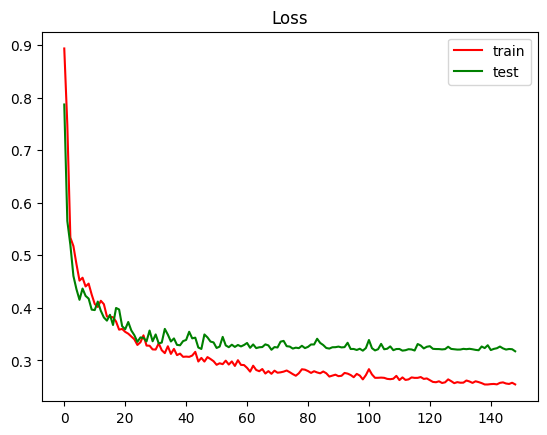

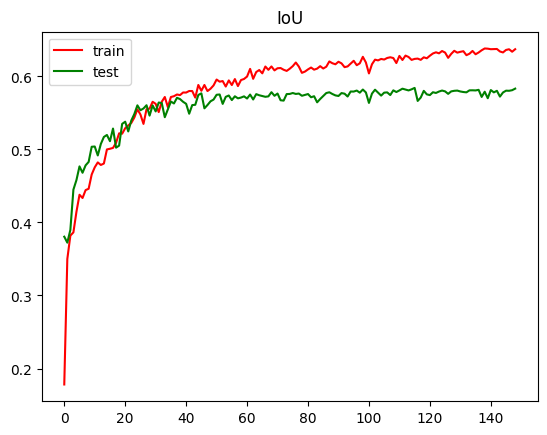

In [ ]:
save_error=False
# now = datetime.now() # current date and time
# date_time = now.strftime("%mm%dd%Yy%Hh%Mm%Ss")

x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
plt.legend(['train','test'])
plt.title("Loss")

if save_error:
    # plt.savefig('./results/checkpoints/loss_prueba'+date_time+'.png',format='png',transparent=True)
    plt.savefig('./results/checkpoints/loss_prueba'+date_time+'.pdf',format='pdf',transparent=True)

plt.show()

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
plt.legend(['train','test'])
plt.title("IoU")


if save_error:
    # plt.savefig('./results/checkpoints/error_prueba'+date_time+'.png',format='png',transparent=True)
    plt.savefig('./results/checkpoints/error_prueba'+date_time+'.pdf',format='pdf',transparent=True)

plt.show()

## Load state

In [ ]:
# # print("./results/checkpoints/"+ckpt_file+"_lr0.0005_mbgr6"+".pth")
# # checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_'+dataset_name+'_lifnode.pth')
# # checkpoint = torch.load("./results/checkpoints/"+ckpt_file+"_lr0.0005_mbgr6"+".pth")
# checkpoint = torch.load("./results/checkpoints/best_poolingnet3d_seg_lif_orgnl_wall_lr0.0004_mbgr9_10-11-2023-22h23m26s.pth")

# train_loss_vec = checkpoint['train_loss_vec_dict']
# test_loss_vec = checkpoint['test_loss_vec_dict']
# train_error_vec = checkpoint['train_error_vec_dict']
# test_error_vec = checkpoint['test_error_vec_dict']
# net.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# running_train_loss = checkpoint['running_train_loss']
# running_train_IOU = checkpoint['running_train_IOU']
# running_test_loss = checkpoint['running_test_loss']
# running_test_IOU = checkpoint['running_test_IOU']
# epoch = checkpoint['epoch']
# # epoch_test_loss = checkpoint['loss']
# # net.update_max_accuracy(epoch_test_loss)
# ckpt_train_i = checkpoint['ckpt_idx_train']
# ckpt_test_i = checkpoint['ckpt_idx_test']

In [ ]:
# ckpt_file = "poolingnet3d_seg_lif_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
ckpt_file = "best_poolingnet3d_lif_neuronlif_orgnl_mixed_train_ta00fa00wa00wa01flo01box00_lr0.0001_mbgr4_wd0.001time_win10ms_0_12-19-2024-19h39m48s"
print(ckpt_file)
checkpoint_path = "./results/checkpoints/"+ckpt_file+".pth"
checkpoint = torch.load(checkpoint_path)

best_poolingnet3d_lif_neuronlif_orgnl_mixed_train_ta00fa00wa00wa01flo01box00_lr0.0001_mbgr4_wd0.001time_win10ms_0_12-19-2024-19h39m48s


<ipython-input-8-4bc07906494c>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


In [ ]:
train_loss_vec = checkpoint['train_loss_vec_dict']
test_loss_vec = checkpoint['test_loss_vec_dict']
train_error_vec = checkpoint['train_error_vec_dict']
test_error_vec = checkpoint['test_error_vec_dict']
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
running_train_loss = checkpoint['running_train_loss']
running_train_IOU = checkpoint['running_train_IOU']
running_test_loss = checkpoint['running_test_loss']
running_test_IOU = checkpoint['running_test_IOU']
test_epoch_summary = checkpoint['test_epoch_summary']
train_epoch_summary = checkpoint['train_epoch_summary']
epoch_train_loss = checkpoint['epoch_train_loss']
epoch_test_loss = checkpoint['epoch_test_loss']
epoch = checkpoint['epoch']
# net.update_max_accuracy(epoch_test_loss)
ckpt_train_i = checkpoint['ckpt_idx_train']
ckpt_test_i = checkpoint['ckpt_idx_test']
train_done = checkpoint['train_done']
test_done = checkpoint['test_done']
train_i=0
test_i=0

In [ ]:
len(train_loss_vec)

17

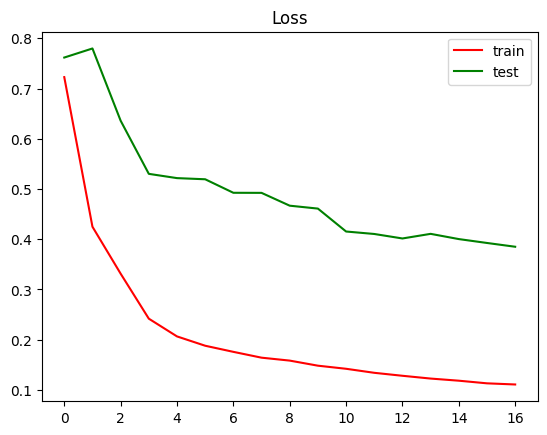

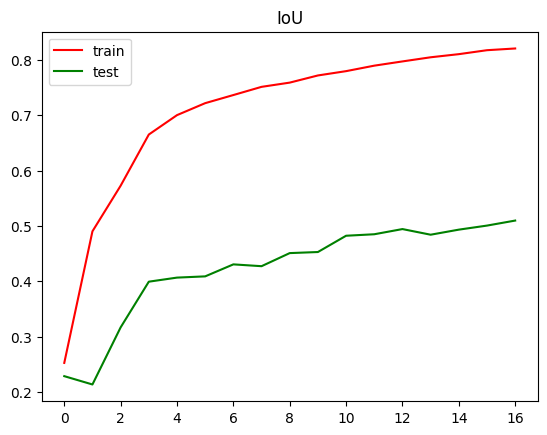

In [ ]:
save_error=False
# now = datetime.now() # current date and time
# date_time = now.strftime("%mm%dd%Yy%Hh%Mm%Ss")

x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
plt.legend(['train','test'])
plt.title("Loss")

if save_error:
    # plt.savefig('./results/checkpoints/loss_prueba'+date_time+'.png',format='png',transparent=True)
    plt.savefig('./results/checkpoints/loss_prueba'+date_time+'.pdf',format='pdf',transparent=True)

plt.show()

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
plt.legend(['train','test'])
plt.title("IoU")


if save_error:
    # plt.savefig('./results/checkpoints/error_prueba'+date_time+'.png',format='png',transparent=True)
    plt.savefig('./results/checkpoints/error_prueba'+date_time+'.pdf',format='pdf',transparent=True)

plt.show()

## Viene del "no sé, train 3" (sección de arriba) pero modificado solo para test

testing:   1%|          | 21/2994 [00:20<20:01,  2.48it/s]

22
tensor([22])
segm, batch: 0 timestep: 0


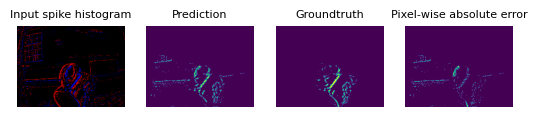

segm, batch: 0 timestep: 1


<Figure size 640x480 with 0 Axes>

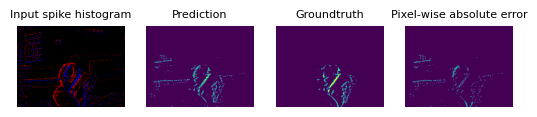

segm, batch: 0 timestep: 2


<Figure size 640x480 with 0 Axes>

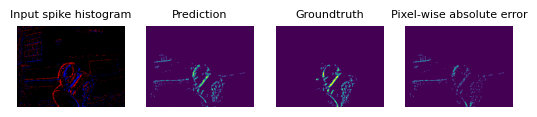

segm, batch: 0 timestep: 3


<Figure size 640x480 with 0 Axes>

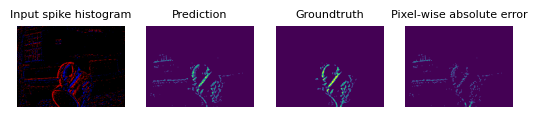

segm, batch: 0 timestep: 4


<Figure size 640x480 with 0 Axes>

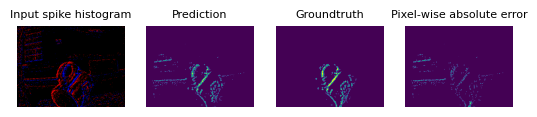

segm, batch: 0 timestep: 5


<Figure size 640x480 with 0 Axes>

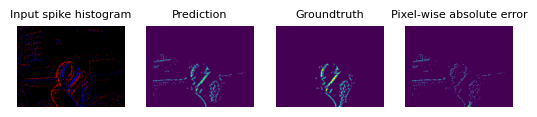

segm, batch: 0 timestep: 6


<Figure size 640x480 with 0 Axes>

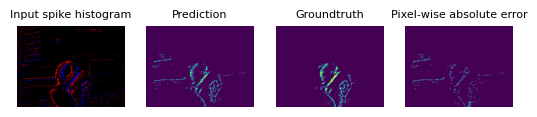

segm, batch: 0 timestep: 7


<Figure size 640x480 with 0 Axes>

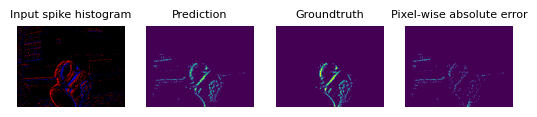

segm, batch: 0 timestep: 8


<Figure size 640x480 with 0 Axes>

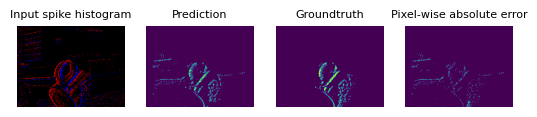

segm, batch: 0 timestep: 9


<Figure size 640x480 with 0 Axes>

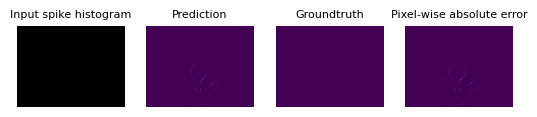

testing:   1%|          | 23/2994 [00:32<1:17:00,  1.56s/it]

Performance saved: saving model...



testing:   1%|          | 23/2994 [00:32<1:10:16,  1.42s/it]


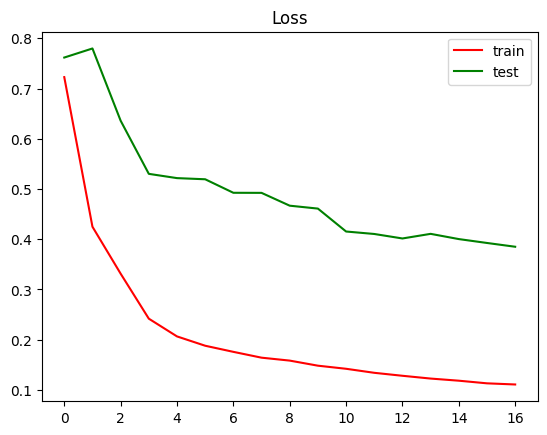

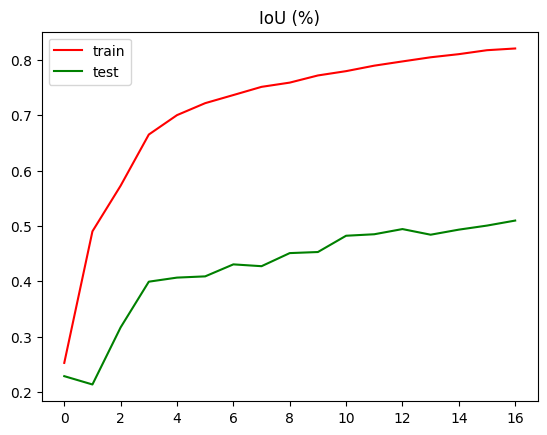

training finished !
saving training before exit....


In [ ]:
# checkpoint = {'epoch': epoch,
#             'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
#             'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
#             'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
#             'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
#             'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
#             'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
#             'train_done': train_done,'test_done': test_done,
#             'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
#             'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }

ckpt_train_i = 0
ckpt_test_i = 0
test_done = False

import sys
from datetime import datetime

try:
    from spikingjelly.activation_based import neuron, layer, surrogate
    from torch._C import dtype
    MultiStep=False
    from viz import show_learning

    # ckpt_file = "poolingnet3d_seg_SEW3D"+dataset_name+"_lifnode"

    functional.reset_net(net)
    if int(ckpt_train_i) >10:
        print("resuming training of "+dataset_name+" in epoch "+str(epoch)+" from chkpnt: train_i: "+str(int(ckpt_train_i))+", loss: "+str(running_train_loss)+", IOU: "+str(running_train_IOU))
    train_i=0
    test_i=0

    n_epochs = 1

    for epoch in range(n_epochs):
        # show=False
        # net = net.train()                                                   #<--------   0
        # start_time = time.time()

        # here must arrive when train_done = 2

    #################   TEST LOOP ##################
        if int(ckpt_test_i) >10: print("resuming testing in epoch "+str(epoch)+ "from checkpoint: test_i: "+str(ckpt_test_i)+", test_loss: "+str(running_test_loss)+", test_IOU: "+str(running_test_IOU))

        net.eval()
        show=True

        with torch.no_grad():
            start_time = time.time()
            if int(test_i) >10: print("resuming testing from i: "+str(int(test_i)))

            for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
                if test_done == True:
                    break
                if (data == None):
                    continue
                test_i += 1
                if ckpt_test_i > test_i:
                    continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

                functional.reset_net(net)
                optimizer.zero_grad()
                spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
                spikes_masked = data['masked_spike_tensor']
                # ckpt_idx_test = data['file_number']
                spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
                spikes_masked = spikes_masked.permute(0,1,4,2,3)

                print(i)
                print(data['file_number'])

                # if MultiStep:   #sums all time steps in the dim=0
                #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
                spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
                # us = nn.Upsample(scale_factor = 0.6937, mode='trilinear')
                # spikes_input = us(spikes_input)
                spikes_masked = spikes_masked.to(device)
                # spikes_masked = us(spikes_masked)
                # spikes_input.requires_grad_()
                spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
                spike_pred =  spike_pred_list[0].to(device)             # (1,1,260,346)
                # spike_pred = torch.sigmoid(spike_pred)

                if spike_pred.ndim == 4:
                    spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                    spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                    #spike_pred_4D = spike_pred
                    spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

                elif spike_pred.ndim == 5:
                    spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
                    # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                    spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

                spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
                # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
                spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
                # spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
                # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
                # spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

                # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
                # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

                if show:
                    spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                    spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                    #condition to colapse all timesteps in every batch for monitoring only
                    spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                    spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                    # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                    # print("spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                    # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                    # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                    # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                    # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                    for e in range(spike_pred.size(0)): #iterates the batches dim=0
                        for i in range(spike_pred.size(2)): #iterates the time dim=2
                            show_learning(fig,False,
                                    spikes_input[None,None,e,:,i,:,:],
                                    spike_pred_4D[:,None,i,:,:],
                                    spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

                loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)
                # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

                running_test_loss += loss.item()# / spikes_input.size(0)
                spike_pred_4D = torch.round(spike_pred_4D)
                running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

                # if i == (len(test_loader)-1):
                #     print("Testing loop finished")
                #     test_done = 1
                # print(len(test_loader))
                # print(i)
                # if int(test_i) % 100 <= 0: #condition to save intermediate trainings
                #     checkpoint = {'epoch': epoch,
                #                 'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
                #                 'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                #                 'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                #                 'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                #                 'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                #                 'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                #                 'train_done': train_done,'test_done': test_done,
                #                 'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                #                 'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                #     print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+" for "+dataset_name)
                #     torch.save(checkpoint, checkpoint_path)
                #     ckpt_test_i = test_i

            # if test_done == False:
            #     epoch_test_loss = running_test_loss / test_i #len(test_loader)
            #     epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
            #     print("\n test i: ",test_i)
            #     print("len test loader: ", len(test_loader))
            #     test_loss_vec.append(float(epoch_test_loss))
            #     test_error_vec.append(float(epoch_test_IOU))
            #     epoch_test_time = time.time() - start_time
            #     test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
            #     print(str(train_epoch_summary) + str(test_epoch_summary))

            #     net.increment_epoch()
            #     scheduler.step()

                # print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+" for "+dataset_name)
                # checkpoint = {'epoch': epoch,
                #             'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
                #             'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                #             'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                #             'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                #             'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                #             'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                #             'train_done': train_done,'test_done': test_done,
                #             'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                #             'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                # print("Test finished, saving...")
                # torch.save(checkpoint, checkpoint_path)
                # print("The size of the integer variable is:",sys.getsizeof(checkpoint), "bytes.")

                now = datetime.now() # current date and time
                date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
                print("Performance saved: saving model...\n")

                # torch.save(checkpoint, checkpoint_path)
                # print("The size of the integer variable is:",sys.getsizeof(checkpoint), "bytes.")

                # if epoch_test_loss < net.get_max_accuracy():
                #     print("Best performances so far: saving model...\n")
                #     # logfile.write("Best performances so far: saving model...\n")
                #     net.update_max_accuracy(epoch_test_loss)
                #     #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
                #     torch.save(checkpoint, "./results/checkpoints/best_"+ckpt_file+"_"+date_time+".pth")
                test_done = True
            else:
                print("Skipping testing loop...")

    ################# Training/testing plots
            x=[x for x in range(len(train_loss_vec))]
            y=[y for y in range(len(test_loss_vec))]
            plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
            plt.legend(['train','test'])
            plt.title("Loss")

            save_loss=False
            if save_loss: plt.savefig('./results/checkpoints/loss_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
            plt.show()

            x=[x for x in range(len(train_error_vec))]
            y=[y for y in range(len(test_error_vec))]
            plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
            plt.legend(['train','test'])
            plt.title("IoU (%)")

            save_error=False
            if save_error: plt.savefig('./results/checkpoints/error_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
            plt.show()

        # train_i = 0
        # test_i = 0
        # ckpt_train_i = 0
        # ckpt_test_i = 0
        # test_done = False
        # train_done = False

        # running_train_loss = 0
        # running_train_IOU = 0
        # running_test_loss = 0
        # running_test_IOU = 0
        # test_epoch_summary = 0
        # train_epoch_summary = 0
        # print("training epoch " +str(epoch)+" finished !")

    print("training finished !")
except KeyboardInterrupt:
    print("saving training before exit....keyboardinterrupt")
#     ckpt_train_i = train_i
#     ckpt_test_i = test_i
    # checkpoint = {'epoch': epoch,
    #         'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
    #         'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
    #         'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
    #         'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
    #         'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
    #         'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
    #         'train_done': train_done,'test_done': test_done,
    #         'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
    #         'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
    # torch.save(checkpoint, checkpoint_path)
#     torch.save(checkpoint, "./results/checkpoints/"+ckpt_file+".pth")

except OSError:
    print("saving training before exit.... oserror")

else:
     print("saving training before exit....")

## Para poolingnet3d_lif

In [ ]:
import json
from datetime import datetime
# # print("./results/checkpoints/"+ckpt_file+"5.pth")
# ckpt_file = "poolingnet3d_seg_lif_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)


# checkpoint_path = "./results/checkpoints/"+ckpt_file+".pth"
# # # checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_'+dataset_name+'_lifnode.pth')
# # checkpoint = torch.load("./results/checkpoints/"+ckpt_file+"5.pth")
# checkpoint = torch.load(checkpoint_path)
# print("Starting training: "+checkpoint)
import sys
try:
    from spikingjelly.activation_based import neuron, layer, surrogate
    from torch._C import dtype
    MultiStep=False
    from viz import show_learning

    # ckpt_file = "poolingnet3d_seg_SEW3D"+dataset_name+"_lifnode"

    functional.reset_net(net)
    # if int(ckpt_train_i) >10:
    #     print("resuming training of "+dataset_name+" in epoch "+str(net.epoch)+" from chkpnt: train_i: "+str(int(ckpt_train_i))+", loss: "+str(running_train_loss)+", IOU: "+str(running_train_IOU))
    train_i=0
    test_i=0

    test_done = False

    for epoch in range(n_epochs):
        print("Scheduler's parameters: \n")
        print(json.dumps(scheduler.state_dict(), indent=4))
        show=True

    #################   TEST LOOP ##################
        # if int(ckpt_test_i) >10:
        #     print("resuming testing in epoch "+str(net.epoch)+ "from checkpoint: test_i: "+str(ckpt_test_i)+", test_loss: "+str(running_test_loss)+", test_IOU: "+str(running_test_IOU))

        net.eval()
        show=True

        with torch.no_grad():
            start_time = time.time()
            if int(test_i) >10: print("resuming testing from sequence: "+str(int(test_i)))

            for i, data in enumerate(tqdm(test_loader, desc='testing')):                #loader --> train_loader
                if test_done == True:
                    break
                if (data == None):
                    continue
                test_i += 1
                # if ckpt_test_i > test_i:
                #     continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

                functional.reset_net(net)
                optimizer.zero_grad()
                spikes_input = data['spike_tensor']                                     #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
                spikes_masked = data['masked_spike_tensor']
                # ckpt_idx_test = data['file_number']
                spikes_input = spikes_input.permute(0,1,4,2,3)                          #   torch.Size([8, 2, 21, 260, 346])
                spikes_masked = spikes_masked.permute(0,1,4,2,3)
                # if MultiStep:   #sums all time steps in the dim=0
                #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
                spikes_input = spikes_input.to(device)                                  #   torch.Size([B,C,T,260, 346])
                # us = nn.Upsample(scale_factor = 0.6937, mode='trilinear')
                # spikes_input = us(spikes_input)
                spikes_masked = spikes_masked.to(device)
                # spikes_masked = us(spikes_masked)
                # spikes_input.requires_grad_()
                spike_pred_list =  net(spikes_input)                                    # len(spike_pred_list) = 4
                spike_pred =  spike_pred_list[0].to(device)                             # (1,1,260,346)
                # spike_pred = torch.sigmoid(spike_pred)

                if spike_pred.ndim == 4:
                    spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                    spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                    #spike_pred_4D = spike_pred
                    spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True)      #

                elif spike_pred.ndim == 5:
                    spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
                    # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                    spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

                spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False)    #or and remove of B dim

                spike_mask_4D = torch.mul(spike_mask_4D,1.)                             #conversion from bool to numbers

                if show:
                    spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                    spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                    #condition to colapse all timesteps in every batch for monitoring only
                    spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)   #  (B,C,T,H,W)-->(B,C,1,H,W)
                    spike_input_5D = spike_input_5D.permute(0,2,1,3,4)                  #  (B,1,C,H,W)

                    for e in range(spike_pred.size(0)): #iterates the batches dim=0
                        for i in range(spike_pred.size(2)): #iterates the time dim=2
                            show_learning(fig,False,
                                    spikes_input[None,None,e,:,i,:,:],
                                    spike_pred_4D[:,None,i,:,:],
                                    spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

                loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)
                # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

                running_test_loss += loss.item()# / spikes_input.size(0)
                spike_pred_4D = torch.round(spike_pred_4D)
                running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

                if int(test_i) % 100 <= 0: #condition to save intermediate trainings
                    checkpoint = {'epoch': net.epoch,
                                'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(), 'scheduler_state_dict': scheduler.state_dict(),
                                'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                                'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                                'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                                'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                                'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                                'train_done': train_done,'test_done': test_done,
                                'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                                'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                    print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+" for "+dataset_name)
                    torch.save(checkpoint, checkpoint_path)
                    ckpt_test_i = test_i

            if test_done == False:
                epoch_test_loss = running_test_loss / test_i #len(test_loader)
                epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
                print("\n Procesed test sequences: ",test_i)
                print("len test loader: ", len(test_loader))
                test_loss_vec.append(float(epoch_test_loss))
                test_error_vec.append(float(epoch_test_IOU))
                epoch_test_time = time.time() - start_time
                test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(net.epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
                print(str(train_epoch_summary) + str(test_epoch_summary))

                net.increment_epoch()
                scheduler.step(epoch_test_loss)
                test_done = True

                # print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+" for "+dataset_name)
                checkpoint = {'epoch': net.epoch,
                            'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(), 'scheduler_state_dict': scheduler.state_dict(),
                            'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                            'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                            'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                            'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                            'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                            'train_done': train_done,'test_done': test_done,
                            'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                            'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                print("Test finished, saving...")
                torch.save(checkpoint, checkpoint_path)
                # print("The size of the integer variable is:",sys.getsizeof(checkpoint), "bytes.")

                now = datetime.now() # current date and time
                date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
                print("Performance saved: saving model...\n")

                torch.save(checkpoint, checkpoint_path)
                # print("The size of the integer variable is:",sys.getsizeof(checkpoint), "bytes.")

                if epoch_test_loss < net.get_max_accuracy():
                    print("Best performances so far: saving model...\n")
                    # logfile.write("Best performances so far: saving model...\n")
                    net.update_max_accuracy(epoch_test_loss)
                    #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
                    torch.save(checkpoint, "./results/checkpoints/best_epoch"+str(scheduler.last_epoch)+"_"+ckpt_file+"_"+date_time+".pth")

            else:
                print("Skipping testing loop")
                date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
    ################# Training/testing plots
            x=[x for x in range(len(train_loss_vec))]
            y=[y for y in range(len(test_loss_vec))]
            plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
            plt.legend(['train','test'])
            plt.title("Loss of "+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience))

            save_loss=False
            if save_loss: plt.savefig('./results/checkpoints/loss_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
            plt.show()

            x=[x for x in range(len(train_error_vec))]
            y=[y for y in range(len(test_error_vec))]
            plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
            plt.legend(['train','test'])
            plt.title("IoU (%) of "+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience))

            save_error=False
            if save_error: plt.savefig('./results/checkpoints/error_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
            plt.show()

        train_i = 0
        test_i = 0
        ckpt_train_i = 0
        ckpt_test_i = 0
        test_done = False
        train_done = False
        epoch += 1

        running_train_loss = 0
        running_train_IOU = 0
        running_test_loss = 0
        running_test_IOU = 0
        test_epoch_summary = 0
        train_epoch_summary = 0
        print("training epoch " +str(net.epoch)+" finished !")

    print("training finished !")
except KeyboardInterrupt:
    print("saving training before exit....keyboardinterrupt")

except OSError:
    print("saving training before exit.... oserror")


else:
     print("saving training before exit....")

Output hidden; open in https://colab.research.google.com to view.

## Test loop para ./results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lr_5_3_super.pth

In [ ]:
try:
  print(epoch_load)
except:
  epoch_load = 0

print(epoch_load)

print(train_loss_vec[-1])
print(test_loss_vec[-1])
print(train_error_vec[-1])
print(test_error_vec[-1])

# train_loss_vec = []
# train_error_vec = []
# test_loss_vec = []
# test_error_vec = []

total_MSE = 0
total_IOU = 0
scalar_i = 0
tot_frames = 0

0
0.1106918002944554
0.38493332154250054
0.8207081401308027
0.5096036564116516


In [ ]:
from spikingjelly.clock_driven import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning, show_learning_pred

functional.reset_net(net)
n_epochs = 300
test_i = 0

running_test_loss = 0
running_test_IOU = 0

save = False

#print(prediction_root)

with torch.no_grad():
    start_time = time.time()
    show = False
    for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
        if (data == None):
            continue
        test_i += 1
        functional.reset_net(net)
        optimizer.zero_grad()
        spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
        spikes_masked = data['masked_spike_tensor']

        # print("spikes_input: ", spikes_input.shape)

        spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
        spikes_masked = spikes_masked.permute(0,1,4,2,3)

        spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
        spikes_masked = spikes_masked.to(device)
        spikes_input.requires_grad_()
        start_time_net = time.time()
        spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4

        # print("Test time: ", stop_time_net - start_time_net)

        # spike_pred =  spike_pred_list[2].to(device)             # (1,1,260,346)
        spike_pred =  spike_pred_list[0].to(device)             # (1,1,260,346)

        spike_pred = torch.sigmoid(spike_pred)
        stop_time_net = time.time()

        # print(i)
        # print(data['file_number'])
        # print("time_start:")
        # print(data['time_start'])

        if spike_pred.ndim == 4:
            spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
            spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
            #spike_pred_4D = spike_pred
            spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

        elif spike_pred.ndim == 5:
            spike_pred_4D = torch.sum(spike_pred, axis = (2))           #torch.Size([B, 1, 260, 346])
            spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
            spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

        spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
        spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
        spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

        if show:
            #condition to colapse all timesteps in every batch
            spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
            spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
            for e in range(spike_input_5D.size(0)):
                show_learning_pred(fig,save,
                              spike_input_5D[None,e,:,:,:,:],
                              spike_pred_4D[None,e,:,:,:],
                              spike_mask_4D[None,e,:,:,:], prediction_root,'segm, batch '+str(e),i)
                # show_learning(fig,False,
                #               spike_input_5D[None,e,:,:,:,:],
                #               spike_pred_4D[None,e,:,:,:],
                #               spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)  #plt.fig,Save,[B,1,2,260,346],  [B, 1, 260, 346], [B, 1, 260, 346], text,       i
            #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

        loss = loss_module(spike_pred_4D, spike_mask_4D,weightbce=0.1)

        running_test_loss += loss / spikes_input.size(0)
        spike_pred = torch.round(spike_pred)
        running_test_IOU += getIOU(spike_pred, spike_mask_4D)

            # process saved metrics
    if test_i != 0:
        epoch_test_loss = running_test_loss / test_i #len(test_loader)
        epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
        print("\n test i: ",test_i)
        print("len test loader: ", len(test_loader))
        # test_loss_vec.append(float(epoch_test_loss))
        # test_error_vec.append(float(epoch_test_IOU))
        # test_error_vec.append(float(epoch_test_IOU[-1]))
        epoch_test_time = time.time() - start_time
        test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(0, epoch_test_loss,epoch_test_IOU,epoch_test_time)
        print(test_epoch_summary)
        # logfile.write(test_epoch_summary)

    # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
    # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)

    # net.increment_epoch()
    # scheduler.step()
    # # Training/testing plots
    x=[x for x in range(len(train_loss_vec))]
    y=[y for y in range(len(test_loss_vec))]
    plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
    plt.title("Loss")
    plt.xlabel("Épocas")
    plt.ylabel("Pérdida")
    plt.show()

    x=[x for x in range(len(train_error_vec))]
    y=[y for y in range(len(test_error_vec))]
    plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
    plt.title("IoU (%)")
    plt.xlabel("Épocas")
    plt.ylabel("IOU")
    plt.show()
print("training finished !")

testing:   1%|          | 22/2994 [00:03<07:26,  6.66it/s]


ValueError: Using a target size (torch.Size([1, 1, 260, 346])) that is different to the input size (torch.Size([1, 2, 260, 346])) is deprecated. Please ensure they have the same size.

## Para antiguos modelos

testing:   0%|          | 0/1497 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
testing:   1%|          | 9/1497 [00:00<01:22, 18.07it/s]

Test time:  0.8504757881164551
segm, batch 0


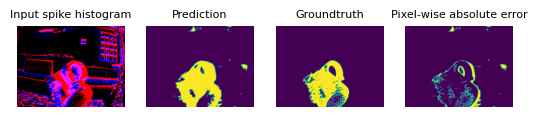

segm, batch 1


<Figure size 640x480 with 0 Axes>

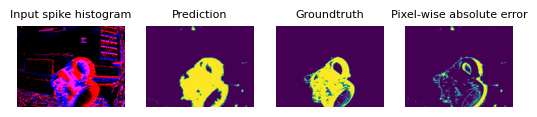

testing:   1%|          | 12/1497 [00:06<17:57,  1.38it/s]

Test time:  0.2243490219116211
segm, batch 0


<Figure size 640x480 with 0 Axes>

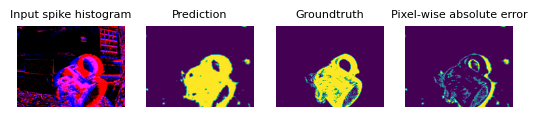

segm, batch 1


<Figure size 640x480 with 0 Axes>

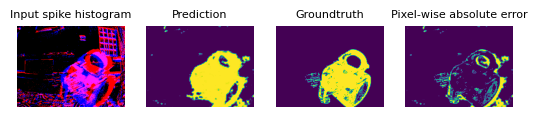

Test time:  0.23869848251342773
segm, batch 0


testing:   1%|          | 13/1497 [00:11<22:19,  1.11it/s]


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

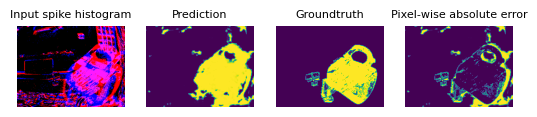

In [ ]:
from spikingjelly.clock_driven import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning

functional.reset_net(net)
n_epochs = 300
test_i = 0

running_test_loss = 0
running_test_IOU = 0

with torch.no_grad():
    start_time = time.time()
    show = True
    for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
        if (data == None):
            continue
        test_i += 1
        functional.reset_net(net)
        optimizer.zero_grad()
        spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
        spikes_masked = data['masked_spike_tensor']

        # print("spikes_input: ", spikes_input.shape)

        spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
        spikes_masked = spikes_masked.permute(0,1,4,2,3)

        spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
        spikes_masked = spikes_masked.to(device)
        spikes_input.requires_grad_()
        start_time_net = time.time()
        spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
        stop_time_net = time.time()
        print("Test time: ", stop_time_net - start_time_net)

        spike_pred =  spike_pred_list[2].to(device)             # (1,1,260,346)

        spike_pred = torch.sigmoid(spike_pred)

        if spike_pred.ndim == 4:
            spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
            spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
            #spike_pred_4D = spike_pred
            spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

        elif spike_pred.ndim == 5:
            spike_pred_4D = torch.sum(spike_pred, axis = (2))           #torch.Size([B, 1, 260, 346])
            spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
            spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

        spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
        spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
        spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

        if show:
            #condition to colapse all timesteps in every batch
            spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
            spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
            for e in range(spike_input_5D.size(0)):
                show_learning(fig,True,
                              spike_input_5D[None,e,:,:,:,:],
                              spike_pred_4D[None,e,:,:,:],
                              spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)  #plt.fig,Save,[B,1,2,260,346],  [B, 1, 260, 346], [B, 1, 260, 346], text,       i
            #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

        loss = loss_module(spike_pred_4D, spike_mask_4D,weightbce=0.1)

        running_test_loss += loss / spikes_input.size(0)
        spike_pred = torch.round(spike_pred)
        running_test_IOU += getIOU(spike_pred, spike_mask_4D)

            # process saved metrics
    if test_i != 0:
        epoch_test_loss = running_test_loss / test_i #len(test_loader)
        epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
        print("\n test i: ",test_i)
        print("len test loader: ", len(test_loader))
        # test_loss_vec.append(float(epoch_test_loss))
        # test_error_vec.append(float(epoch_test_IOU))
        # test_error_vec.append(float(epoch_test_IOU[-1]))
        epoch_test_time = time.time() - start_time
        test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(0, epoch_test_loss,epoch_test_IOU,epoch_test_time)
        print(test_epoch_summary)
        # logfile.write(test_epoch_summary)

    # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
    # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)

    # net.increment_epoch()
    # scheduler.step()
    # # Training/testing plots
    x=[x for x in range(len(train_loss_vec))]
    y=[y for y in range(len(test_loss_vec))]
    plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
    plt.title("Loss")
    plt.xlabel("Épocas")
    plt.ylabel("Pérdida")
    plt.show()

    x=[x for x in range(len(train_error_vec))]
    y=[y for y in range(len(test_error_vec))]
    plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
    plt.title("IoU (%)")
    plt.xlabel("Épocas")
    plt.ylabel("IOU")
    plt.show()
print("training finished !")

# **Generar video de resultados**

In [ ]:
dir=str('/content/drive/MyDrive/StereoSpike/results/visualizations2/')
make_vid_from_pngs(dir, (2160,1440), 20, 'results/preds_08_04_24.mp4') #1700,403 from viz.py
#Lee las imagenes que estan en el directorio indicado y crea un video con el nombre de arriba
#TENER PREVIAMENTE LAS IMAGENES GUARDADAS

In [ ]:
#HACER UN LOADING STATE ANTES PARA CARGAR EL ENTRENAMIENTO
x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'-',y,test_loss_vec,'-')
plt.title("Loss")
plt.legend(['Train Loss', 'Test Loss'])
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.show()

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'-',y,test_error_vec, '-')
plt.title("IoU (%)")
plt.xlabel("Épocas")
plt.ylabel("IoU")
plt.legend(['Train IoU', 'Test IoU'],loc = "lower right")
plt.show()

print(train_loss_vec[-1])
print(test_loss_vec[-1])
print(train_error_vec[-1])
print(test_error_vec[-1])

# Otra manera de crear el video, pero lo que

In [ ]:
import cv2
DAVIS_FPS = 10
png_folder = "./results/visualizations2/wall/"
def mvsecToVideo(images):
    """
    Produces a video file with DAVIS grayscale images.
    This allows to visualize more easily the dataset footage.

    :param images: DAVIS left or right image
    :return:
    """
    print("\nMerging frames of the sequence into a video for visualization...")
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')#*'DIVX'
    # fourcc = cv2.VideoWriter_fourcc(*'DIVX')
    # out = cv2.VideoWriter('wall_video.mp4', fourcc, DAVIS_FPS, (346, 260))
    out = cv2.VideoWriter('wall_video_complete_10fps.mp4', fourcc, DAVIS_FPS, (4608, 3456),isColor=True)
    # out = cv2.VideoWriter('grayscale.avi', fourcc, DAVIS_FPS, (4608, 3456),isColor=True)


    #for i in tqdm(range(len(images))):
    for image in images:
        #f = images[i]
        # print(image)
        path =png_folder + image
        print
        f = cv2.imread(path)
        # print(path)
        # print(f.shape)
        # f = image
        # f = np.nan_to_num(f, copy=True,
        #                   nan=255)  # small processing of the depth maps; DO NOT DO THIS FOR TRAINING A SNN
        f = cv2.normalize(f, None, 0, 255, cv2.NORM_MINMAX)
        # f = cv2.cvtColor(f, cv2.COLOR_GRAY2RGB)
        f = f.astype(np.uint8)

        #cv2.imshow("grayscale", f)
        #cv2_imshow("grayscale", f)
        out.write(f)
        cv2.waitKey(int(1000 / DAVIS_FPS))

    out.release()

In [ ]:

import cv2

images_path = os.listdir('./results/visualizations2/wall/')
mvsecToVideo(images_path)

In [ ]:
running_test_loss = 0
running_test_IOU = 0
self.net.eval()
show=False

with torch.no_grad():
  start_time = time.time()
  for i, data in enumerate(tqdm(self.test_loader, desc='testing')):  #loader --> train_loader
    if (data == None):
      continue
    test_i += 1
    functional.reset_net(self.net)
    self.optimizer.zero_grad()
    spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
    spikes_masked = data['masked_spike_tensor']
    spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
    spikes_masked = spikes_masked.permute(0,1,4,2,3)
    spikes_input = spikes_input.to(self.gpu_id)              #   torch.Size([B,C,T,260, 346])
    spikes_masked = spikes_masked.to(self.gpu_id)
    spikes_input.requires_grad_()

    spike_pred_list =  self.net.module(spikes_input)
    spike_pred =  spike_pred_list[0].to(self.gpu_id)
    # spike_pred =  spike_pred_list.to(self.gpu_id)
    # print("spike_pred: ", spike_pred.shape)
    spike_pred = torch.sigmoid(spike_pred)
    spike_pred = spike_pred[None,:,:,:]
    # print("spike_pred1: ", spike_pred.shape)

    if spike_pred.ndim == 4:
      spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
      spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
      #spike_pred_4D = spike_pred
      spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #
      #spike_input_crop  =  spikes_input[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (B,2,21,260,346)
      #spikes_masked_crop = spikes_masked[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (B,1,1,260,346)
      #spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

    elif spike_pred.ndim == 5:
      spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
      # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
      spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5
      #spike_pred_4D = torch.sum(spike_pred, axis = (2))               #torch.Size([B, 1, 260, 346])
      #spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
      #spikes_masked_crop =spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5

    spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
    spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers


    #loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=1)
    loss = self.loss_module(spike_pred_4D, spike_mask_4D,weightbce=0.1)        #<--------  3


    running_test_loss += loss / spikes_input.size(0)
    spike_pred = torch.round(spike_pred)
    running_test_IOU += getIOU(spike_pred, spike_mask_4D)

      # process saved metrics
  if test_i != 0:
    epoch_test_loss = running_test_loss / test_i #len(test_loader)
    epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
    print("\n test i: ",test_i)
    print("len test loader: ", len(self.test_loader))
    test_loss_vec.append(float(epoch_test_loss))
    test_error_vec.append(float(epoch_test_IOU))
    epoch_test_time = time.time() - start_time
    test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
    print(train_epoch_summary + test_epoch_summary)
    # logfile.write(train_epoch_summary + test_epoch_summary)

  if self.gpu_id == 0 and epoch_test_loss < best_accuracy:
    print("Best performances so far: saving model...\n")
    # logfile.write("Best performances so far: saving model...\n")
    best_accuracy = epoch_test_loss
    # self.net.update_max_accuracy(epoch_test_loss)
    #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
    torch.save({'epoch': epoch, 'model_state_dict': self.net.module.state_dict(),
          'optimizer_state_dict': self.optimizer.state_dict(),
          'loss': epoch_test_loss, 'train_loss_vec_dict': train_loss_vec,
          'test_loss_vec_dict': test_loss_vec,
          'train_error_vec_dict': train_error_vec,
          'test_error_vec_dict': test_error_vec
          # }, "./results/checkpoints/stereospike_seg_sergio4.pth")
          }, "/home/aircv1/Data/Gerardo/Daniela/StereoSpike/results/checkpoints/poolingnet3d_box_max1_5_batch.pth")

  #self.train_data.sampler.set_epoch(epoch)
  # self.net.increment_epoch()
  self.scheduler.step()

# Exportar event windows

In [ ]:
import json
# # print("./results/checkpoints/"+ckpt_file+"5.pth")
# ckpt_file = "poolingnet3d_seg_lif_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)


# checkpoint_path = "./results/checkpoints/"+ckpt_file+".pth"
# # # checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_'+dataset_name+'_lifnode.pth')
# # checkpoint = torch.load("./results/checkpoints/"+ckpt_file+"5.pth")
# checkpoint = torch.load(checkpoint_path)
# print("Starting training: "+checkpoint)
import sys
try:
    from spikingjelly.activation_based import neuron, layer, surrogate
    from torch._C import dtype
    MultiStep=False
    from viz import show_learning

    # ckpt_file = "poolingnet3d_seg_SEW3D"+dataset_name+"_lifnode"

    functional.reset_net(net)
    # if int(ckpt_train_i) >10:
    #     print("resuming training of "+dataset_name+" in epoch "+str(net.epoch)+" from chkpnt: train_i: "+str(int(ckpt_train_i))+", loss: "+str(running_train_loss)+", IOU: "+str(running_train_IOU))
    train_i=0
    test_i=0

    test_done = False

    for epoch in range(n_epochs):
        print("Scheduler's parameters: \n")
        print(json.dumps(scheduler.state_dict(), indent=4))
        show=True

    #################   TEST LOOP ##################
        # if int(ckpt_test_i) >10:
        #     print("resuming testing in epoch "+str(net.epoch)+ "from checkpoint: test_i: "+str(ckpt_test_i)+", test_loss: "+str(running_test_loss)+", test_IOU: "+str(running_test_IOU))

        net.eval()
        show=True

        with torch.no_grad():
            start_time = time.time()
            if int(test_i) >10: print("resuming testing from sequence: "+str(int(test_i)))

            for i, data in enumerate(tqdm(test_loader, desc='testing')):                #loader --> train_loader
                if test_done == True:
                    break
                if (data == None):
                    continue
                test_i += 1
                # if ckpt_test_i > test_i:
                #     continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

                functional.reset_net(net)
                optimizer.zero_grad()
                spikes_input = data['spike_tensor']                                     #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
                spikes_masked = data['masked_spike_tensor']
                # ckpt_idx_test = data['file_number']
                spikes_input = spikes_input.permute(0,1,4,2,3)                          #   torch.Size([8, 2, 21, 260, 346])
                spikes_masked = spikes_masked.permute(0,1,4,2,3)
                # if MultiStep:   #sums all time steps in the dim=0
                #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
                spikes_input = spikes_input.to(device)                                  #   torch.Size([B,C,T,260, 346])
                # us = nn.Upsample(scale_factor = 0.6937, mode='trilinear')
                # spikes_input = us(spikes_input)
                spikes_masked = spikes_masked.to(device)
                # spikes_masked = us(spikes_masked)
                # spikes_input.requires_grad_()
                spike_pred_list =  net(spikes_input)                                    # len(spike_pred_list) = 4
                spike_pred =  spike_pred_list[0].to(device)                             # (1,1,260,346)
                # spike_pred = torch.sigmoid(spike_pred)

                if spike_pred.ndim == 4:
                    spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                    spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                    #spike_pred_4D = spike_pred
                    spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True)      #

                elif spike_pred.ndim == 5:
                    spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
                    # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                    spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

                spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False)    #or and remove of B dim

                spike_mask_4D = torch.mul(spike_mask_4D,1.)                             #conversion from bool to numbers

                if show:
                    spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                    spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                    #condition to colapse all timesteps in every batch for monitoring only
                    spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)   #  (B,C,T,H,W)-->(B,C,1,H,W)
                    spike_input_5D = spike_input_5D.permute(0,2,1,3,4)                  #  (B,1,C,H,W)

                    for e in range(spike_pred.size(0)): #iterates the batches dim=0
                        for i in range(spike_pred.size(2)): #iterates the time dim=2
                            show_learning(fig,False,
                                    spikes_input[None,None,e,:,i,:,:],
                                    spike_pred_4D[:,None,i,:,:],
                                    spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

                loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)
                # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

                running_test_loss += loss.item()# / spikes_input.size(0)
                spike_pred_4D = torch.round(spike_pred_4D)
                running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

                if int(test_i) % 100 <= 0: #condition to save intermediate trainings
                    checkpoint = {'epoch': net.epoch,
                                'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(), 'scheduler_state_dict': scheduler.state_dict(),
                                'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                                'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                                'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                                'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                                'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                                'train_done': train_done,'test_done': test_done,
                                'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                                'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                    print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+" for "+dataset_name)
                    torch.save(checkpoint, checkpoint_path)
                    ckpt_test_i = test_i

            if test_done == False:
                epoch_test_loss = running_test_loss / test_i #len(test_loader)
                epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
                print("\n Procesed test sequences: ",test_i)
                print("len test loader: ", len(test_loader))
                test_loss_vec.append(float(epoch_test_loss))
                test_error_vec.append(float(epoch_test_IOU))
                epoch_test_time = time.time() - start_time
                test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(net.epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
                print(str(train_epoch_summary) + str(test_epoch_summary))

                net.increment_epoch()
                scheduler.step(epoch_test_loss)
                test_done = True

                # print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+" for "+dataset_name)
                checkpoint = {'epoch': net.epoch,
                            'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(), 'scheduler_state_dict': scheduler.state_dict(),
                            'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                            'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                            'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                            'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                            'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                            'train_done': train_done,'test_done': test_done,
                            'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                            'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                print("Test finished, saving...")
                torch.save(checkpoint, checkpoint_path)
                # print("The size of the integer variable is:",sys.getsizeof(checkpoint), "bytes.")

                now = datetime.now() # current date and time
                date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
                print("Performance saved: saving model...\n")

                torch.save(checkpoint, checkpoint_path)
                # print("The size of the integer variable is:",sys.getsizeof(checkpoint), "bytes.")

                if epoch_test_loss < net.get_max_accuracy():
                    print("Best performances so far: saving model...\n")
                    # logfile.write("Best performances so far: saving model...\n")
                    net.update_max_accuracy(epoch_test_loss)
                    #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
                    torch.save(checkpoint, "./results/checkpoints/best_epoch"+str(scheduler.last_epoch)+"_"+ckpt_file+"_"+date_time+".pth")

            else:
                print("Skipping testing loop")
                date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
    ################# Training/testing plots
            x=[x for x in range(len(train_loss_vec))]
            y=[y for y in range(len(test_loss_vec))]
            plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
            plt.legend(['train','test'])
            plt.title("Loss of "+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience))

            save_loss=False
            if save_loss: plt.savefig('./results/checkpoints/loss_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
            plt.show()

            x=[x for x in range(len(train_error_vec))]
            y=[y for y in range(len(test_error_vec))]
            plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
            plt.legend(['train','test'])
            plt.title("IoU (%) of "+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience))

            save_error=False
            if save_error: plt.savefig('./results/checkpoints/error_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
            plt.show()

        train_i = 0
        test_i = 0
        ckpt_train_i = 0
        ckpt_test_i = 0
        test_done = False
        train_done = False
        epoch += 1

        running_train_loss = 0
        running_train_IOU = 0
        running_test_loss = 0
        running_test_IOU = 0
        test_epoch_summary = 0
        train_epoch_summary = 0
        print("training epoch " +str(net.epoch)+" finished !")

    print("training finished !")
except KeyboardInterrupt:
    print("saving training before exit....keyboardinterrupt")

except OSError:
    print("saving training before exit.... oserror")


else:
     print("saving training before exit....")

# Exportar las imágenes sincronizadas con los timestamps

In [ ]:
import decimal

def find_decimals(value):
    return (abs(decimal.Decimal(str(value)).as_tuple().exponent))

# Floats
print (find_decimals(123.45678))
print (find_decimals(0.00001))

# Scientific Notation
print (find_decimals(1e-05))

# Strings
print (find_decimals('123.45678'))
print (find_decimals('0.00001'))
print (find_decimals('1e-05'))

# from decimal import Decimal
# d = Decimal(56.4325)

# print(d)

5
5
5
5
5
5


In [ ]:
# 1.056543-0.532683
# 1.056543-0.532684
# str(round((1.056543-0.532683),7))
print (find_decimals(1.056543-0.532684))

6


In [ ]:
!python /content/drive/MyDrive/StereoSpike/datasets/manage_dataset.py -w 0.01 -m 1000 -f /content/drive/MyDrive/datasets/EVIMO_Dataset/eval/table/txt/seq_00 -fs /content/drive/MyDrive/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img_synchronized #

Starting folder /content/drive/MyDrive/datasets/EVIMO_Dataset/eval/table/txt/seq_00
Starting folder /content/drive/MyDrive/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img_synchronized
maskfilenm:  /content/drive/MyDrive/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img/depth_mask_1.png
timeframes:  1
  0% 0/13010266 [00:00<?, ?it/s]reached 0.036229 0.046229
  0% 57195/13010266 [00:00<00:22, 571836.02it/s]curr_maskfilenm:  /content/drive/MyDrive/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img/depth_mask_2.png
curr_mask_num:  1
timeframes:  2
 
  1% 141463/13010266 [00:01<01:57, 109343.38it/s]curr_maskfilenm:  /content/drive/MyDrive/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img/depth_mask_3.png
curr_mask_num:  2
timeframes:  3
 
  1% 180691/13010266 [00:02<03:10, 67261.49it/s]curr_maskfilenm:  /content/drive/MyDrive/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img/depth_mask_4.png
curr_mask_num:  3
timeframes:  4
 
  2% 209340/13010266 [00:03<04:06, 51977.37it/s]curr_maskfilenm:  /co

In [ ]:
!python /content/drive/MyDrive/StereoSpike/datasets/manage_dataset.py -w 0.01 -m 1000 -f /content/drive/MyDrive/datasets/EVIMO_Dataset/train/box/txt/seq_01 -fs /content/drive/MyDrive/datasets/EVIMO_Dataset/train/box/txt/seq_01/img_synchronized #

Se truncaron las últimas líneas 5000 del resultado de transmisión.
curr_mask_num:  877
timeframes:  878
 
 33% 15850403/48133406 [14:21<51:45, 10395.84it/s] curr_maskfilenm:  /content/drive/MyDrive/datasets/EVIMO_Dataset/train/box/txt/seq_01/img/depth_mask_884.png
curr_mask_num:  878
timeframes:  879
 
 33% 15860943/48133406 [14:22<52:40, 10210.97it/s]curr_maskfilenm:  /content/drive/MyDrive/datasets/EVIMO_Dataset/train/box/txt/seq_01/img/depth_mask_885.png
curr_mask_num:  879
timeframes:  880
 
 33% 15871770/48133406 [14:23<51:36, 10417.33it/s]curr_maskfilenm:  /content/drive/MyDrive/datasets/EVIMO_Dataset/train/box/txt/seq_01/img/depth_mask_886.png
curr_mask_num:  880
timeframes:  881
 
 33% 15886433/48133406 [14:24<45:11, 11892.56it/s]curr_maskfilenm:  /content/drive/MyDrive/datasets/EVIMO_Dataset/train/box/txt/seq_01/img/depth_mask_887.png
curr_mask_num:  881
timeframes:  882
 
 33% 15895867/48133406 [14:25<47:19, 11351.89it/s]curr_maskfilenm:  /content/drive/MyDrive/datasets/EVIMO

**Instrucciones**

Correr para MVSEC

En el programa modificar:

*   datafile
*   root
*   outhdf5
*   valid_time
*   img.save

ruta de los datasets: "/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/data/" + name_seq + "_modificated/" + name_seq + str(num_seq) + "_" + str(ms_seq) + "ms.hdf5"






In [ ]:
import h5py
import numpy as np
import argparse
from PIL import Image
import os
from tqdm import tqdm
import shutil
import pathlib
#import cv2

FRAME_SIZE = (346, 260)
FRAME_W = 346
FRAME_H = 260
LIDAR_FPS = 20
DAVIS_FPS = 50

In [ ]:
def mvsecLoadRectificationMaps(Lx_path, Ly_path, Rx_path, Ry_path):
    """
    Loads the rectification maps for further calibration of DAVIS' spike events coordinates.

    :param Lx_path: path of the .txt file containing the mapping of the x coordinate for the left DAVIS camera
    :param Ly_path:                     ..                              y        ..          left
    :param Rx_path:                     ..                              x        ..          right
    :param Ry_path:                     ..                              y        ..          right
    :return: all corresponding mapping matrices in the form of a numpy array
    """
    print("\nloading rectification maps...")
    Lx_map = np.loadtxt(Lx_path)
    Ly_map = np.loadtxt(Ly_path)
    Rx_map = np.loadtxt(Rx_path)
    Ry_map = np.loadtxt(Ry_path)
    return Lx_map, Ly_map, Rx_map, Ry_map


def mvsecRectifyEvents(events, x_map, y_map):
    """
    Rectifies the spatial coordinates of the input spike events in accordance to the given mapping matrices.
    CAUTION: make sure events and maps correspond to the same side (DAVIS/left or DAVIS/right) !

    :param events: a list of spike events to the format [X, Y, TIME, POLARITY]
    :param x_map: np.array obtained by mvsecLoadRectificationMaps() function
    :param y_map:                       ..
    :return: rectified events, in the same format as the input events
    """
    print("\nrectifying spike coordinates...")
    rect_events = []
    for event in tqdm(events):
        x = int(event[0])
        y = int(event[1])
        x_rect = x_map[y, x]
        y_rect = y_map[y, x]
        rect_events.append([x_rect, y_rect, event[2], event[3]]) #[x,y,t,p]

    # convert to np.array and remove spikes falling outside of the Lidar field of view (fov)
    rect_events = np.array(rect_events)
    rect_events = rect_events[(rect_events[:, 0] >= 0)
                              & (rect_events[:, 0] <= 346)
                              & (rect_events[:, 1] >= 0)
                              & (rect_events[:, 1] <= 260)]
    return rect_events

def main(args):
    return 0

if __name__ == '__main__':
    # load dataset files
    root = "/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/data/"																								# MODIFICAR
    datafile = root + 'outdoor_day/outdoor_day1_data'																									# MODIFICAR
    data = h5py.File(datafile + '.hdf5', 'r')
    #datafile_gt = root + 'outdoor_night/outdoor_night1_gt'
    #data_gt = h5py.File(datafile_gt + '.hdf5', 'r')

    ############################
    outhdf5 = "/content/sample_data/outdoor_day1_1ms_rect"															# MODIFICAR
    ############################

    # raw grayscale images
    images = data['davis']['left']['image_raw']
    index_frames = data['davis']['left']['image_raw_event_inds']
    #mvsecToVideo(images)

    # depth maps
    #Ldepths_rect = data_gt['davis']['left']['depth_image_rect']  # RECTIFIED / LEFT
    ##Rdepths_rect = data_gt['davis']['right']['depth_image_rect']  # RECTIFIED / RIGHT
    #Ldepths_raw = data_gt['davis']['left']['depth_image_raw']  # RAW / LEFT
    ##Rdepths_raw = data_gt['davis']['right']['depth_image_raw']  # RAW / RIGHT
    #Ldepths_rect_ts = np.array(data_gt['davis']['left']['depth_image_rect_ts'])
    ##Rdepths_rect_ts = np.array(data_gt['davis']['right']['depth_image_rect_ts'])

    # blended: Visualization of all events from the left DAVIS that are 25ms from each left depth map superimposed on
    # the depth map. Gives a preview of what each sequence looks like. Provided by the authors of the dataset.
    #Lblended = data_gt['davis']['left']['blended_image_rect']
    ##Rblended = data_gt['davis']['right']['blended_image_rect']

    # get the events
    Levents = np.array(data['davis']['left']['events'])  # EVENTS: X Y TIME POLARITY
    #Revents = np.array(data['davis']['right']['events'])  # EVENTS: X Y TIME POLARITY

    # rectify the coordinates of spike events
    Lx_path = root + 'outdoor_day/outdoor_day_calib/outdoor_day_left_x_map.txt'
    Ly_path = root + 'outdoor_day/outdoor_day_calib/outdoor_day_left_y_map.txt'
    Rx_path = root + 'outdoor_day/outdoor_day_calib/outdoor_day_right_x_map.txt'
    Ry_path = root + 'outdoor_day/outdoor_day_calib/outdoor_day_right_y_map.txt'
    # Lx_path = root + 'outdoor_night/outdoor_night_calib/outdoor_night_left_x_map.txt'
    # Ly_path = root + 'outdoor_night/outdoor_night_calib/outdoor_night_left_y_map.txt'
    # Rx_path = root + 'outdoor_night/outdoor_night_calib/outdoor_night_right_x_map.txt'
    # Ry_path = root + 'outdoor_night/outdoor_night_calib/outdoor_night_right_y_map.txt'
    Lx_map, Ly_map, Rx_map, Ry_map = mvsecLoadRectificationMaps(Lx_path, Ly_path, Rx_path, Ry_path)
    rect_Levents = mvsecRectifyEvents(Levents, Lx_map, Ly_map)
    #rect_Revents = mvsecRectifyEvents(Revents, Rx_map, Ry_map)

    print(len(Levents))
    print(len(rect_Levents))

    #AER_frames, sync_labels = mvsecCumulateSpikesIntoFrames(rect_Levents, Ldepths_rect, Ldepths_rect_ts, 2)

########################################################## Para mvsec dataset ######################################################

    print("\n Creando hdf5")

    #fps = num_frames_per_depth_map * LIDAR_FPS
    #chunksequence = []
    #maps = []
    valid_time = 0.001																																		# MODIFICAR
    num_events = 0
    stevent_idx = []
    timeframes = []
    events_totals = []

    for index_image in tqdm(range(len(images))):
        index_event = index_frames[index_image]		## index_event correspond to the image is paired with the event


        curr_mask_time = Levents[index_event][2]

        start_ts = curr_mask_time - valid_time
        end_ts = curr_mask_time + valid_time

        filt_events = rect_Levents[(rect_Levents[:, 2] > start_ts) & (rect_Levents[:, 2] < end_ts)]
        num_events += len(filt_events)
        #num_events = len(filt_events)
        stevent_idx.append(num_events)	######## events_idx
		######## timeframes
        timeframes.append([curr_mask_time-valid_time, curr_mask_time+valid_time, index_image])

        for event in filt_events:
            events_totals.append(event)	######## events

        f = images[index_image]
        # Convert array to image
        img = Image.fromarray(f)
        img.save("/content/outdoor_day1_img/img_" + str(round((curr_mask_time),7)) + ".png")			# MODIFICAR
        #img.save("/media/dani/TOSHIBA/Datasets/MVSEC Dataset/outdoor_night/outdoor_night1_img/img_" + str(round((curr_mask_time),7)) + ".png")			# MODIFICAR
        #img.save(root +  "outdoor_night/outdoor_night4_img/img_" + str(round((curr_mask_time-valid_time),7)) + ".png")

    # hf = h5py.File('{}.hdf5'.format(outhdf5), 'w')
    # hf.create_dataset('events',data=events_totals)
    # hf.create_dataset('events_idx',data=stevent_idx)
    # hf.create_dataset('timeframes',data=timeframes)
    # hf.create_dataset('numframes',data=len(timeframes))

							# print("Created file with errors", folder)

    # hf.close()

    print(stevent_idx)
    print(len(timeframes))


loading rectification maps...

rectifying spike coordinates...


100%|██████████| 105874257/105874257 [03:03<00:00, 577799.00it/s]


105874257
87695939

 Creando hdf5


100%|██████████| 11937/11937 [2:19:35<00:00,  1.43it/s]


NameError: name 'lose' is not defined

Descargar el hdf5 de sample_data

In [ ]:
!zip -r /content/outdoor_day1_img.zip /content/outdoor_day1_img

Se truncaron las últimas líneas 5000 del resultado de transmisión.
  adding: content/outdoor_day1_img/img_1506117967.3081546.png (deflated 0%)
  adding: content/outdoor_day1_img/img_1506117923.5097835.png (deflated 0%)
  adding: content/outdoor_day1_img/img_1506118005.0984414.png (deflated 0%)
  adding: content/outdoor_day1_img/img_1506118139.4458365.png (deflated 0%)
  adding: content/outdoor_day1_img/img_1506117938.6640015.png (deflated 0%)
  adding: content/outdoor_day1_img/img_1506118135.0100434.png (deflated 0%)
  adding: content/outdoor_day1_img/img_1506118042.8246305.png (deflated 0%)
  adding: content/outdoor_day1_img/img_1506117923.4659765.png (deflated 0%)
  adding: content/outdoor_day1_img/img_1506118136.2178104.png (deflated 0%)
  adding: content/outdoor_day1_img/img_1506117968.7535024.png (deflated 0%)
  adding: content/outdoor_day1_img/img_1506118090.8936794.png (deflated 0%)
  adding: content/outdoor_day1_img/img_1506118121.9002984.png (deflated 0%)
  adding: content/out

In [ ]:
from google.colab import files
files.download('/content/sample_data/outdoor_day1_10ms_rect.hdf5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("texto para que continue")

texto para que continue


# Visualizar checkpoints

In [ ]:
########################
## TRAINING FRAMEWORK ##
########################
# Create the network

neuron_type = "lif"

# net = NeuronPool_Separable_Pool3d_depth_segm(multiply_factor = 10.).to(device) #ts 20
# net = NeuronPool_Separable_Pool3d_3x3(multiply_factor = 10.).to(device)
# net = NeuronPool_Separable_Pool3d_original(multiply_factor = 10.,time_window = 21).to(device) #ts 21
# net = SpikeMS_poolingnet(multiply_factor = 10., time_window = 10).to(device)
# net = poolingnet3d(multiply_factor = 2., time_window = 10).to(device)
# net = poolingnet3d_lif(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)
net = PLIFNeuronPool_Separable_Pool3d(multiply_factor = 1.).to(device) #ts 20 // para ./results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lr_5_3_super.pth
# net = NeuronPool_Separable_Pool3d_3x3(multiply_factor = 10.).to(device)

# if neuron_type == "lif":
#     net = poolingnet3d_lif(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)
# elif neuron_type == "izhikevich":
#     net = poolingnet3d_i(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)

trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print('Trainable parameters: {}'.format(trainable_params))


# Initialize network weights

for m in net.modules():
    if isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)


# Create the optimizer
lr = 5e-4
wd = 1e-3
optimizer = torch.optim.AdamW(net.parameters(), lr = lr, weight_decay = wd)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [10, 20, 40, 80, 160, 320], gamma = 0.5)

USING SPIKING MODEL
Trainable parameters: 1069226


In [ ]:
# checkpoint = torch.load("./results/checkpoints/poolingnet_seg_lif3x3_max5_batch1.pth")
# checkpoint = torch.load('./results/checkpoints/stereospike_seg_sergio4.pth')
# checkpoint = torch.load("./results/checkpoints/poolingnet_seg_lif3x3_max1_5_batch1.pth")
checkpoint = torch.load("./results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lr_5_3_super.pth")
train_loss_vec = checkpoint['train_loss_vec_dict']
test_loss_vec = checkpoint['test_loss_vec_dict']
train_error_vec = checkpoint['train_error_vec_dict']
test_error_vec = checkpoint['test_error_vec_dict']
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch_load = checkpoint['epoch']
epoch_test_loss = checkpoint['loss']
# net.update_max_accuracy(epoch_test_loss)

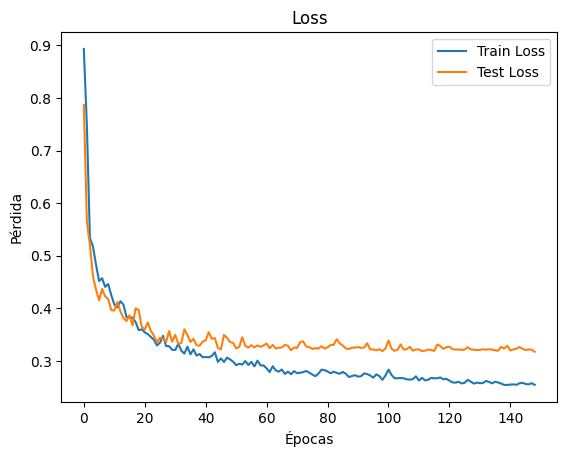

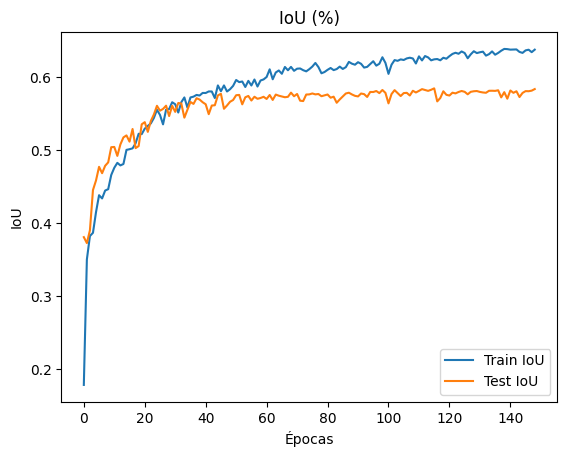

0.25451660756435657
0.3174954056739807
0.6371870114013819
0.5832211491373116


In [ ]:
#HACER UN LOADING STATE ANTES PARA CARGAR EL ENTRENAMIENTO
x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'-',y,test_loss_vec,'-')
plt.title("Loss")
plt.legend(['Train Loss', 'Test Loss'])
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.show()

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'-',y,test_error_vec, '-')
plt.title("IoU (%)")
plt.xlabel("Épocas")
plt.ylabel("IoU")
plt.legend(['Train IoU', 'Test IoU'],loc = "lower right")
plt.show()

print(train_loss_vec[-1])
print(test_loss_vec[-1])
print(train_error_vec[-1])
print(test_error_vec[-1])

# save_error=False
# now = datetime.now() # current date and time
# date_time = now.strftime("%mm%dd%Yy%Hh%Mm%Ss")

# x=[x for x in range(len(train_loss_vec))]
# y=[y for y in range(len(test_loss_vec))]
# plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
# plt.legend(['train','test'])
# plt.title("Loss")

# if save_error:
#     # plt.savefig('./results/checkpoints/loss_prueba'+date_time+'.png',format='png',transparent=True)
#     plt.savefig('./results/checkpoints/loss_prueba'+date_time+'.pdf',format='pdf',transparent=True)

# plt.show()

# x=[x for x in range(len(train_error_vec))]
# y=[y for y in range(len(test_error_vec))]
# plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
# plt.legend(['train','test'])
# plt.title("IoU")


# if save_error:
#     # plt.savefig('./results/checkpoints/error_prueba'+date_time+'.png',format='png',transparent=True)
#     plt.savefig('./results/checkpoints/error_prueba'+date_time+'.pdf',format='pdf',transparent=True)

# plt.show()

# **Segmentación con MVSEC**

# TEST Loop

## Connecting to Google

In [2]:
from google.colab import drive
drive.mount('/content/drive/')
import sys
sys.path.append('/content/drive/MyDrive')
%cd /content/drive/MyDrive/StereoSpike

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
/content/drive/MyDrive/StereoSpike


##Installing libraries

In [8]:
!pip install -r requirements.txt

  Using cached loris-0.5.3.tar.gz (8.9 MB)
  Preparing metadata (setup.py) ... done
  Using cached ninja-1.11.1.4-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.0 kB)
  Using cached aedat-2.2.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (7.0 kB)
Using cached ninja-1.11.1.4-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (422 kB)
Using cached aedat-2.2.0-cp311-cp311-manylinux_2_28_x86_64.whl (498 kB)
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for loris
  Running setup.py clean for loris
Failed to build loris
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (loris)


In [7]:
!pip install spikingjelly

  Using cached spikingjelly-0.0.0.0.14-py3-none-any.whl.metadata (15 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.3.1.170-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nvjitlink_cu12-12.4.127-py3-no

## Libraries importing

In [1]:
import time
import random
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
#import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "0"
import torch
import torch.nn as nn
#import torch.nn.functional as F
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter

In [11]:
import datasets.data_augmentation

ModuleNotFoundError: No module named 'datasets.data_augmentation'

In [10]:
import time
import random
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
#import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "0"
import torch
import torch.nn as nn
#import torch.nn.functional as F
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter
from spikingjelly.clock_driven import functional
from spikingjelly.clock_driven import surrogate
# from spikingjelly.event_driven import neuron
from datasets.data_augmentation import ToTensor_mono,ToTensor_ms, RandomHorizontalFlip_ms, RandomVerticalFlip_ms, RandomTimeMirror, RandomEventDrop_ms
#from network.SNN_models2 import unetRNN6Layer_noBlock
from network.SNN_models import StereoSpike, \
                    fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike, \
                    fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike, \
                    fromZero_feedforward_multiscale_tempo_monocular_Motion, \
                    fromZero_feedforward_multiscale_tempo_monocular_Motion2, \
                    unetMotion#, Unet
# from network.SNN_models2 import unetMotion3, unetMotion4
from OF_EV_SNN.network_3d.poolingNet_cat_1res import NeuronPool_Separable_Pool3d_2, \
                    PLIFNeuronPool_Separable_Pool3d, \
                    PLIFNeuronPool_Separable_Pool3d_2, \
                    NeuronPool_Separable_Pool3d, \
                    NeuronPool_Separable_Pool3d_2, \
                    PLIFNeuronPool_Separable_Pool3d_ts, \
                    NeuronPool_Separable_Pool3d_3x3,  \
                    poolingnet3d_i, \
                    poolingnet3d_lif

from network.ANN_models import StereoSpike_equivalentANN
#from network.metrics import MeanDepthError, log_to_lin_depths, disparity_to_depth
from network.Params import yamlParams
#from datasets.MVSEC import mvsec_dataset2 as evimo_base
from network.loss2 import Total_Loss_Motion, DiceLoss, BCEDiceLoss, getIOU
from datasets.MVSEC.mvsec_dataset import MVSECDatasetBase, EVIMODatasetBase, EVIMODatasetBaseNPZ, EVIMODatasetBase_serg
from datasets.MVSEC.mvsec_dataset import RPGDVSDatasetBase
#from network.SNN_models2 import unetRNN6Layer_noBlock

from torch.utils.data.dataloader import default_collate
from viz import show_learning, show_loss
from PIL import Image
import os
#from network.loss import getIOU, MSE
#from datasets.MVSEC import load_MVSEC
########################
# COMPLEMENT FUNCTIONS #
########################

def my_collate(batch):
    batch = list(filter (lambda x:x is not None, batch))
    if not batch:
        return None

    return default_collate(batch)

##############################
# DEVICE AND REPRODUCIBILITY #
##############################

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

logfile = open("./results/checkpoints/test_results_dani.txt", "w+")
###########################
# VISUALIZATION FUNCTIONS #
###########################

plt.ion()
fig = plt.figure()


ModuleNotFoundError: No module named 'datasets.data_augmentation'

## Database params

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 1.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"

# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01/img"
# datafile1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01.hdf5"

# maskDir_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

# maskDir_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
# maskDir_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
# datafile_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"

#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

output_dir = "/content/drive/MyDrive/StereoSpike/logs/" # os.path.join(os.getcwd(), 'logs')

general_config = "/content/drive/MyDrive/StereoSpikeA/general_config_Dani.yaml"
genconfigs = yamlParams(general_config)


In [ ]:
########################
## TRAINING FRAMEWORK ##
########################
# Create the network
from OF_EV_SNN.network_3d.poolingNet_cat_1res import  poolingnet3d, PLIFNeuronPool_Separable_Pool3d #PLIFNeuronPool_Separable_Pool3d_state,

# net = PLIFNeuronPool_Separable_Pool3d_state(multiply_factor = 1.).to(device)
net = poolingnet3d_lif(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)

# net = PLIFNeuronPool_Separable_Pool3d(multiply_factor = 1.).to(device) #ts 21

# net = poolingnet3d(multiply_factor = 1.).to(device) #ts 21
# net = NeuronPool_Separable_Pool3d_3x3(multiply_factor = 10.).to(device)

trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print('Trainable parameters: {}'.format(trainable_params))


# Initialize network weights

for m in net.modules():
    if isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)

learning_rate = 2e-3
weight_decay = 0.0
learned_metric = 'LIN'
# Create the optimizer
lr = 5e-4
wd = 1e-3
optimizer = torch.optim.AdamW(net.parameters(), lr = lr, weight_decay = wd)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [10, 20, 40], gamma = 0.5)

loss_module = BCEDiceLoss()
bcediceloss_module = BCEDiceLoss()

## Dataset wall

In [ ]:
#from datasets.data_augmentation import ToTensor,ToTensor_mono, RandomHorizontalFlip, RandomVerticalFlip, RandomTimeMirror, RandomEventDrop
from datasets.MVSEC.mvsec_dataset import EVIMODatasetBase3

maskDir_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00/img"
datafile_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00.hdf5"
# maskDir_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03/img"
# datafile_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03.hdf5"

maskDir_test1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01/img"
datafile_test1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01.hdf5"
# maskDir_train1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05/img"
# datafile_train1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05.hdf5"

# maskDir_test2 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile_test2 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"

# maskDir_test3 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test3 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"

general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# general_config = "/content/drive/MyDrive/StereoSpike/general_config.yaml"
genconfigs = yamlParams(general_config)

print("data_motion")
tsfm = transforms.Compose([
    #TEVIMOoTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test = EVIMODatasetBase(datafile_test, genconfigs, maskDir_test, crop,
                                maxBackgroundRatio, incrementalPercent,tsfm)
    # database_train = EVIMODatasetBase(datafile_train, genconfigs, maskDir_train, crop,
    #                             maxBackgroundRatio, incrementalPercent,tsfm)
    database_test1 = EVIMODatasetBase(datafile_test1, genconfigs, maskDir_test1, crop,
                                maxBackgroundRatio, incrementalPercent,tsfm)
    # database_test2 = EVIMODatasetBase(datafile_test2, genconfigs, maskDir_test, crop,
    #                             maxBackgroundRatio, incrementalPercent,tsfm)
    # database_test3 = EVIMODatasetBase(datafile_test3, genconfigs, maskDir_test, crop,
                                # maxBackgroundRatio, incrementalPercent,tsfm)
    # database_train1 = EVIMODatasetBase(datafile_train1, genconfigs, maskDir_train1, crop,
                                # maxBackgroundRatio, incrementalPercent,tsfm)
    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")

# dataset_size = len(database)
# dataset_size1 = len(database1)
    # uncomment if you want to split test/train using single hdf5 file
# torch.manual_seed(0)
test_split = genconfigs['model']['testSplit'] # self.genconfigs['model']['testSplit']                      #

# test_size = int(test_split * dataset_size)                              #
# train_size = dataset_size - test_size                                   #
# train_dataset, test_dataset = torch.utils.data.random_split(database,[train_size, test_size])    #

# test_size = int(test_split * dataset_size)                              #
# test_size1 = int(test_split * dataset_size1)                              #

# train_size = dataset_size - test_size
# train_size1 = dataset_size1 - test_size1                                #

# train_dataset, test_dataset = torch.utils.data.random_split(database,[train_size, test_size])    #
# train_dataset1, test_dataset1 = torch.utils.data.random_split(database1,[train_size1, test_size1])    #

# train_dev_sets = torch.utils.data.ConcatDataset([database_train, database_train1])
test_dev_sets = torch.utils.data.ConcatDataset([database_test, database_test1])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=test_dev_sets,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

# train_loader = torch.utils.data.DataLoader(
#         dataset=train_dev_sets,
#         batch_size=batch_size,
#         shuffle=True,
#         num_workers=num_workers,
#         pin_memory=True,
#         collate_fn=my_collate,
#         drop_last=False)


#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

data_motion
EVIMO tot length 1593
EVIMO_dataset
EVIMO tot length 1401
EVIMO_dataset
EVIMO used


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## Dataset box

In [ ]:
#from datasets.data_augmentation import ToTensor,ToTensor_mono, RandomHorizontalFlip, RandomVerticalFlip, RandomTimeMirror, RandomEventDrop
from datasets.MVSEC.mvsec_dataset import EVIMODatasetBase3

maskDir_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_00/img"
datafile_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_00.hdf5"
# maskDir_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03/img"
# datafile_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03.hdf5"

maskDir_test1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01/img"
datafile_test1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01.hdf5"
# maskDir_train1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05/img"
# datafile_train1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05.hdf5"

maskDir_test2 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02/img"
datafile_test2 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02.hdf5"

maskDir_test3 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_03/img"
datafile_test3 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_03.hdf5"

maskDir_test4 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_04/img"
datafile_test4 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_04.hdf5"

maskDir_test5 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_05/img"
datafile_test5 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_05.hdf5"

general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# general_config = "/content/drive/MyDrive/StereoSpike/general_config.yaml"
genconfigs = yamlParams(general_config)

print("data_motion")
tsfm = transforms.Compose([
    #TEVIMOoTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test = EVIMODatasetBase(datafile_test, genconfigs, maskDir_test, crop,
                                maxBackgroundRatio, incrementalPercent,tsfm)
    # database_train = EVIMODatasetBase(datafile_train, genconfigs, maskDir_train, crop,
    #                             maxBackgroundRatio, incrementalPercent,tsfm)
    database_test1 = EVIMODatasetBase(datafile_test1, genconfigs, maskDir_test1, crop,
                                maxBackgroundRatio, incrementalPercent,tsfm)
    database_test2 = EVIMODatasetBase(datafile_test2, genconfigs, maskDir_test2, crop,
                                maxBackgroundRatio, incrementalPercent,tsfm)
    database_test3 = EVIMODatasetBase(datafile_test3, genconfigs, maskDir_test3, crop,
                                maxBackgroundRatio, incrementalPercent,tsfm)
    database_test4 = EVIMODatasetBase(datafile_test4, genconfigs, maskDir_test4, crop,
                                maxBackgroundRatio, incrementalPercent,tsfm)
    database_test5 = EVIMODatasetBase(datafile_test5, genconfigs, maskDir_test5, crop,
                                maxBackgroundRatio, incrementalPercent,tsfm)
    # database_test2 = EVIMODatasetBase(datafile_test2, genconfigs, maskDir_test, crop,
    #                             maxBackgroundRatio, incrementalPercent,tsfm)
    # database_test3 = EVIMODatasetBase(datafile_test3, genconfigs, maskDir_test, crop,
                                # maxBackgroundRatio, incrementalPercent,tsfm)
    # database_train1 = EVIMODatasetBase(datafile_train1, genconfigs, maskDir_train1, crop,
                                # maxBackgroundRatio, incrementalPercent,tsfm)
    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")

# dataset_size = len(database)
# dataset_size1 = len(database1)
    # uncomment if you want to split test/train using single hdf5 file
# torch.manual_seed(0)
test_split = genconfigs['model']['testSplit'] # self.genconfigs['model']['testSplit']                      #

# test_size = int(test_split * dataset_size)                              #
# train_size = dataset_size - test_size                                   #
# train_dataset, test_dataset = torch.utils.data.random_split(database,[train_size, test_size])    #

# test_size = int(test_split * dataset_size)                              #
# test_size1 = int(test_split * dataset_size1)                              #

# train_size = dataset_size - test_size
# train_size1 = dataset_size1 - test_size1                                #

# train_dataset, test_dataset = torch.utils.data.random_split(database,[train_size, test_size])    #
# train_dataset1, test_dataset1 = torch.utils.data.random_split(database1,[train_size1, test_size1])    #

# train_dev_sets = torch.utils.data.ConcatDataset([database_train, database_train1])
test_dev_sets = torch.utils.data.ConcatDataset([database_test, database_test1, database_test2, database_test3, database_test4, database_test5])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=test_dev_sets,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

# train_loader = torch.utils.data.DataLoader(
#         dataset=train_dev_sets,
#         batch_size=batch_size,
#         shuffle=True,
#         num_workers=num_workers,
#         pin_memory=True,
#         collate_fn=my_collate,
#         drop_last=False)


#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

data_motion
EVIMO tot length 40
EVIMO_dataset
EVIMO tot length 124
EVIMO_dataset
EVIMO tot length 128
EVIMO_dataset
EVIMO tot length 196
EVIMO_dataset
EVIMO tot length 252
EVIMO_dataset
EVIMO tot length 538
EVIMO_dataset
EVIMO used


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## Dataset floor

In [ ]:
#from datasets.data_augmentation import ToTensor,ToTensor_mono, RandomHorizontalFlip, RandomVerticalFlip, RandomTimeMirror, RandomEventDrop
from datasets.MVSEC.mvsec_dataset import EVIMODatasetBase3

maskDir_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_00/img"
datafile_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_00.hdf5"
# maskDir_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03/img"
# datafile_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03.hdf5"

maskDir_test1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_01/img"
datafile_test1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_01.hdf5"
# maskDir_train1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05/img"
# datafile_train1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05.hdf5"

# maskDir_test2 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02/img"
# datafile_test2 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02.hdf5"

# maskDir_test3 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_03/img"
# datafile_test3 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_03.hdf5"

# maskDir_test4 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_04/img"
# datafile_test4 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_04.hdf5"

# maskDir_test5 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_05/img"
# datafile_test5 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_05.hdf5"

general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# general_config = "/content/drive/MyDrive/StereoSpike/general_config.yaml"
genconfigs = yamlParams(general_config)

print("data_motion")
tsfm = transforms.Compose([
    #TEVIMOoTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test = EVIMODatasetBase(datafile_test, genconfigs, maskDir_test, crop,
                                maxBackgroundRatio, incrementalPercent,tsfm)
    # database_test = EVIMODatasetBase_serg(datafile_test, 21, 1, genconfigs, maskDir_test,  crop,
    #         maxBackgroundRatio, incrementalPercent, tsfm)
    # database_train = EVIMODatasetBase(datafile_train, genconfigs, maskDir_train, crop,
    #                             maxBackgroundRatio, incrementalPercent,tsfm)
    database_test1 = EVIMODatasetBase(datafile_test1, genconfigs, maskDir_test1, crop,
                                maxBackgroundRatio, incrementalPercent,tsfm)
    # database_test1 = EVIMODatasetBase_serg(datafile_test, 21, 1, genconfigs, maskDir_test,  crop,
    #         maxBackgroundRatio, incrementalPercent, tsfm)
    # database_test2 = EVIMODatasetBase(datafile_test2, genconfigs, maskDir_test2, crop,
    #                             maxBackgroundRatio, incrementalPercent,tsfm)
    # database_test3 = EVIMODatasetBase(datafile_test3, genconfigs, maskDir_test3, crop,
    #                             maxBackgroundRatio, incrementalPercent,tsfm)
    # database_test4 = EVIMODatasetBase(datafile_test4, genconfigs, maskDir_test4, crop,
    #                             maxBackgroundRatio, incrementalPercent,tsfm)
    # database_test5 = EVIMODatasetBase(datafile_test5, genconfigs, maskDir_test5, crop,
    #                             maxBackgroundRatio, incrementalPercent,tsfm)
    # database_test2 = EVIMODatasetBase(datafile_test2, genconfigs, maskDir_test, crop,
    #                             maxBackgroundRatio, incrementalPercent,tsfm)
    # database_test3 = EVIMODatasetBase(datafile_test3, genconfigs, maskDir_test, crop,
                                # maxBackgroundRatio, incrementalPercent,tsfm)
    # database_train1 = EVIMODatasetBase(datafile_train1, genconfigs, maskDir_train1, crop,
                                # maxBackgroundRatio, incrementalPercent,tsfm)
    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")

# dataset_size = len(database)
# dataset_size1 = len(database1)
    # uncomment if you want to split test/train using single hdf5 file
# torch.manual_seed(0)
test_split = genconfigs['model']['testSplit'] # self.genconfigs['model']['testSplit']                      #

# test_size = int(test_split * dataset_size)                              #
# train_size = dataset_size - test_size                                   #
# train_dataset, test_dataset = torch.utils.data.random_split(database,[train_size, test_size])    #

# test_size = int(test_split * dataset_size)                              #
# test_size1 = int(test_split * dataset_size1)                              #

# train_size = dataset_size - test_size
# train_size1 = dataset_size1 - test_size1                                #

# train_dataset, test_dataset = torch.utils.data.random_split(database,[train_size, test_size])    #
# train_dataset1, test_dataset1 = torch.utils.data.random_split(database1,[train_size1, test_size1])    #

# train_dev_sets = torch.utils.data.ConcatDataset([database_train, database_train1])
test_dev_sets = torch.utils.data.ConcatDataset([database_test, database_test1])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=test_dev_sets,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

# train_loader = torch.utils.data.DataLoader(
#         dataset=train_dev_sets,
#         batch_size=batch_size,
#         shuffle=True,
#         num_workers=num_workers,
#         pin_memory=True,
#         collate_fn=my_collate,
#         drop_last=False)


#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

## Dataset wall only test NO MASKS

In [ ]:
#from datasets.data_augmentation import ToTensor,ToTensor_mono, RandomHorizontalFlip, RandomVerticalFlip, RandomTimeMirror, RandomEventDrop
from datasets.MVSEC.mvsec_dataset import EVIMODatasetBase3, EVIMODatasetBasetTest

maskDir_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00/img"
datafile_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00.hdf5"
# maskDir_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03/img"
# datafile_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03.hdf5"

maskDir_test1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01/img"
datafile_test1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01.hdf5"
# maskDir_train1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05/img"
# datafile_train1 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05.hdf5"

# maskDir_test2 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile_test2 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"

# maskDir_test3 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test3 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"

general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# general_config = "/content/drive/MyDrive/StereoSpike/general_config.yaml"
genconfigs = yamlParams(general_config)

print("data_motion")
tsfm = transforms.Compose([
    #TEVIMOoTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test = EVIMODatasetBasetTest(datafile_test, genconfigs, maskDir_test, crop,
                                maxBackgroundRatio, incrementalPercent,tsfm)
    # database_train = EVIMODatasetBase(datafile_train, genconfigs, maskDir_train, crop,
    #                             maxBackgroundRatio, incrementalPercent,tsfm)
    database_test1 = EVIMODatasetBasetTest(datafile_test1, genconfigs, maskDir_test1, crop,
                                maxBackgroundRatio, incrementalPercent,tsfm)
    # database_test2 = EVIMODatasetBase(datafile_test2, genconfigs, maskDir_test, crop,
    #                             maxBackgroundRatio, incrementalPercent,tsfm)
    # database_test3 = EVIMODatasetBase(datafile_test3, genconfigs, maskDir_test, crop,
                                # maxBackgroundRatio, incrementalPercent,tsfm)
    # database_train1 = EVIMODatasetBase(datafile_train1, genconfigs, maskDir_train1, crop,
                                # maxBackgroundRatio, incrementalPercent,tsfm)
    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")

# dataset_size = len(database)
# dataset_size1 = len(database1)
    # uncomment if you want to split test/train using single hdf5 file
# torch.manual_seed(0)
test_split = genconfigs['model']['testSplit'] # self.genconfigs['model']['testSplit']                      #

# test_size = int(test_split * dataset_size)                              #
# train_size = dataset_size - test_size                                   #
# train_dataset, test_dataset = torch.utils.data.random_split(database,[train_size, test_size])    #

# test_size = int(test_split * dataset_size)                              #
# test_size1 = int(test_split * dataset_size1)                              #

# train_size = dataset_size - test_size
# train_size1 = dataset_size1 - test_size1                                #

# train_dataset, test_dataset = torch.utils.data.random_split(database,[train_size, test_size])    #
# train_dataset1, test_dataset1 = torch.utils.data.random_split(database1,[train_size1, test_size1])    #

# train_dev_sets = torch.utils.data.ConcatDataset([database_train, database_train1])
test_dev_sets = torch.utils.data.ConcatDataset([database_test, database_test1])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=test_dev_sets,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

# train_loader = torch.utils.data.DataLoader(
#         dataset=train_dev_sets,
#         batch_size=batch_size,
#         shuffle=True,
#         num_workers=num_workers,
#         pin_memory=True,
#         collate_fn=my_collate,
#         drop_last=False)


#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

data_motion
EVIMO tot length 1593
EVIMO_dataset
EVIMO tot length 1401
EVIMO_dataset
EVIMO used


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## Dataset EVIMO

In [ ]:
general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
genconfigs = yamlParams(general_config)

### Multiple dataset loader TABLE completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "table"

num_workers = 4 #genconfigs['hardware']['readerThreads']
batch_size = 1 #genconfigs['batchsize']

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 3.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

num_seq = 0
eval == 1

if eval == 1:
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_0" + str(num_seq) + ".hdf5"
else:
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_0" + str(num_seq) + ".hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""
ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database =  EVIMODatasetBase_serg(datafileDir, 10, 1, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)
    # database_train_00 = EVIMODatasetBase(datafile, 10, 1, genconfigs, maskDir_train_00, crop,
                                # maxBackgroundRatio, incrementalPercent)


    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")


# database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
# database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])


# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

# train_loader = torch.utils.data.DataLoader(
#         dataset=database_train,
#         batch_size=batch_size,
#         shuffle=False,
#         num_workers=num_workers,
#         pin_memory=True,
#         collate_fn=my_collate,
#         drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (80585721, 4), type "<f8">
<HDF5 dataset "events_idx": shape (2429,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (2428, 3), type "<f8">
EVIMO tot length 2427
EVIMO table used

    MODEL
    ------------------------------
    poolingnet3d_lif
    DATA
    ------------------------------
    nfpdm = 1
    N_train = 1
    test_set = 2427
    learned_metric = LIN
    data_augmentation = Compose(
    RandomHorizontalFlip_ms(p=0.5)
    RandomVerticalFlip_ms(p=0.5)
    RandomEventDrop_ms(p=0.5, min_drop_rate=0.0, max_drop_rate=0.4)
)
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = 1
    lr = 0.0002
    wd = 0.0
    


### Multiple dataset loader TABLE completo 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "table"

num_workers = 4 #genconfigs['hardware']['readerThreads']
batch_size = 1 #genconfigs['batchsize']

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 3 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)


maskDir_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""
# ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataser loader FAST completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "fast"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02.hdf5"



#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader WALL completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "wall"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 1.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_01.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01.hdf5"

#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = False
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')


# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)


    print("EVIMO wall used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

# train_loader = torch.utils.data.DataLoader(
#         dataset=database_train,
#         batch_size=batch_size,
#         shuffle=True,
#         num_workers=num_workers,
#         pin_memory=True,
#         collate_fn=my_collate,
#         drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO tot length 1593
MVSEC_dataset1
EVIMO tot length 1784
MVSEC_dataset1
EVIMO tot length 1401
MVSEC_dataset1
EVIMO tot length 1957
MVSEC_dataset1
EVIMO wall used

    MODEL
    ------------------------------
    PLIFNeuronPool_Separable_Pool3d
    DATA
    ------------------------------
    nfpdm = 1
    N_train = 1
    training_set = 1871
    test_set = 1497
    learned_metric = LIN
    data_augmentation = Compose(
    RandomHorizontalFlip_ms(p=0.5)
    RandomVerticalFlip_ms(p=0.5)
    RandomEventDrop_ms(p=0.5, min_drop_rate=0.0, max_drop_rate=0.4)
)
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = 2
    lr = 0.002
    wd = 0.0
    


### Multiple dataset loader WALL completo 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "fast"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/train/fast/txt/seq_05.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/fast/txt/seq_02.hdf5"



#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader FLOOR completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "floor"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  10, 1, genconfigs, maskDir_test_00,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop, maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop, maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader FLOOR completo 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "floor"
# ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"

# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)

# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_00/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_00.hdf5" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_01/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/floor/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_01.hdf5" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/floor/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_02/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_02.hdf5" #"/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_00/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02.hdf5"
# maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03/img"
# datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03.hdf5"
# maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04/img"
# datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04.hdf5"
# maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05/img"
# datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_00/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_00.hdf5" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_01/img" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_01.hdf5" #"/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt/seq_01.hdf5"
# maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_00,  10, 1, genconfigs, maskDir_test_00,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase_serg(datafile_train_01, 10, 1, genconfigs, maskDir_train_00, crop, maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase_serg(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase_serg(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop, maxBackgroundRatio, incrementalPercent)

    # database_test_02 =  EVIMODatasetBase_serg(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase_serg(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop, maxBackgroundRatio, incrementalPercent)

    # database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    # database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
    #                             maxBackgroundRatio, incrementalPercent)

    # database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    # database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
    #                             maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO_dataset:  /content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (900347, 4), type "<f8">
<HDF5 dataset "events_idx": shape (263,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (262, 3), type "<f8">
EVIMO tot length 261
EVIMO_dataset:  /content/drive/MyDrive/datasets/EVIMO_Dataset2/train/floor/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (3906982, 4), type "<f8">
<HDF5 dataset "events_idx": shape (1612,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (1611, 3), type "<f8">
EVIMO tot length 1610
EVIMO_dataset:  /content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/floor/txt/seq_01/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (365755, 4), ty

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


### Multiple dataset loader BOX completo 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "box"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05.hdf5"
maskDir_train_06 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_06/img"
datafile_train_06 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_06.hdf5"
maskDir_train_07 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_07/img"
datafile_train_07 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_07.hdf5"
maskDir_train_08 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_08/img"
datafile_train_08 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_08.hdf5"
maskDir_train_09 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_09/img"
datafile_train_09 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_09.hdf5"
maskDir_train_10 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_10/img"
datafile_train_10 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_10.hdf5"
maskDir_train_11 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_11/img"
datafile_train_11 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_11.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_03.hdf5"
maskDir_test_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_04/img"
datafile_test_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_04.hdf5"
maskDir_test_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_05/img"
datafile_test_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_05.hdf5"


# maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_01, 10, 1, genconfigs, maskDir_test_01,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_02, 10, 1, genconfigs, maskDir_test_02,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_04, 10, 1, genconfigs, maskDir_test_04,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_05, 10, 1, genconfigs, maskDir_test_05,  crop,
            maxBackgroundRatio, incrementalPercent)

    database_train_00 = EVIMODatasetBase_serg(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase_serg(datafile_test_01, 10, 1,   genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase_serg(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase_serg(datafile_test_02, 10, 1,   genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase_serg(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase_serg(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase_serg(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase_serg(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_04 = EVIMODatasetBase_serg(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_05 = EVIMODatasetBase_serg(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase_serg(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    # for box dataset
    # database_test_06 =  EVIMODatasetBase(datafile_test_06,  genconfigs, maskDir_test_06,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_06 = EVIMODatasetBase_serg(datafile_train_06, 10, 1,  genconfigs, maskDir_train_06, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_07 =  EVIMODatasetBase(datafile_test_07,  genconfigs, maskDir_test_07,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_07 = EVIMODatasetBase_serg(datafile_train_07, 10, 1,  genconfigs, maskDir_train_07, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_08 =  EVIMODatasetBase(datafile_test_08,  genconfigs, maskDir_test_08,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_08 = EVIMODatasetBase_serg(datafile_train_08, 10, 1,  genconfigs, maskDir_train_08, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_09 =  EVIMODatasetBase(datafile_test_09,  genconfigs, maskDir_test_09,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_09 = EVIMODatasetBase_serg(datafile_train_09, 10, 1,  genconfigs, maskDir_train_09, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_10 = EVIMODatasetBase(datafile_train_10, genconfigs, maskDir_train_10, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_10 = EVIMODatasetBase_serg(datafile_train_10, 10, 1,  genconfigs, maskDir_train_10, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_11 = EVIMODatasetBase(datafile_train_11, genconfigs, maskDir_train_11, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_11 = EVIMODatasetBase_serg(datafile_train_11, 10, 1,  genconfigs, maskDir_train_11, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}##
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

### Multiple dataset loader BOX completo 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "box"
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lifnode"


##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_05.hdf5"
maskDir_train_06 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_06/img"
datafile_train_06 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_06.hdf5"
maskDir_train_07 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_07/img"
datafile_train_07 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_07.hdf5"
maskDir_train_08 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_08/img"
datafile_train_08 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_08.hdf5"
maskDir_train_09 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_09/img"
datafile_train_09 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_09.hdf5"
maskDir_train_10 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_10/img"
datafile_train_10 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_10.hdf5"
maskDir_train_11 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_11/img"
datafile_train_11 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/train/box/txt/seq_11.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_03.hdf5"
maskDir_test_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_04/img"
datafile_test_04 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_04.hdf5"
maskDir_test_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_05/img"
datafile_test_05 = "/content/drive/MyDrive/datasets/EVIMO_Dataset2/eval/box/txt/seq_05.hdf5"


# maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_01, 10, 1, genconfigs, maskDir_test_01,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_02, 10, 1, genconfigs, maskDir_test_02,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_04, 10, 1, genconfigs, maskDir_test_04,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_05, 10, 1, genconfigs, maskDir_test_05,  crop,
            maxBackgroundRatio, incrementalPercent)

    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,   genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,   genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    # for box dataset
    # database_test_06 =  EVIMODatasetBase(datafile_test_06,  genconfigs, maskDir_test_06,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_06 = EVIMODatasetBase(datafile_train_06, 10, 1,  genconfigs, maskDir_train_06, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_07 =  EVIMODatasetBase(datafile_test_07,  genconfigs, maskDir_test_07,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_07 = EVIMODatasetBase(datafile_train_07, 10, 1,  genconfigs, maskDir_train_07, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_08 =  EVIMODatasetBase(datafile_test_08,  genconfigs, maskDir_test_08,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_08 = EVIMODatasetBase(datafile_train_08, 10, 1,  genconfigs, maskDir_train_08, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_09 =  EVIMODatasetBase(datafile_test_09,  genconfigs, maskDir_test_09,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_09 = EVIMODatasetBase(datafile_train_09, 10, 1,  genconfigs, maskDir_train_09, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_10 = EVIMODatasetBase(datafile_train_10, genconfigs, maskDir_train_10, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_10 = EVIMODatasetBase(datafile_train_10, 10, 1,  genconfigs, maskDir_train_10, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_11 = EVIMODatasetBase(datafile_train_11, genconfigs, maskDir_train_11, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_11 = EVIMODatasetBase(datafile_train_11, 10, 1,  genconfigs, maskDir_train_11, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}

        '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)


# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

In [ ]:
try:
  print(epoch_load)
except:
  epoch_load = 0

print(epoch_load)

print(train_loss_vec[-1])
print(test_loss_vec[-1])
print(train_error_vec[-1])
print(test_error_vec[-1])

# train_loss_vec = []
# train_error_vec = []
# test_loss_vec = []
# test_error_vec = []

total_MSE = 0
total_IOU = 0
scalar_i = 0
tot_frames = 0

0


NameError: name 'train_loss_vec' is not defined

## Dataset MVSEC secuencia individual

In [ ]:
general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
genconfigs = yamlParams(general_config)

name_seq = "outdoor_day" # "indoor_flying"
num_seq = 1
ms_seq = 10 # 10 o 1
eval_data = 1

prediction_root = "/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/data/" + name_seq + "_modificated/" + name_seq + str(num_seq) + "_" + str(ms_seq) + "ms_predictions/"
print(prediction_root)

# BOX Completas 00, 01, 02, 03, 04, 05
# FLOOR Completas 01
# TABLE Completas 00, 01, 02, 03
# WALL Completas 00, 01


/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/data/outdoor_day_modificated/outdoor_day1_10ms_predictions/


### Dataset loader indoor_flying individual 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "table"

num_workers = 4 #genconfigs['hardware']['readerThreads']
batch_size = 1 #genconfigs['batchsize']

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 3.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"

# num_seq = 0
# eval == 1

if name_seq == "indoor_flying":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/data/" + name_seq + "modificated/" + name_seq + str(num_seq) + "_" + str(ms_seq)
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/data/" + name_seq + "modificated/" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/data/" + name_seq + "_modificated/" + name_seq + str(num_seq) + "_" + str(ms_seq) + "ms.hdf5"
else:
  print("No coincidde el nombre del dataset, se quiere cargar el " + name_seq + "pero este es " + dataset_name )

print(datafileDir)


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""
ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

No coincidde el nombre del dataset, se quiere cargar el outdoor_daypero este es table


NameError: name 'datafileDir' is not defined

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database =  MVSECDatasetBase(datafileDir, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)
    # database =  EVIMODatasetBase(datafileDir, genconfigs, maskDir, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    # database =  EVIMODatasetBase_serg(datafileDir, 10, 1, genconfigs, maskDir, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    # database_train_00 = EVIMODatasetBase(datafile, 10, 1, genconfigs, maskDir_train_00, crop,
                                # maxBackgroundRatio, incrementalPercent)


    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)


#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion


NameError: name 'datafileDir' is not defined

### Dataset loader outdoor_day individual 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "table"

num_workers = 4 #genconfigs['hardware']['readerThreads']
batch_size = 1 #genconfigs['batchsize']

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 3.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"

# num_seq = 0
# eval == 1

if name_seq == "outdoor_day":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/data/" + name_seq + "modificated/" + name_seq + str(num_seq) + "_" + str(ms_seq)
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/data/" + name_seq + "modificated/" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/data/" + name_seq + "_modificated/" + name_seq + str(num_seq) + "_" + str(ms_seq) + "ms.hdf5"
else:
  print("No coincidde el nombre del dataset, se quiere cargar el " + name_seq + "pero este es " + dataset_name )

print(datafileDir)


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""
ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/data/outdoor_day_modificated/outdoor_day1_10ms.hdf5


In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database =  MVSECDatasetBase(datafileDir, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)
    # database =  EVIMODatasetBase(datafileDir, genconfigs, maskDir, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    # database =  EVIMODatasetBase_serg(datafileDir, 10, 1, genconfigs, maskDir, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    # database_train_00 = EVIMODatasetBase(datafile, 10, 1, genconfigs, maskDir_train_00, crop,
                                # maxBackgroundRatio, incrementalPercent)


    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)


#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO tot length 11935
MVSEC_dataset
EVIMO table used

    MODEL
    ------------------------------
    poolingnet3d_lif
    DATA
    ------------------------------
    nfpdm = 1
    N_train = 1
    test_set = 11935
    learned_metric = LIN
    data_augmentation = Compose(
    RandomHorizontalFlip_ms(p=0.5)
    RandomVerticalFlip_ms(p=0.5)
    RandomEventDrop_ms(p=0.5, min_drop_rate=0.0, max_drop_rate=0.4)
)
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = 1
    lr = 0.002
    wd = 0.0
    


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


### Dataset loader indoor_flying individual 1 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "table"

num_workers = 4 #genconfigs['hardware']['readerThreads']
batch_size = 1 #genconfigs['batchsize']

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 3 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"

ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)


if name_seq == "indoor_flying":
  maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img"
  img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + "/img_synchronized"
  datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset2/eval/" + name_seq + "/txt/seq_0" + str(num_seq) + ".hdf5"
else:
  print("No coincidde el nombre del dataset, se quiere cargar el " + name_seq + "pero este es " + dataset_name )


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""
# ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])

if(datasetType == "EVIMO"):
    database =  EVIMODatasetBase(datafileDir, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)
    # database =  EVIMODatasetBase_serg(datafileDir, 10, 1, genconfigs, maskDir, crop,
    #                             maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")


# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)


#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
              #  len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               lr,
               wd)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

## Dataset RPG DVS secuencia individual

In [ ]:
general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
genconfigs = yamlParams(general_config)

# dynamic_6dof, dynamic_rotation, urban, office_spiral, offiral_zigzag, outdoors_running, outdoors_walking

name_seq = "dynamic_6dof"
ms_seq = 1 # 10 o 1

prediction_root = "/content/drive/MyDrive/StereoSpikeA/datasets/RPG DVS/" + name_seq + "/" + name_seq + "_" + str(ms_seq) + "ms_predictions/"
print(prediction_root)

# BOX Completas 00, 01, 02, 03, 04, 05
# FLOOR Completas 01
# TABLE Completas 00, 01, 02, 03
# WALL Completas 00, 01


/content/drive/MyDrive/StereoSpikeA/datasets/RPG DVS/dynamic_6dof/dynamic_6dof_1ms_predictions/


### Dataset loader RPG DVS individual 10 ms

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion


num_workers = 4 #genconfigs['hardware']['readerThreads']
batch_size = 1 #genconfigs['batchsize']

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 3.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"

# num_seq = 0
# eval == 1

maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/data/" + name_seq + "modificated/" + name_seq +  "_" + str(ms_seq)
img_synchronizedDir = "/content/drive/MyDrive/StereoSpikeA/datasets/RPG DVS/" + name_seq + "/" + "/img_synchronized"
datafileDir = "/content/drive/MyDrive/StereoSpikeA/datasets/RPG DVS/" + name_seq + "/" + name_seq + "_" + str(ms_seq) + "ms.hdf5"

# print("No coincidde el nombre del dataset, se quiere cargar el " + name_seq + "pero este es " + dataset_name )

print(datafileDir)


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""
# ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

# general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
# genconfigs = yamlParams(general_config)


/content/drive/MyDrive/StereoSpikeA/datasets/RPG DVS/dynamic_6dof/dynamic_6dof_1ms.hdf5


In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database =  RPGDVSDatasetBase(datafileDir, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)
    # database =  EVIMODatasetBase(datafileDir, genconfigs, maskDir, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    # database =  EVIMODatasetBase_serg(datafileDir, 10, 1, genconfigs, maskDir, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    # database_train_00 = EVIMODatasetBase(datafile, 10, 1, genconfigs, maskDir_train_00, crop,
                                # maxBackgroundRatio, incrementalPercent)


    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)


#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



data_motion


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-18-dab019eb6509>", line 13, in <cell line: 12>
    database =  RPGDVSDatasetBase(datafileDir, genconfigs, maskDir, crop,
  File "/content/drive/MyDrive/StereoSpike/datasets/MVSEC/mvsec_dataset.py", line 627, in __init__
    self.data = h5py.File(datafile, 'r')
  File "/usr/local/lib/python3.10/dist-packages/h5py/_hl/files.py", line 562, in __init__
    fid = make_fid(name, mode, userblock_size, fapl, fcpl, swmr=swmr)
  File "/usr/local/lib/python3.10/dist-packages/h5py/_hl/files.py", line 235, in make_fid
    fid = h5f.open(name, flags, fapl=fapl)
  File "h5py/_objects.pyx", line 54, in h5py._objects.with_phil.wrapper
  File "h5py/_objects.pyx", line 55, in h5py._objects.with_phil.wrapper
  File "h5py/h5f.pyx", line 102, in h5py.h5f.open
FileNotFoundError: [Errno 2] Unabl

## Load State to ./results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lr_5_3_super.pth

In [ ]:
########################
## TRAINING FRAMEWORK ##
########################
# Create the network

neuron_type = "lif"

# net = NeuronPool_Separable_Pool3d_depth_segm(multiply_factor = 10.).to(device) #ts 20
# net = NeuronPool_Separable_Pool3d_3x3(multiply_factor = 10.).to(device)
# net = NeuronPool_Separable_Pool3d_original(multiply_factor = 10.,time_window = 21).to(device) #ts 21
# net = SpikeMS_poolingnet(multiply_factor = 10., time_window = 10).to(device)
# net = poolingnet3d(multiply_factor = 2., time_window = 10).to(device)
# net = poolingnet3d_lif(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)
net = PLIFNeuronPool_Separable_Pool3d(multiply_factor = 1.).to(device) #ts 20 // para ./results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lr_5_3_super.pth
# net = NeuronPool_Separable_Pool3d_3x3(multiply_factor = 10.).to(device)

# if neuron_type == "lif":
#     net = poolingnet3d_lif(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)
# elif neuron_type == "izhikevich":
#     net = poolingnet3d_i(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)

trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print('Trainable parameters: {}'.format(trainable_params))


# Initialize network weights

for m in net.modules():
    if isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)


# Create the optimizer
lr = 5e-4
wd = 1e-3
optimizer = torch.optim.AdamW(net.parameters(), lr = lr, weight_decay = wd)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [10, 20, 40, 80, 160, 320], gamma = 0.5)

USING SPIKING MODEL
Trainable parameters: 1069226


In [ ]:
# checkpoint = torch.load("./results/checkpoints/poolingnet_seg_lif3x3_max5_batch1.pth")
# checkpoint = torch.load('./results/checkpoints/stereospike_seg_sergio4.pth')
# checkpoint = torch.load("./results/checkpoints/poolingnet_seg_lif3x3_max1_5_batch1.pth")
checkpoint = torch.load("./results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lr_5_3_super.pth")
train_loss_vec = checkpoint['train_loss_vec_dict']
test_loss_vec = checkpoint['test_loss_vec_dict']
train_error_vec = checkpoint['train_error_vec_dict']
test_error_vec = checkpoint['test_error_vec_dict']
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch_load = checkpoint['epoch']
epoch_test_loss = checkpoint['loss']
# net.update_max_accuracy(epoch_test_loss)

NameError: name 'torch' is not defined

## Load State to ./results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lab_part2_no_final.pth

In [ ]:
########################
## TRAINING FRAMEWORK ##
########################
# Create the network

neuron_type = "lif"

general_config = "/content/drive/MyDrive/StereoSpike/general_config_Dani.yaml"
genconfigs = yamlParams(general_config)

# net = NeuronPool_Separable_Pool3d_depth_segm(multiply_factor = 10.).to(device) #ts 20
# net = NeuronPool_Separable_Pool3d_3x3(multiply_factor = 10.).to(device)
# net = NeuronPool_Separable_Pool3d_original(multiply_factor = 10.,time_window = 21).to(device) #ts 21
# net = SpikeMS_poolingnet(multiply_factor = 10., time_window = 10).to(device)
# net = poolingnet3d(multiply_factor = 2., time_window = 10).to(device)
# net = poolingnet3d_lif(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)

# net = PLIFNeuronPool_Separable_Pool3d(multiply_factor = 1.).to(device) #ts 20 // para ./results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lr_5_3_super.pth

# net = NeuronPool_Separable_Pool3d_3x3(multiply_factor = 10.).to(device)

# if neuron_type == "lif":
#     net = poolingnet3d_lif(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)
# elif neuron_type == "izhikevich":
#     net = poolingnet3d_i(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)

net = PLIFNeuronPool_Separable_Pool3d(multiply_factor = 1.).to(device) #ts 21

trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print('Trainable parameters: {}'.format(trainable_params))


# Initialize network weights

for m in net.modules():
    if isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)


# Create the optimizer
lr = 5e-4
wd = 1e-3
optimizer = torch.optim.AdamW(net.parameters(), lr = lr, weight_decay = wd)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [10, 20, 40, 80, 160, 320], gamma = 0.5)

USING SPIKING MODEL
Trainable parameters: 1069226


In [ ]:
# checkpoint = torch.load("/content/drive/MyDrive/StereoSpikeA/results/checkpoints/PLIFNeuronPool_Separable_Pool3d_wall_max1_5_batch1_lr_5_3_super.pth")
# checkpoint = torch.load("/content/drive/MyDrive/StereoSpike/results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lab_part2_no_final.pth")
# checkpoint = torch.load("/content/drive/MyDrive/StereoSpike/results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lab_part2_no_final_continuacion.pth")
checkpoint = torch.load("/content/drive/MyDrive/StereoSpike/results/checkpoints/best_poolingnet_seg_lif3x3_wall_max1_5_batch1_lab_part2_no_final_continuacion2_01-21-2025-11h15m15s.pth")
# checkpoint = torch.load("./results/checkpoints/poolingnet_seg_lif3x3_max5_batch1.pth")
# checkpoint = torch.load('./results/checkpoints/stereospike_seg_sergio4.pth')
# checkpoint = torch.load("./results/checkpoints/poolingnet_seg_lif3x3_max1_5_batch1.pth")
# checkpoint = torch.load("./results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lr_5_3_super.pth")      # Este es el mejorcito pero a seguir viendo
train_loss_vec = checkpoint['train_loss_vec_dict']
test_loss_vec = checkpoint['test_loss_vec_dict']
train_error_vec = checkpoint['train_error_vec_dict']
test_error_vec = checkpoint['test_error_vec_dict']
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch_load = checkpoint['epoch']
# epoch_test_loss = checkpoint['loss']
# net.update_max_accuracy(epoch_test_loss)

<ipython-input-9-8225331d316d>:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("/content/drive/MyDrive/StereoSpike/results/checkpoints/best_poolingn

In [ ]:
checkpoint = {'epoch': epoch_load,
                                'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
                                'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                                'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec}

checkpoint_path = "./results/checkpoints/checkpoint_mejor_lab_part2.pth"
torch.save(checkpoint, checkpoint_path)

In [ ]:
print(train_loss_vec[-1])
print(test_loss_vec[-1])
print(train_error_vec[-1])
print(test_error_vec[-1])

0.3167625175779348
0.36347697580114324
0.5680937786949181
0.5481828896667594


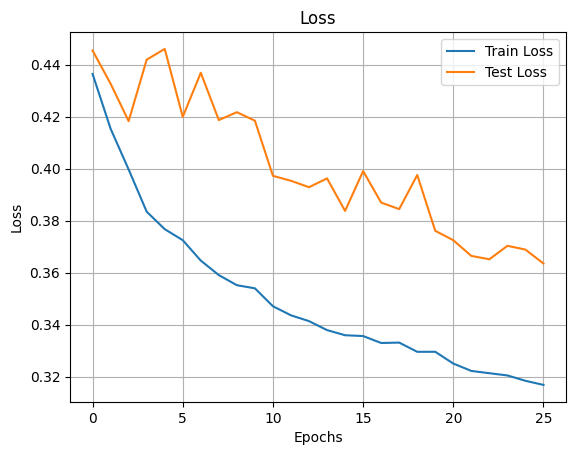

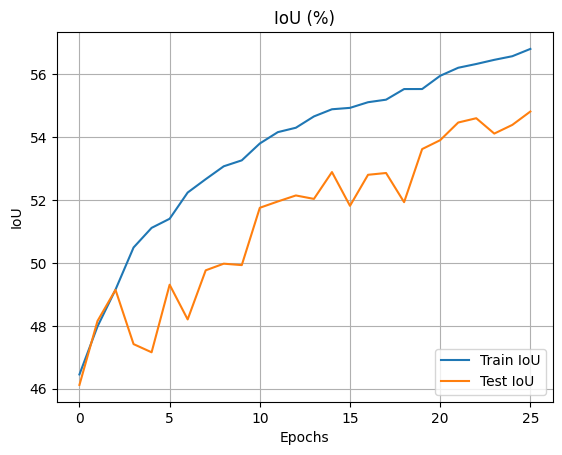

In [ ]:
x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'-',y,test_loss_vec,'-')
plt.title("Loss")
plt.legend(['Train Loss', 'Test Loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

train_error_new_valors = [x *100 for x in train_error_vec]
test_error_new_valors = [x *100 for x in test_error_vec]

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
# plt.plot(x,train_error_vec,'-',y,test_error_vec, '-')
plt.plot(x,train_error_new_valors,'-',y,test_error_new_valors, '-')
plt.title("IoU (%)")
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.legend(['Train IoU', 'Test IoU'],loc = "lower right")
plt.grid(True)
plt.show()

## Load state

In [ ]:
# # print("./results/checkpoints/"+ckpt_file+"_lr0.0005_mbgr6"+".pth")
# # checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_'+dataset_name+'_lifnode.pth')
# # checkpoint = torch.load("./results/checkpoints/"+ckpt_file+"_lr0.0005_mbgr6"+".pth")
# checkpoint = torch.load("./results/checkpoints/best_poolingnet3d_seg_lif_orgnl_wall_lr0.0004_mbgr9_10-11-2023-22h23m26s.pth")

# train_loss_vec = checkpoint['train_loss_vec_dict']
# test_loss_vec = checkpoint['test_loss_vec_dict']
# train_error_vec = checkpoint['train_error_vec_dict']
# test_error_vec = checkpoint['test_error_vec_dict']
# net.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# running_train_loss = checkpoint['running_train_loss']
# running_train_IOU = checkpoint['running_train_IOU']
# running_test_loss = checkpoint['running_test_loss']
# running_test_IOU = checkpoint['running_test_IOU']
# epoch = checkpoint['epoch']
# # epoch_test_loss = checkpoint['loss']
# # net.update_max_accuracy(epoch_test_loss)
# ckpt_train_i = checkpoint['ckpt_idx_train']
# ckpt_test_i = checkpoint['ckpt_idx_test']

In [ ]:
# ckpt_file = "poolingnet3d_seg_lif_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
ckpt_file = "best_poolingnet3d_lif_neuronlif_orgnl_mixed_train_ta00fa00wa00wa01flo01box00_lr0.0001_mbgr4_wd0.001time_win10ms_0_12-19-2024-19h39m48s"
print(ckpt_file)
checkpoint_path = "./results/checkpoints/"+ckpt_file+".pth"
checkpoint = torch.load(checkpoint_path)

best_poolingnet3d_lif_neuronlif_orgnl_mixed_train_ta00fa00wa00wa01flo01box00_lr0.0001_mbgr4_wd0.001time_win10ms_0_12-19-2024-19h39m48s


<ipython-input-9-4bc07906494c>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


In [ ]:
train_loss_vec = checkpoint['train_loss_vec_dict']
test_loss_vec = checkpoint['test_loss_vec_dict']
train_error_vec = checkpoint['train_error_vec_dict']
test_error_vec = checkpoint['test_error_vec_dict']
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
running_train_loss = checkpoint['running_train_loss']
running_train_IOU = checkpoint['running_train_IOU']
running_test_loss = checkpoint['running_test_loss']
running_test_IOU = checkpoint['running_test_IOU']
test_epoch_summary = checkpoint['test_epoch_summary']
train_epoch_summary = checkpoint['train_epoch_summary']
epoch_train_loss = checkpoint['epoch_train_loss']
epoch_test_loss = checkpoint['epoch_test_loss']
epoch = checkpoint['epoch']
# net.update_max_accuracy(epoch_test_loss)
ckpt_train_i = checkpoint['ckpt_idx_train']
ckpt_test_i = checkpoint['ckpt_idx_test']
train_done = checkpoint['train_done']
test_done = checkpoint['test_done']
train_i=0
test_i=0

In [ ]:
len(train_loss_vec)

17

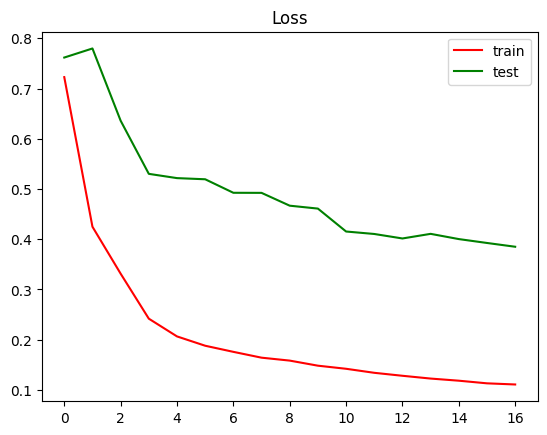

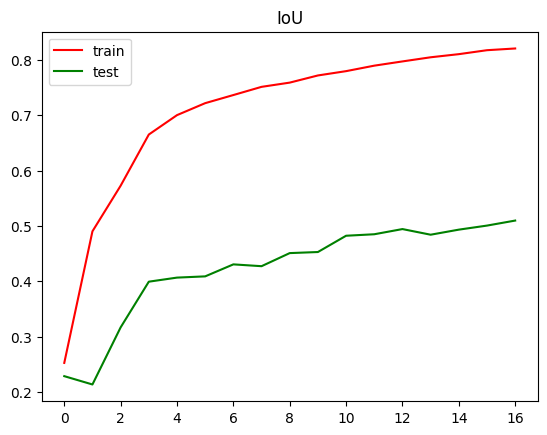

In [ ]:
from datetime import datetime

save_error=False
now = datetime.now() # current date and time
date_time = now.strftime("%mm%dd%Yy%Hh%Mm%Ss")

x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
plt.legend(['train','test'])
plt.title("Loss")

if save_error:
    # plt.savefig('./results/checkpoints/loss_prueba'+date_time+'.png',format='png',transparent=True)
    plt.savefig('./results/checkpoints/loss_prueba'+date_time+'.pdf',format='pdf',transparent=True)

plt.show()

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
plt.legend(['train','test'])
plt.title("IoU")


if save_error:
    # plt.savefig('./results/checkpoints/error_prueba'+date_time+'.png',format='png',transparent=True)
    plt.savefig('./results/checkpoints/error_prueba'+date_time+'.pdf',format='pdf',transparent=True)

plt.show()

## Viene del "no sé, train 3" (sección de arriba) pero modificado solo para test

In [ ]:
# checkpoint = {'epoch': epoch,
#             'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
#             'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
#             'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
#             'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
#             'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
#             'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
#             'train_done': train_done,'test_done': test_done,
#             'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
#             'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }

ckpt_train_i = 0
ckpt_test_i = 0
test_done = False

import sys
try:
    from spikingjelly.activation_based import neuron, layer, surrogate
    from torch._C import dtype
    MultiStep=False
    from viz import show_learning

    # ckpt_file = "poolingnet3d_seg_SEW3D"+dataset_name+"_lifnode"

    functional.reset_net(net)
    if int(ckpt_train_i) >10:
        print("resuming training of "+dataset_name+" in epoch "+str(epoch)+" from chkpnt: train_i: "+str(int(ckpt_train_i))+", loss: "+str(running_train_loss)+", IOU: "+str(running_train_IOU))
    train_i=0
    test_i=0

    n_epochs = 1

    for epoch in range(n_epochs):
        # show=False
        # net = net.train()                                                   #<--------   0
        # start_time = time.time()

        # here must arrive when train_done = 2

    #################   TEST LOOP ##################
        if int(ckpt_test_i) >10: print("resuming testing in epoch "+str(epoch)+ "from checkpoint: test_i: "+str(ckpt_test_i)+", test_loss: "+str(running_test_loss)+", test_IOU: "+str(running_test_IOU))

        net.eval()
        show=True

        with torch.no_grad():
            start_time = time.time()
            if int(test_i) >10: print("resuming testing from i: "+str(int(test_i)))

            for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
                if test_done == True:
                    break
                if (data == None):
                    continue
                test_i += 1
                if ckpt_test_i > test_i:
                    continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

                functional.reset_net(net)
                optimizer.zero_grad()
                spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
                spikes_masked = data['masked_spike_tensor']
                # ckpt_idx_test = data['file_number']
                spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
                spikes_masked = spikes_masked.permute(0,1,4,2,3)

                print(i)
                print(data['file_number'])

                # if MultiStep:   #sums all time steps in the dim=0
                #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
                spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
                # us = nn.Upsample(scale_factor = 0.6937, mode='trilinear')
                # spikes_input = us(spikes_input)
                spikes_masked = spikes_masked.to(device)
                # spikes_masked = us(spikes_masked)
                # spikes_input.requires_grad_()
                spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
                spike_pred =  spike_pred_list[0].to(device)             # (1,1,260,346)
                # spike_pred = torch.sigmoid(spike_pred)

                if spike_pred.ndim == 4:
                    spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                    spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                    #spike_pred_4D = spike_pred
                    spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

                elif spike_pred.ndim == 5:
                    spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
                    # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                    spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

                spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
                # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
                spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
                # spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
                # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
                # spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

                # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
                # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

                if show:
                    spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                    spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                    #condition to colapse all timesteps in every batch for monitoring only
                    spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                    spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                    # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                    # print("spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                    # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                    # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                    # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                    # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                    for e in range(spike_pred.size(0)): #iterates the batches dim=0
                        for i in range(spike_pred.size(2)): #iterates the time dim=2
                            show_learning(fig,False,
                                    spikes_input[None,None,e,:,i,:,:],
                                    spike_pred_4D[:,None,i,:,:],
                                    spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

                loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)
                # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

                running_test_loss += loss.item()# / spikes_input.size(0)
                spike_pred_4D = torch.round(spike_pred_4D)
                running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

                # if i == (len(test_loader)-1):
                #     print("Testing loop finished")
                #     test_done = 1
                # print(len(test_loader))
                # print(i)
                # if int(test_i) % 100 <= 0: #condition to save intermediate trainings
                #     checkpoint = {'epoch': epoch,
                #                 'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
                #                 'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                #                 'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                #                 'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                #                 'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                #                 'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                #                 'train_done': train_done,'test_done': test_done,
                #                 'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                #                 'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                #     print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+" for "+dataset_name)
                #     torch.save(checkpoint, checkpoint_path)
                #     ckpt_test_i = test_i

            # if test_done == False:
            #     epoch_test_loss = running_test_loss / test_i #len(test_loader)
            #     epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
            #     print("\n test i: ",test_i)
            #     print("len test loader: ", len(test_loader))
            #     test_loss_vec.append(float(epoch_test_loss))
            #     test_error_vec.append(float(epoch_test_IOU))
            #     epoch_test_time = time.time() - start_time
            #     test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
            #     print(str(train_epoch_summary) + str(test_epoch_summary))

            #     net.increment_epoch()
            #     scheduler.step()

                # print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+" for "+dataset_name)
                # checkpoint = {'epoch': epoch,
                #             'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
                #             'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                #             'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                #             'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                #             'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                #             'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                #             'train_done': train_done,'test_done': test_done,
                #             'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                #             'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                # print("Test finished, saving...")
                # torch.save(checkpoint, checkpoint_path)
                # print("The size of the integer variable is:",sys.getsizeof(checkpoint), "bytes.")

                now = datetime.now() # current date and time
                date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
                print("Performance saved: saving model...\n")

                # torch.save(checkpoint, checkpoint_path)
                # print("The size of the integer variable is:",sys.getsizeof(checkpoint), "bytes.")

                # if epoch_test_loss < net.get_max_accuracy():
                #     print("Best performances so far: saving model...\n")
                #     # logfile.write("Best performances so far: saving model...\n")
                #     net.update_max_accuracy(epoch_test_loss)
                #     #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
                #     torch.save(checkpoint, "./results/checkpoints/best_"+ckpt_file+"_"+date_time+".pth")
                test_done = True
            else:
                print("Skipping testing loop...")

    ################# Training/testing plots
            x=[x for x in range(len(train_loss_vec))]
            y=[y for y in range(len(test_loss_vec))]
            plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
            plt.legend(['train','test'])
            plt.title("Loss")

            save_loss=False
            if save_loss: plt.savefig('./results/checkpoints/loss_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
            plt.show()

            x=[x for x in range(len(train_error_vec))]
            y=[y for y in range(len(test_error_vec))]
            plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
            plt.legend(['train','test'])
            plt.title("IoU (%)")

            save_error=False
            if save_error: plt.savefig('./results/checkpoints/error_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
            plt.show()

        # train_i = 0
        # test_i = 0
        # ckpt_train_i = 0
        # ckpt_test_i = 0
        # test_done = False
        # train_done = False

        # running_train_loss = 0
        # running_train_IOU = 0
        # running_test_loss = 0
        # running_test_IOU = 0
        # test_epoch_summary = 0
        # train_epoch_summary = 0
        # print("training epoch " +str(epoch)+" finished !")

    print("training finished !")
except KeyboardInterrupt:
    print("saving training before exit....keyboardinterrupt")
#     ckpt_train_i = train_i
#     ckpt_test_i = test_i
    # checkpoint = {'epoch': epoch,
    #         'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
    #         'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
    #         'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
    #         'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
    #         'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
    #         'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
    #         'train_done': train_done,'test_done': test_done,
    #         'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
    #         'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
    # torch.save(checkpoint, checkpoint_path)
#     torch.save(checkpoint, "./results/checkpoints/"+ckpt_file+".pth")

except OSError:
    print("saving training before exit.... oserror")

else:
     print("saving training before exit....")

  v_threshold=1.0, v_reset=0.0, detach_reset=True
  (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
), which is not spikingjelly.activation_based.base.MemoryModule
  v_threshold=1.0, v_reset=0.0, detach_reset=True
  (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
), which is not spikingjelly.activation_based.base.MemoryModule
testing:   0%|          | 0/2994 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
testing:   1%|          | 22/2994 [00:41<21:06,  2.35it/s]WARNING:root:Trying to call `reset()` of IFNode(
  v_threshold=1.0, v_reset=0.0, detach_reset=True
  (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
), which is not spikingjelly.activation_based.base.MemoryModule
  v_threshold=1.0, v_reset=0.0, detach_reset=True
  (surrogate_function): Sigmoid(alpha=4.0, spikin

22
tensor([22])


testing:   1%|          | 22/2994 [00:43<1:37:27,  1.97s/it]


RuntimeError: Calculated padded input size per channel: (2 x 134 x 177). Kernel size: (5 x 5 x 5). Kernel size can't be greater than actual input size

## Para poolingnet3d_lif

In [ ]:
import json
from datetime import datetime
# # print("./results/checkpoints/"+ckpt_file+"5.pth")
# ckpt_file = "poolingnet3d_seg_lif_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)


# checkpoint_path = "./results/checkpoints/"+ckpt_file+".pth"
# # # checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_'+dataset_name+'_lifnode.pth')
# # checkpoint = torch.load("./results/checkpoints/"+ckpt_file+"5.pth")
# checkpoint = torch.load(checkpoint_path)
# print("Starting training: "+checkpoint)
import sys
try:
    from spikingjelly.activation_based import neuron, layer, surrogate
    from torch._C import dtype
    MultiStep=False
    from viz import show_learning

    # ckpt_file = "poolingnet3d_seg_SEW3D"+dataset_name+"_lifnode"

    functional.reset_net(net)
    # if int(ckpt_train_i) >10:
    #     print("resuming training of "+dataset_name+" in epoch "+str(net.epoch)+" from chkpnt: train_i: "+str(int(ckpt_train_i))+", loss: "+str(running_train_loss)+", IOU: "+str(running_train_IOU))
    train_i=0
    test_i=0

    test_done = False

    n_epochs = 1

    for epoch in range(n_epochs):
        print("Scheduler's parameters: \n")
        print(json.dumps(scheduler.state_dict(), indent=4))
        show=True

    #################   TEST LOOP ##################
        # if int(ckpt_test_i) >10:
        #     print("resuming testing in epoch "+str(net.epoch)+ "from checkpoint: test_i: "+str(ckpt_test_i)+", test_loss: "+str(running_test_loss)+", test_IOU: "+str(running_test_IOU))

        net.eval()
        show=True

        with torch.no_grad():
            start_time = time.time()
            if int(test_i) >10: print("resuming testing from sequence: "+str(int(test_i)))

            for i, data in enumerate(tqdm(test_loader, desc='testing')):                #loader --> train_loader
                if test_done == True:
                    break
                if (data == None):
                    continue
                test_i += 1
                # if ckpt_test_i > test_i:
                #     continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

                functional.reset_net(net)
                optimizer.zero_grad()
                spikes_input = data['spike_tensor']                                     #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
                spikes_masked = data['masked_spike_tensor']
                # ckpt_idx_test = data['file_number']
                spikes_input = spikes_input.permute(0,1,4,2,3)                          #   torch.Size([8, 2, 21, 260, 346])
                spikes_masked = spikes_masked.permute(0,1,4,2,3)
                # if MultiStep:   #sums all time steps in the dim=0
                #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
                spikes_input = spikes_input.to(device)                                  #   torch.Size([B,C,T,260, 346])
                # us = nn.Upsample(scale_factor = 0.6937, mode='trilinear')
                # spikes_input = us(spikes_input)
                spikes_masked = spikes_masked.to(device)
                # spikes_masked = us(spikes_masked)
                # spikes_input.requires_grad_()
                spike_pred_list =  net(spikes_input)                                    # len(spike_pred_list) = 4
                spike_pred =  spike_pred_list[0].to(device)                             # (1,1,260,346)
                # spike_pred = torch.sigmoid(spike_pred)

                if spike_pred.ndim == 4:
                    spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                    spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                    #spike_pred_4D = spike_pred
                    spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True)      #

                elif spike_pred.ndim == 5:
                    spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
                    # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                    spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

                spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False)    #or and remove of B dim

                spike_mask_4D = torch.mul(spike_mask_4D,1.)                             #conversion from bool to numbers

                if show:
                    spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                    spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                    #condition to colapse all timesteps in every batch for monitoring only
                    spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)   #  (B,C,T,H,W)-->(B,C,1,H,W)
                    spike_input_5D = spike_input_5D.permute(0,2,1,3,4)                  #  (B,1,C,H,W)

                    for e in range(spike_pred.size(0)): #iterates the batches dim=0
                        for i in range(spike_pred.size(2)): #iterates the time dim=2
                            show_learning(fig,False,
                                    spikes_input[None,None,e,:,i,:,:],
                                    spike_pred_4D[:,None,i,:,:],
                                    spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

                loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)
                # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

                running_test_loss += loss.item()# / spikes_input.size(0)
                spike_pred_4D = torch.round(spike_pred_4D)
                running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

                if int(test_i) % 100 <= 0: #condition to save intermediate trainings
                    checkpoint = {'epoch': net.epoch,
                                'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(), 'scheduler_state_dict': scheduler.state_dict(),
                                'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                                'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                                'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                                'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                                'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                                'train_done': train_done,'test_done': test_done,
                                'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                                'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                    print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+" for "+dataset_name)
                    torch.save(checkpoint, checkpoint_path)
                    ckpt_test_i = test_i

            if test_done == False:
                epoch_test_loss = running_test_loss / test_i #len(test_loader)
                epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
                print("\n Procesed test sequences: ",test_i)
                print("len test loader: ", len(test_loader))
                test_loss_vec.append(float(epoch_test_loss))
                test_error_vec.append(float(epoch_test_IOU))
                epoch_test_time = time.time() - start_time
                test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(net.epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
                print(str(train_epoch_summary) + str(test_epoch_summary))

                net.increment_epoch()
                scheduler.step(epoch_test_loss)
                test_done = True

                # print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+" for "+dataset_name)
                checkpoint = {'epoch': net.epoch,
                            'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(), 'scheduler_state_dict': scheduler.state_dict(),
                            'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                            'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                            'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                            'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                            'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                            'train_done': train_done,'test_done': test_done,
                            'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                            'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                print("Test finished, saving...")
                torch.save(checkpoint, checkpoint_path)
                # print("The size of the integer variable is:",sys.getsizeof(checkpoint), "bytes.")

                now = datetime.now() # current date and time
                date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
                print("Performance saved: saving model...\n")

                torch.save(checkpoint, checkpoint_path)
                # print("The size of the integer variable is:",sys.getsizeof(checkpoint), "bytes.")

                if epoch_test_loss < net.get_max_accuracy():
                    print("Best performances so far: saving model...\n")
                    # logfile.write("Best performances so far: saving model...\n")
                    net.update_max_accuracy(epoch_test_loss)
                    #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
                    torch.save(checkpoint, "./results/checkpoints/best_epoch"+str(scheduler.last_epoch)+"_"+ckpt_file+"_"+date_time+".pth")

            else:
                print("Skipping testing loop")
                date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
    ################# Training/testing plots
            x=[x for x in range(len(train_loss_vec))]
            y=[y for y in range(len(test_loss_vec))]
            plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
            plt.legend(['train','test'])
            # plt.title("Loss of "+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience))

            save_loss=False
            # if save_loss: plt.savefig('./results/checkpoints/loss_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
            plt.show()

            x=[x for x in range(len(train_error_vec))]
            y=[y for y in range(len(test_error_vec))]
            plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
            plt.legend(['train','test'])
            # plt.title("IoU (%) of "+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience))

            save_error=False
            # if save_error: plt.savefig('./results/checkpoints/error_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
            plt.show()

        train_i = 0
        test_i = 0
        ckpt_train_i = 0
        ckpt_test_i = 0
        test_done = False
        train_done = False
        epoch += 1

        running_train_loss = 0
        running_train_IOU = 0
        running_test_loss = 0
        running_test_IOU = 0
        test_epoch_summary = 0
        train_epoch_summary = 0
        print("training epoch " +str(net.epoch)+" finished !")

    print("training finished !")
except KeyboardInterrupt:
    print("saving training before exit....keyboardinterrupt")

except OSError:
    print("saving training before exit.... oserror")


else:
     print("saving training before exit....")

Output hidden; open in https://colab.research.google.com to view.

## Test loop para ./results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lr_5_3_super.pth

In [ ]:
try:
  print(epoch_load)
except:
  epoch_load = 0

print(epoch_load)

print(train_loss_vec[-1])
print(test_loss_vec[-1])
print(train_error_vec[-1])
print(test_error_vec[-1])

# train_loss_vec = []
# train_error_vec = []
# test_loss_vec = []
# test_error_vec = []

total_MSE = 0
total_IOU = 0
scalar_i = 0
tot_frames = 0

25
25
0.3167625175779348
0.36347697580114324
0.5680937786949181
0.5481828896667594


testing:  14%|█▍        | 47/327 [00:10<00:51,  5.47it/s]

segm, batch 0


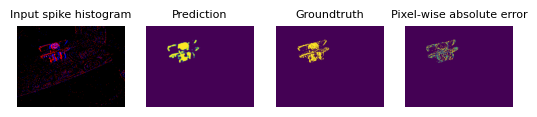

testing:  15%|█▍        | 49/327 [00:13<01:48,  2.56it/s]

segm, batch 0


<Figure size 640x480 with 0 Axes>

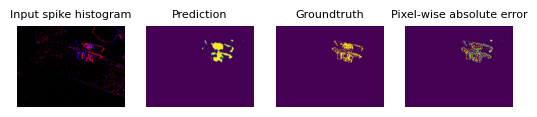

testing: 100%|██████████| 327/327 [00:58<00:00,  5.56it/s]



 test i:  2
len test loader:  327
Epoch: 0, Test Loss: 0.3360078036785126, Test IOU Error (m): 0.5170325047859854, Time: 1.024967074394226



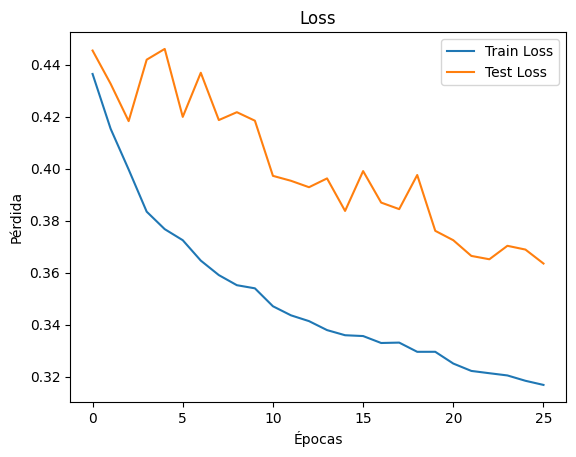

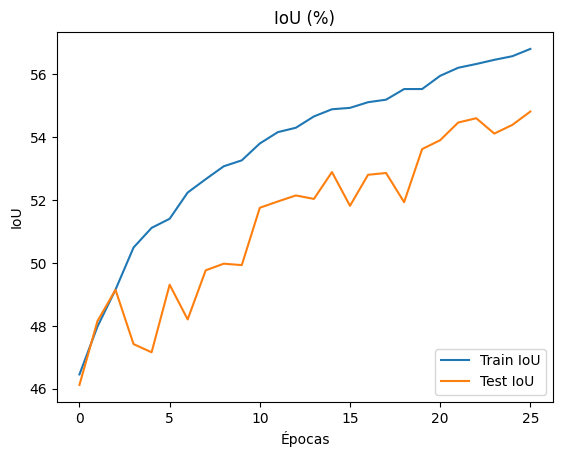

training finished !


In [ ]:
from spikingjelly.clock_driven import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning, show_learning_pred

functional.reset_net(net)
n_epochs = 300
test_i = 0

running_test_loss = 0
running_test_IOU = 0
process_events_time = 0
time_for_loop = 0

save = False #True #False

# print(prediction_root)

with torch.no_grad():
    start_time = time.time()
    show = True
    for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
        if (data == None):
            continue
        test_i += 1
        functional.reset_net(net)
        optimizer.zero_grad()
        spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
        spikes_masked = data['masked_spike_tensor']

        # print("Suma desde el while de: ", torch.sum(spikes_masked))

        if (torch.sum(spikes_input) < 1000 ):
            print(torch.sum(spikes_input))
            continue

        # print("spikes_input: ", spikes_input.shape)

        spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
        spikes_masked = spikes_masked.permute(0,1,4,2,3)

        spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
        spikes_masked = spikes_masked.to(device)
        spikes_input.requires_grad_()
        start_time_net = time.time()
        spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4

        # print("Test time: ", stop_time_net - start_time_net)

        # spike_pred =  spike_pred_list[2].to(device)             # (1,1,260,346)
        spike_pred =  spike_pred_list[2].to(device)             # (1,1,260,346)

        spike_pred = torch.sigmoid(spike_pred)

        stop_time_net = time.time()


        if test_i == 1:
          print(data['time_start'])
          print(data['time_per_index'])
          print(data['ratio'])
          spikes_input_test = spikes_input
          spike_pred_test = spike_pred

        # print(i)
        # print(data['file_number'])
        # print("time_start:")
        # print(data['time_start'])

        if spike_pred.ndim == 4:
            spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
            spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
            #spike_pred_4D = spike_pred
            spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

        elif spike_pred.ndim == 5:
            spike_pred_4D = torch.sum(spike_pred, axis = (2))           #torch.Size([B, 1, 260, 346])
            spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
            spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

        spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
        spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
        spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

        if show:
            #condition to colapse all timesteps in every batch
            spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
            spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
            for e in range(spike_input_5D.size(0)):
                # show_learning_pred(fig,save,
                #               spike_input_5D[None,e,:,:,:,:],
                #               spike_pred_4D[None,e,:,:,:],
                #               spike_mask_4D[None,e,:,:,:], prediction_root,'segm, batch '+str(e),i)
                show_learning(fig,False,
                              spike_input_5D[None,e,:,:,:,:],
                              spike_pred_4D[None,e,:,:,:],
                              spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)  #plt.fig,Save,[B,1,2,260,346],  [B, 1, 260, 346], [B, 1, 260, 346], text,       i
            #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

        if test_i == 48:
            #condition to colapse all timesteps in every batch
            spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
            spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
            for e in range(spike_input_5D.size(0)):
                # show_learning_pred(fig,save,
                #               spike_input_5D[None,e,:,:,:,:],
                #               spike_pred_4D[None,e,:,:,:],
                #               spike_mask_4D[None,e,:,:,:], prediction_root,'segm, batch '+str(e),i)
                show_learning(fig,False,
                              spike_input_5D[None,e,:,:,:,:],
                              spike_pred_4D[None,e,:,:,:],
                              spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)  #plt.fig,Save,[B,1,2,260,346],  [B, 1, 260, 346], [B, 1, 260, 346], text,       i

        loss = loss_module(spike_pred_4D, spike_mask_4D,weightbce=0.1)

        running_test_loss += loss / spikes_input.size(0)
        spike_pred = torch.round(spike_pred)
        running_test_IOU += getIOU(spike_pred, spike_mask_4D)
        process_events_time += data['ratio']
        time_for_loop += (stop_time_net - start_time_net)

            # process saved metrics
    if test_i != 0:
        epoch_test_loss = running_test_loss / test_i #len(test_loader)
        epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
        epoch_process_events_time = process_events_time / test_i
        print("\n test i: ",test_i)
        print("len test loader: ", len(test_loader))
        # test_loss_vec.append(float(epoch_test_loss))
        # test_error_vec.append(float(epoch_test_IOU))
        # test_error_vec.append(float(epoch_test_IOU[-1]))
        epoch_test_time = time_for_loop/test_i  #time.time() - start_time)
        test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(0, epoch_test_loss,epoch_test_IOU,epoch_test_time)
        print(test_epoch_summary)
        # logfile.write(test_epoch_summary)

    # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
    # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)

    # net.increment_epoch()
    # scheduler.step()
    # # Training/testing plots
    #HACER UN LOADING STATE ANTES PARA CARGAR EL ENTRENAMIENTO
    x=[x for x in range(len(train_loss_vec))]
    y=[y for y in range(len(test_loss_vec))]
    plt.plot(x,train_loss_vec,'-',y,test_loss_vec,'-')
    plt.title("Loss")
    plt.legend(['Train Loss', 'Test Loss'])
    plt.xlabel("Épocas")
    plt.ylabel("Pérdida")
    plt.show()

    train_error_new_valors = [x *100 for x in train_error_vec]
    test_error_new_valors = [x *100 for x in test_error_vec]

    x=[x for x in range(len(train_error_vec))]
    y=[y for y in range(len(test_error_vec))]
    # plt.plot(x,train_error_vec,'-',y,test_error_vec, '-')
    plt.plot(x,train_error_new_valors,'-',y,test_error_new_valors, '-')
    plt.title("IoU (%)")
    plt.xlabel("Épocas")
    plt.ylabel("IoU")
    plt.legend(['Train IoU', 'Test IoU'],loc = "lower right")
    plt.show()

    # x=[x for x in range(len(train_loss_vec))]
    # y=[y for y in range(len(test_loss_vec))]
    # plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
    # plt.title("Loss")
    # plt.xlabel("Épocas")
    # plt.ylabel("Pérdida")
    # plt.show()

    # x=[x for x in range(len(train_error_vec))]
    # y=[y*100 for y in range(len(test_error_vec))]
    # plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
    # plt.title("IoU (%)")
    # plt.xlabel("Épocas")
    # plt.ylabel("IOU")
    # plt.show()
print("training finished !")
# print(prediction_root)    0.5691719351940798  0.5649503764575486 0.5689795601932024 0.5700167209086086

In [ ]:
!nvidia-smi -L

NotImplementedError: A UTF-8 locale is required. Got ANSI_X3.4-1968

In [ ]:
print(process_events_time)
print(epoch_process_events_time)
print(stop_time_net)
print(start_time_net)
print(epoch_test_time)
print(test_i)
# print(data['time_per_index'])

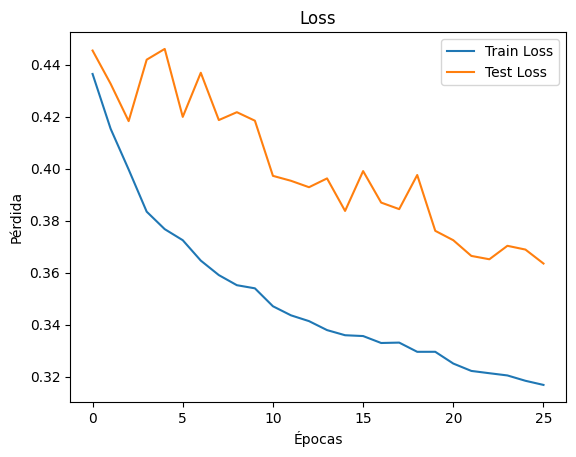

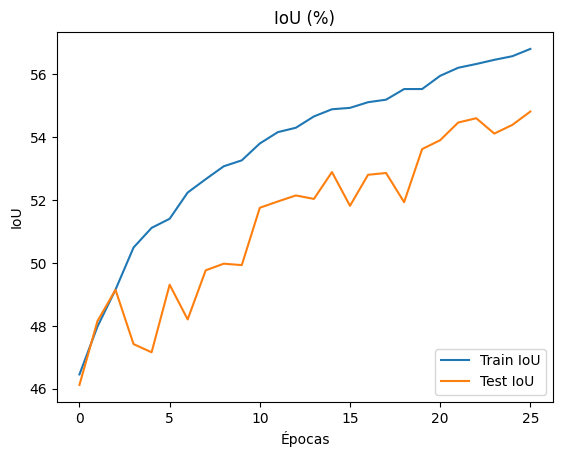

In [ ]:
#HACER UN LOADING STATE ANTES PARA CARGAR EL ENTRENAMIENTO
x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'-',y,test_loss_vec,'-')
plt.title("Loss")
plt.legend(['Train Loss', 'Test Loss'])
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.show()

train_error_new_valors = [x *100 for x in train_error_vec]
test_error_new_valors = [x *100 for x in test_error_vec]

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
# plt.plot(x,train_error_vec,'-',y,test_error_vec, '-')
plt.plot(x,train_error_new_valors,'-',y,test_error_new_valors, '-')
plt.title("IoU (%)")
plt.xlabel("Épocas")
plt.ylabel("IoU")
plt.legend(['Train IoU', 'Test IoU'],loc = "lower right")
plt.show()

In [ ]:
test_i

228

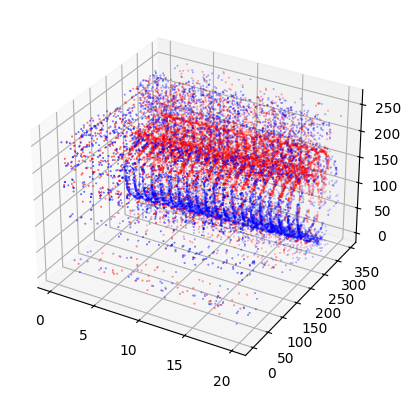

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# fig, ax = plt.subplots()

# spikes_input
ax = plt.axes(projection='3d')


for i in range(21):
  imgs = spikes_input_test[0,0,i,:,:].detach().cpu().numpy() #torch.rand(10,3,128,128)

  xdata,ydata = imgs.nonzero()

  # ax.scatter3D(xdata, ydata, i, c=xdata, cmap='Greens');
  ax.scatter3D(i, ydata, xdata, s=0.1, color='blue');

for i in range(20):
  imgs = spikes_input_test[0,1,i,:,:].detach().cpu().numpy() #torch.rand(10,3,128,128)

  xdata,ydata = imgs.nonzero()

  # ax.scatter3D(xdata, ydata, i, c=xdata, cmap='Greens');
  ax.scatter3D(i, ydata, xdata, s=0.1, color='red');

  # ax.view_init(elev=0, azim=0, roll=0)

  # imgs = spikes_input[0,0,1,:,:].detach().cpu().numpy() #torch.rand(10,3,128,128)

  # ax.scatter3D(xdata, ydata, 1, c=xdata, cmap='Greens');
# ax1.set_title("Default")

<class 'torch.Tensor'>
torch.Size([2, 21, 112, 112])


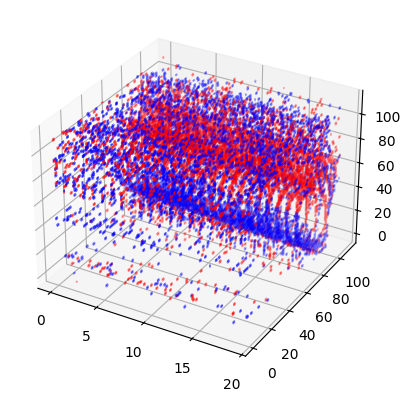

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from torchvision import transforms as trans

# fig, ax = plt.subplots()

test_transform2 = trans.Compose([
            trans.Resize([int(112), int(112)]),
            trans.ToTensor()
            #trans.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])



# spikes_input
ax = plt.axes(projection='3d')

pt1 = torch.empty(2,21, 112, 112)

for i in range(20):
  imgs = spikes_input_test[0,0,i,:,:].detach().cpu().numpy() #torch.rand(10,3,128,128)
  # print(imgs.shape)
  tensor2 = test_transform2(Image.fromarray(imgs)).to(device).squeeze(0)
  pt1[0,i,:,:] = tensor2[:,:]

  if (i==0):
    print(type(spikes_input_test))
    print(pt1.shape)

  tensor2 = tensor2.cpu().numpy()
  # print(tensor2.cpu().numpy().shape)
  xdata,ydata = tensor2.nonzero()

  # ax.scatter3D(xdata, ydata, i, c=xdata, cmap='Greens');
  ax.scatter3D(i, ydata, xdata, s=0.1, color='blue');


for i in range(20):
  imgs = spikes_input_test[0,1,i,:,:].detach().cpu().numpy() #torch.rand(10,3,128,128)
  tensor2 = test_transform2(Image.fromarray(imgs)).to(device).squeeze(0)
  pt1[1,i,:,:] = tensor2

  tensor2 = tensor2.cpu().numpy()
  # print(tensor2.cpu().numpy().shape)
  xdata,ydata = tensor2.nonzero()
  # tensor2 = test_transform2(Image.fromarray(imgs)).to(device).squeeze(0)


  xdata,ydata = tensor2.nonzero()

  # ax.scatter3D(xdata, ydata, i, c=xdata, cmap='Greens');
  ax.scatter3D(i, ydata, xdata, s=0.1, color='red');



In [ ]:
from network.metrics import mask_dead_pixels

def show_learning(fig,save, chunk, out_depth_potentials, label, title,i):
    """
    On a pyplot figure, confront the outputs of the network with the corresponding groundtruths.

    :param fig:
    :param input_chunk:                         (batchsize, 1, 2, 260, 346)
    :param prediction_out_depth_potentials:     (batchsize, 1, 260, 346)
    :param groundtruth_label:                   (batchsize, 1, 260, 346)
    :param title
    :return:
    """

    # 1. Prepare spike histogram for the plot
    frame_ON = chunk[0, :, 0, :].sum(axis=0).cpu().numpy()
    frame_OFF = chunk[0, :, 1, :].sum(axis=0).cpu().numpy()
    print(np.max(frame_ON))
    print(np.max(frame_OFF))

    # frame = np.zeros((260, 346, 3), dtype='int16')
    frame = np.zeros((130, 173, 3), dtype='int16')

    ON_mask = (frame_ON > 0) & (frame_OFF == 0)
    OFF_mask = (frame_ON == 0) & (frame_OFF > 0)
    ON_OFF_mask = (frame_ON > 0) & (frame_OFF > 0)

    # print("chunk.shape: ", chunk[0, :, 0, :].shape)
    # print("ON_mask.shape: ", ON_mask.shape)
    # print("Frame_ON.shape: ", frame_ON.shape)

    frame[ON_mask] = [255, 0, 0]
    frame[OFF_mask] = [0, 0, 255]
    frame[ON_OFF_mask] = [255, 25, 255]

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4,sharex='col', sharey='row')
    print(title)
    #fig.suptitle(title)
    #fig.axis('off')
    #ax1 = fig.add_subplot(1, 4, 1)

    ax1.set_title('Input spike histogram',fontsize='8')
    #ax1.plot(frame)
    ax1.imshow(frame)
    # print("unicos numeros input: ", np.unique(frame))
    ax1.axis('off')

    # 2. Prepare network predictions for the plot
    out_depth_potentials, label = mask_dead_pixels(out_depth_potentials, label)

    potentials_copy = out_depth_potentials[-1]
    potentials_copy = potentials_copy.detach().cpu().numpy().squeeze()
    error = np.abs(potentials_copy - label[-1].detach().cpu().numpy().squeeze())
    # error = np.abs(label[-1].detach().cpu().numpy().squeeze() - potentials_copy)

    #ax1 = fig.add_subplot(1, 4, 2)
    ax2.set_title('Prediction',fontsize='8')
    #ax2.plot(potentials_copy)
    ax2.imshow(potentials_copy)
    # print("unicos numeros predicted: ", np.unique(frame))
    ax2.axis('off')

    # 3. Prepare groundtruth map for the plot
    #ax2 = fig.add_subplot(1, 4, 3)
    ax3.set_title('Groundtruth',fontsize='8')
    #ax3.plot(label[-1].detach().cpu().numpy().squeeze())
    ax3.imshow(label[-1].detach().cpu().numpy().squeeze())
    # print("unicos numeros groundtruth: ", np.unique(label[-1].detach().cpu().numpy().squeeze()))
    ax3.axis('off')

    # 4. Also plot the error map (error per pixel)
    #ax3 = fig.add_subplot(1, 4, 4)
    ax4.set_title('Pixel-wise absolute error',fontsize='8')
    #ax4.plot(error)
    ax4.imshow(error)
    ax4.axis('off')

    fig.show()
    #plt.draw()

    # data = get_img_from_fig(fig,i,save=save, dpi=720)
    # data = get_img_from_fig(fig, dpi=360)

    plt.pause(0.0001)
    plt.clf()

    return 0

tensor(0., device='cuda:0')
(260, 346)
tensor(0., device='cuda:0')
tensor(0.3750, device='cuda:0')
(260, 346)
tensor(0.2812, device='cuda:0')
tensor(0.2969, device='cuda:0')
(260, 346)
tensor(0.3750, device='cuda:0')
tensor(0.3281, device='cuda:0')
(260, 346)
tensor(0.3438, device='cuda:0')
tensor(0.2812, device='cuda:0')
(260, 346)
tensor(0.3750, device='cuda:0')
tensor(0.3438, device='cuda:0')
(260, 346)
tensor(0.3438, device='cuda:0')
tensor(0.3281, device='cuda:0')
(260, 346)
tensor(0.2812, device='cuda:0')
tensor(0.3281, device='cuda:0')
(260, 346)
tensor(0.2812, device='cuda:0')
tensor(0.4219, device='cuda:0')
(260, 346)
tensor(0.3281, device='cuda:0')
tensor(0.3438, device='cuda:0')
(260, 346)
tensor(0.3438, device='cuda:0')
tensor(0.3750, device='cuda:0')
(260, 346)
tensor(0.3281, device='cuda:0')
tensor(0.3750, device='cuda:0')
(260, 346)
tensor(0.3281, device='cuda:0')
tensor(0.3281, device='cuda:0')
(260, 346)
tensor(0.3281, device='cuda:0')
tensor(0.4688, device='cuda:0')
(

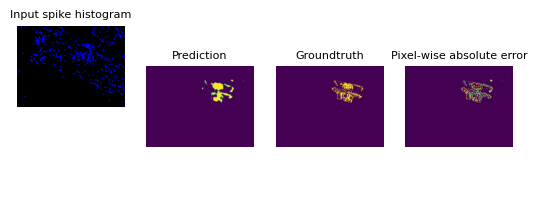

0

<Figure size 640x480 with 0 Axes>

In [ ]:
test_transform2 = transforms.Compose([
            transforms.Resize([int(130), int(173)]),
            transforms.ToTensor()
            #trans.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

# print(prediction_root)

spikes_masked = torch.zeros((1,2,21,130,173))
pt1 = torch.empty(1,2,21,130,173)

for i in range(21):
    imgs = spikes_input[0,0,i,:,:].detach().cpu().numpy() #torch.rand(10,3,128,128)
    # print(imgs.shape)
    tensor2 = test_transform2(Image.fromarray(imgs)).to(device).squeeze(0)
    pt1[0,0,i,:,:] = tensor2[:,:]
    print(torch.max(tensor2))

    imgs = spikes_input[0,1,i,:,:].detach().cpu().numpy() #torch.rand(10,3,128,128)
    print(imgs.shape)
    tensor2 = test_transform2(Image.fromarray(imgs)).to(device).squeeze(0)
    pt1[0,1,i,:,:] = tensor2[:,:]
    print(torch.max(tensor2))

# for i in range(21):
    # imgs = spikes_input[0,0,i,:,:].detach().cpu().numpy() #torch.rand(10,3,128,128)
    # # print(imgs.shape)
    # tensor2 = test_transform2(Image.fromarray(imgs)).to(device).squeeze(0)
    # pt1[0,0,i,:,:] = tensor2[:,:]

    # imgs = spikes_input[0,1,i,:,:].detach().cpu().numpy() #torch.rand(10,3,128,128)
    # # print(imgs.shape)
    # tensor2 = test_transform2(Image.fromarray(imgs)).to(device).squeeze(0)
    # pt1[0,1,i,:,:] = tensor2[:,:]

print(spike_input_5D.shape)
print(spike_pred_4D.shape)
print(spike_mask_4D.shape)
show_learning(fig,save,
    pt1[None,e,:,:,:,:],#spike_input_5D[None,e,:,:,:,:],
    spike_pred_4D[None,e,:,:,:],
    spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)  #plt.fig,Save,[B,1,2,260,346],  [B, 1, 260, 346], [B, 1, 260, 346], text,       i


<class 'torch.Tensor'>
torch.Size([1, 2, 21, 112, 112])
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


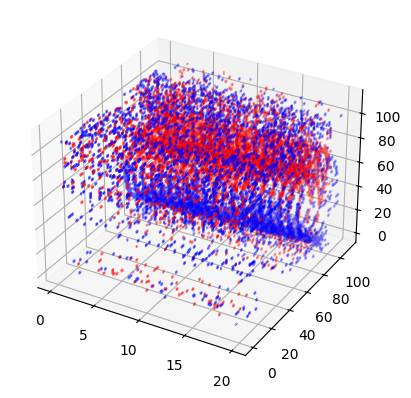

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from torchvision import transforms as trans

# fig, ax = plt.subplots()

test_transform2 = trans.Compose([
            trans.Resize([int(112), int(112)]),
            trans.ToTensor()
            #trans.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])



# spikes_input
ax = plt.axes(projection='3d')

pt1 = torch.empty(1,2,21, 112, 112)

for i in range(21):
  imgs = spikes_input_test[0,0,i,:,:].detach().cpu().numpy() #torch.rand(10,3,128,128)
  # print(imgs.shape)
  tensor2 = test_transform2(Image.fromarray(imgs)).to(device).squeeze(0)
  pt1[0,0,i,:,:] = tensor2[:,:]

  if (i==0):
    print(type(spikes_input_test))
    print(pt1.shape)

  tensor2 = tensor2.cpu().numpy()
  # print(tensor2.cpu().numpy().shape)
  xdata,ydata = tensor2.nonzero()

  # ax.scatter3D(xdata, ydata, i, c=xdata, cmap='Greens');
  ax.scatter3D(i, ydata, xdata, s=0.1, color='blue');

  print(i)


for i in range(20):
  imgs = spikes_input_test[0,1,i,:,:].detach().cpu().numpy() #torch.rand(10,3,128,128)
  tensor2 = test_transform2(Image.fromarray(imgs)).to(device).squeeze(0)
  pt1[0,1,i,:,:] = tensor2

  tensor2 = tensor2.cpu().numpy()
  # print(tensor2.cpu().numpy().shape)
  xdata,ydata = tensor2.nonzero()
  # tensor2 = test_transform2(Image.fromarray(imgs)).to(device).squeeze(0)


  xdata,ydata = tensor2.nonzero()

  # ax.scatter3D(xdata, ydata, i, c=xdata, cmap='Greens');
  ax.scatter3D(i, ydata, xdata, s=0.1, color='red');

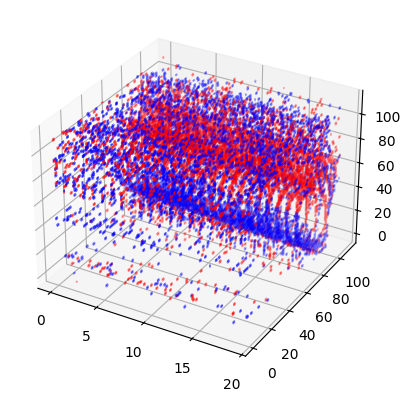

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# fig, ax = plt.subplots()

# spikes_input
ax = plt.axes(projection='3d')

pt1 = pt1.unsqueeze(0)

for i in range(20):
  imgs = pt1[0,0,i,:,:].detach().cpu().numpy() #torch.rand(10,3,128,128)

  xdata,ydata = imgs.nonzero()

  # ax.scatter3D(xdata, ydata, i, c=xdata, cmap='Greens');
  ax.scatter3D(i, ydata, xdata, s=0.1, color='blue');

for i in range(20):
  imgs = pt1[0,1,i,:,:].detach().cpu().numpy() #torch.rand(10,3,128,128)

  xdata,ydata = imgs.nonzero()

  # ax.scatter3D(xdata, ydata, i, c=xdata, cmap='Greens');
  ax.scatter3D(i, ydata, xdata, s=0.1, color='red');

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[310 311 312 313 314 315 316 317 318 319 320 321 322 323 324 325 326 327
 328 329 330 331 332 333 334 335 336 337 338 339 340 341 342 343 344 345
   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 

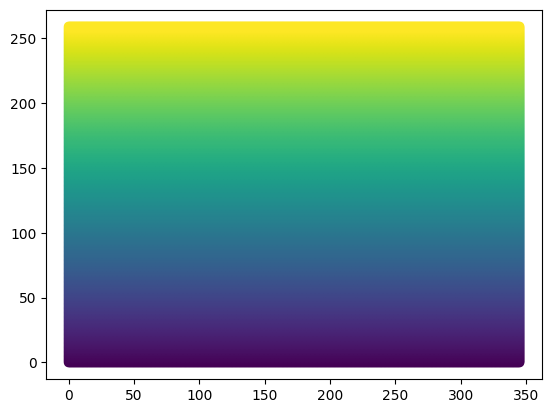

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# fig, ax = plt.subplots()

# spikes_input
# ax = plt.axes(projection='3d')


for i in range(1):
  imgs = spike_pred_test[0,0,:,:].detach().cpu().numpy() #torch.rand(10,3,128,128)

  xdata,ydata = imgs.nonzero()

  print(xdata[310:510])
  print(ydata[310:510])

  # ax.scatter3D(xdata, ydata, i, c=xdata, cmap='Greens');
  # ax.scatter3D(0, ydata, xdata, s=0.1, c=ydata, cmap='Greens');#color='blue');
  plt.scatter(ydata, xdata)

# for i in range(1):
#   imgs = spike_pred_test[0,i,:,:].detach().cpu().numpy() #torch.rand(10,3,128,128)

#   xdata,ydata = imgs.nonzero()

#   # ax.scatter3D(xdata, ydata, i, c=xdata, cmap='Greens');
#   ax.scatter3D(i, ydata, xdata, s=0.1, color='red');

## Para antiguos modelos

testing:   0%|          | 0/1497 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
testing:   1%|          | 9/1497 [00:00<01:22, 18.07it/s]

Test time:  0.8504757881164551
segm, batch 0


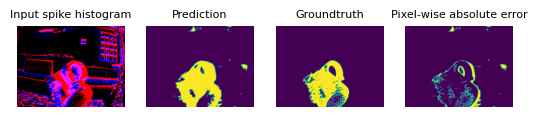

segm, batch 1


<Figure size 640x480 with 0 Axes>

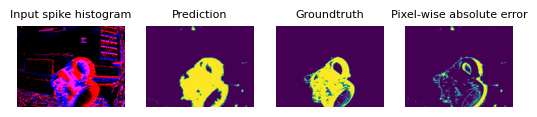

testing:   1%|          | 12/1497 [00:06<17:57,  1.38it/s]

Test time:  0.2243490219116211
segm, batch 0


<Figure size 640x480 with 0 Axes>

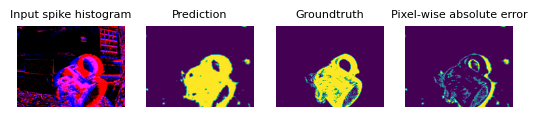

segm, batch 1


<Figure size 640x480 with 0 Axes>

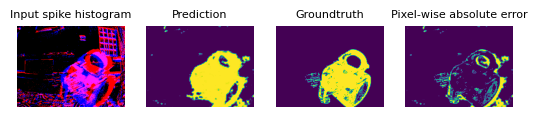

Test time:  0.23869848251342773
segm, batch 0


testing:   1%|          | 13/1497 [00:11<22:19,  1.11it/s]


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

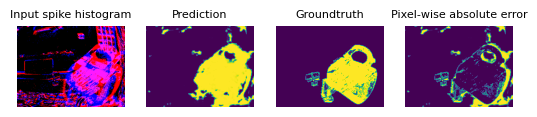

In [ ]:
from spikingjelly.clock_driven import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning

functional.reset_net(net)
n_epochs = 300
test_i = 0

running_test_loss = 0
running_test_IOU = 0

with torch.no_grad():
    start_time = time.time()
    show = True
    for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
        if (data == None):
            continue
        test_i += 1
        functional.reset_net(net)
        optimizer.zero_grad()
        spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
        spikes_masked = data['masked_spike_tensor']

        # print("spikes_input: ", spikes_input.shape)

        spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
        spikes_masked = spikes_masked.permute(0,1,4,2,3)

        spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
        spikes_masked = spikes_masked.to(device)
        spikes_input.requires_grad_()
        start_time_net = time.time()
        spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
        stop_time_net = time.time()
        print("Test time: ", stop_time_net - start_time_net)

        spike_pred =  spike_pred_list[2].to(device)             # (1,1,260,346)

        spike_pred = torch.sigmoid(spike_pred)

        if spike_pred.ndim == 4:
            spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
            spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
            #spike_pred_4D = spike_pred
            spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

        elif spike_pred.ndim == 5:
            spike_pred_4D = torch.sum(spike_pred, axis = (2))           #torch.Size([B, 1, 260, 346])
            spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
            spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

        spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
        spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
        spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

        if show:
            #condition to colapse all timesteps in every batch
            spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
            spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
            for e in range(spike_input_5D.size(0)):
                show_learning(fig,True,
                              spike_input_5D[None,e,:,:,:,:],
                              spike_pred_4D[None,e,:,:,:],
                              spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)  #plt.fig,Save,[B,1,2,260,346],  [B, 1, 260, 346], [B, 1, 260, 346], text,       i
            #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

        loss = loss_module(spike_pred_4D, spike_mask_4D,weightbce=0.1)

        running_test_loss += loss / spikes_input.size(0)
        spike_pred = torch.round(spike_pred)
        running_test_IOU += getIOU(spike_pred, spike_mask_4D)

            # process saved metrics
    if test_i != 0:
        epoch_test_loss = running_test_loss / test_i #len(test_loader)
        epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
        print("\n test i: ",test_i)
        print("len test loader: ", len(test_loader))
        # test_loss_vec.append(float(epoch_test_loss))
        # test_error_vec.append(float(epoch_test_IOU))
        # test_error_vec.append(float(epoch_test_IOU[-1]))
        epoch_test_time = time.time() - start_time
        test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(0, epoch_test_loss,epoch_test_IOU,epoch_test_time)
        print(test_epoch_summary)
        # logfile.write(test_epoch_summary)

    # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
    # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)

    # net.increment_epoch()
    # scheduler.step()
    # # Training/testing plots
    x=[x for x in range(len(train_loss_vec))]
    y=[y for y in range(len(test_loss_vec))]
    plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
    plt.title("Loss")
    plt.xlabel("Épocas")
    plt.ylabel("Pérdida")
    plt.show()

    x=[x for x in range(len(train_error_vec))]
    y=[y for y in range(len(test_error_vec))]
    plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
    plt.title("IoU (%)")
    plt.xlabel("Épocas")
    plt.ylabel("IOU")
    plt.show()
print("training finished !")

##sdasd

In [ ]:
a = torch.rand(2, 2, dtype=float)*100
b = torch.rand(2, 2, dtype=float)*0.01
c = torch.rand(2, 2, dtype=float)*10

# torch.where(a*(b@c) < 1, -a*b, 0.)

print(a)

a = torch.where(a < 50, 1.0, 0.0)

print(a)


tensor([[28.7932, 65.9352],
        [98.0585, 97.5764]], dtype=torch.float64)
tensor([[1., 0.],
        [0., 0.]])


In [ ]:
a = torch.randn(4, 4, 2)

print(a)

a = torch.where(a < 0, 1.0, 0.0)

print(a)

torch.sum(a)

tensor([[[-0.8838, -1.2786],
         [-0.4809,  0.2668],
         [ 0.4832,  0.9820],
         [-0.6847, -0.7707]],

        [[ 2.1505, -0.0436],
         [ 1.1226,  0.1239],
         [-0.6744,  0.1250],
         [-1.0834, -1.2567]],

        [[-0.2553, -0.2462],
         [-0.0118,  0.7588],
         [ 0.1921, -0.4819],
         [-1.0205,  0.5287]],

        [[-0.1459, -1.6128],
         [ 0.4621, -0.5542],
         [ 1.2456, -1.1916],
         [-0.1843, -0.0709]]])
tensor([[[1., 1.],
         [1., 0.],
         [0., 0.],
         [1., 1.]],

        [[0., 1.],
         [0., 0.],
         [1., 0.],
         [1., 1.]],

        [[1., 1.],
         [1., 0.],
         [0., 1.],
         [1., 0.]],

        [[1., 1.],
         [0., 1.],
         [0., 1.],
         [1., 1.]]])


tensor(20.)

In [ ]:
%cd outdoor_day_modificated
# %cd /content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/data/#outdoor_day_modificated/outdoor_day1_img/
!ls -1 | wc -l

[Errno 2] No such file or directory: 'outdoor_day_modificated'
/content/drive/.shortcut-targets-by-id/1W0E8y0VSTYPGciYQVZf1g5oOByeSb3DC/StereoSpikeA/datasets/MVSEC/data
6
